# Measuring emission line fluxes

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import corner
from lmfit import minimize, Parameters
from astropy.io import fits

import uncertainties.umath as uum
from uncertainties import ufloat
from uncertainties import unumpy as upy

import os
import sys
magePath = '/home/benjamin/Documents/analogs/'
os.sys.path.append(magePath)

from magE.directMethod import directT, run_all
from magE.functions import mergeSpec, gaussian, to_vel, FWHM, dV, save_catalog
from magE.plotutils import * 
from magE.constutils import *

PATH = '/home/benjamin/Documents/analogs/specs/final_spec/'
os.chdir(PATH)
os.getcwd()

'/home/benjamin/Documents/analogs/specs/final_spec'

In [2]:
# read the data
import pandas as pd
galname = 'J2225'
j2225 = pd.read_csv(galname + '.csv')

wave = j2225['wave'].to_numpy()
flux = j2225['flux'].to_numpy()
err = j2225['noise'].to_numpy()
igal = np.argmax(np.array(galnames) == galname)

class SpecPiece(object):
    
    def __init__(self, name, wavelength, flux, noise):
        self.name = name
        self.wavelength = wavelength
        self.flux = flux
        self.noise = noise


# Main lines
        
# [NII]6548 + Ha + [NII]6584
select = (wave > 6975) * (wave < 7040)
ha_nii = SpecPiece('ha+nii', wave[select], flux[select], err[select])

# Hb + [OIII]4959 + [OIII]5007
select = (wave > 5330) * (wave < 5360)
oiii_hei = SpecPiece('oiii+hei', wave[select], flux[select], err[select])


# Low ionization lines

# [OII]7319 + [OII]7330
select = (wave > 7790) * (wave < 7840)
oii_7320 = SpecPiece('oii7330', wave[select], flux[select], err[select])

# [SII]6716 + [SII]6731
select = (wave > 7150) * (wave < 7200)
sii = SpecPiece('sii', wave[select], flux[select], err[select])

# [NII]5755
select = (wave > 6120) * (wave < 6160)
nii_5755 = SpecPiece('nii5755', wave[select], flux[select], err[select])

# Hb
select = (wave > 5170) * (wave < 5205)
hbeta = SpecPiece('hb', wave[select], flux[select], err[select])

# Hg
select = (wave > 4610) * (wave < 4650)
hgamma = SpecPiece('hg', wave[select], flux[select], err[select])

# Hd
select = (wave > 4355) * (wave < 4400)
hdelta = SpecPiece('hd', wave[select], flux[select], err[select])

# [SII]4068 + [SII]4076
select = (wave > 4320) * (wave < 4370)
sii2 = SpecPiece('sii2', wave[select], flux[select], err[select])

# [OII]3726 + [OII]3729
select = (wave > 3965) * (wave < 3990)
oii_3727 = SpecPiece('oii3727', wave[select], flux[select], err[select])


# High ionization lines

# [SIII]9532
select = (wave > 10090) * (wave < 10250)
siii_9532 = SpecPiece('siiia', wave[select], flux[select], err[select])

# [SIII]9069
select = (wave > 9600) * (wave < 9750)
siii_9069 = SpecPiece('siiib', wave[select], flux[select], err[select])

# [OI]6300 + [SIII]6312
select = (wave > 6695) * (wave < 6765)
oi_siii = SpecPiece('oi+siiic', wave[select], flux[select], err[select])

# [OIII]4959
select = (wave > 5280) * (wave < 5305)
oiii_4959 = SpecPiece('oiiib', wave[select], flux[select], err[select])

# [OIII]4363
select = (wave > 4645) * (wave < 4665)
oiii_4363 = SpecPiece('oiiic', wave[select], flux[select], err[select])

# [NeIII]3868
select = (wave > 4120) * (wave < 4135)
neiii_3868 = SpecPiece('neiiia', wave[select], flux[select], err[select])

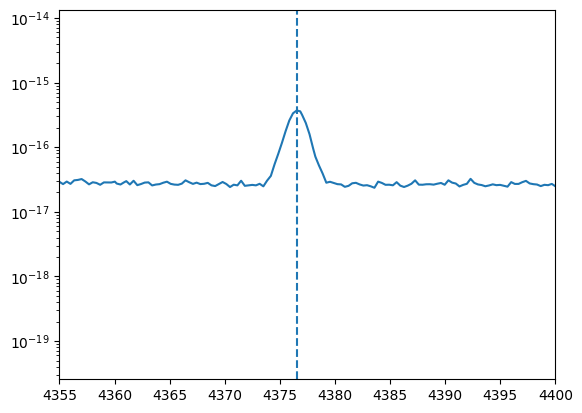

In [3]:
plt.plot(wave, flux)
plt.xlim(4355, 4400)
plt.axvline((1 + z_BN[igal])*wave_cat['Hd'], ls='--')
plt.yscale('log')

---

# Two component model fit for [OIII] 4959

## [OIII]4959

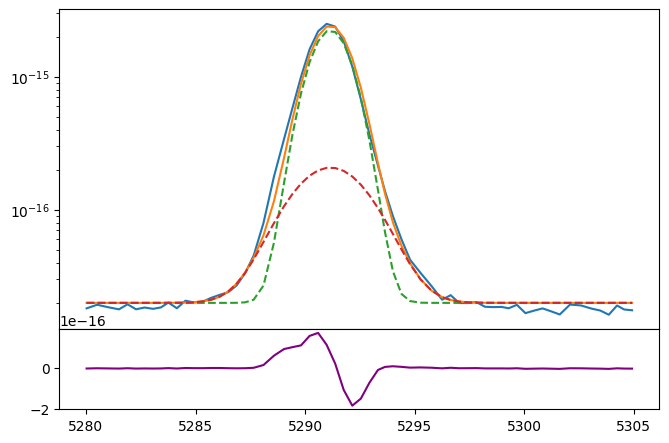

In [4]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(oiii_4959.wavelength, oiii_4959.flux)
bkg = 2e-17

oiiib_nar = gaussian(oiii_4959.wavelength, 500e-17, wave_cat['[OIII]4959'], z=z_BN[igal], sigma=0.9)
oiiib_brd = gaussian(oiii_4959.wavelength, 80e-17, wave_cat['[OIII]4959'], z=z_BN[igal], sigma=1.7)

ax.plot(oiii_4959.wavelength, bkg + oiiib_nar + oiiib_brd)
ax.plot(oiii_4959.wavelength, bkg + oiiib_nar, ls='--')
ax.plot(oiii_4959.wavelength, bkg + oiiib_brd, ls='--')
ax1.plot(oiii_4959.wavelength, oiii_4959.flux - bkg - oiiib_nar - oiiib_brd, color='purple')
ax.set_yscale('log')

In [5]:
params_oiii_4959 = Parameters()
params_oiii_4959.add('z_nar', value=z_BN[igal])
params_oiii_4959.add('z_brd', value=z_BN[igal])
params_oiii_4959.add('sigma_nar', value=0.9, min=0.)
params_oiii_4959.add('sigma_brd', value=1.7, min=0.)
params_oiii_4959.add('Oiiib_nar', value=500e-17, min=0.)
params_oiii_4959.add('Oiiib_brd', value=80e-17, min=0.)
params_oiii_4959.add('bkg', value=2e-17, min=0.)


def residual_oiii_4959(params_oiii_4959, x, data, uncertainty):
    
    z_nar = params_oiii_4959['z_nar']
    z_brd = params_oiii_4959['z_brd']
    sigma_nar = params_oiii_4959['sigma_nar']
    sigma_brd = params_oiii_4959['sigma_brd']
    oiiib_nar = params_oiii_4959['Oiiib_nar']
    oiiib_brd = params_oiii_4959['Oiiib_brd']
    bkg = params_oiii_4959['bkg']
    
    x = oiii_4959.wavelength
    model = gaussian(x, oiiib_nar, wave_cat['[OIII]4959'], z_nar, sigma_nar) \
          + gaussian(x, oiiib_brd, wave_cat['[OIII]4959'], z_brd, sigma_brd)
    
    return (model + bkg - oiii_4959.flux) / oiii_4959.noise

In [6]:
np.random.seed(2225)
out_oiii_4959 = minimize(residual_oiii_4959, params_oiii_4959, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

100%|██████████████████████████████████████| 2500/2500 [00:18<00:00, 136.91it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 6 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 65.98871772 192.87388375 254.85954559 255.38288872 259.3673801
 257.32947754  48.82769241]


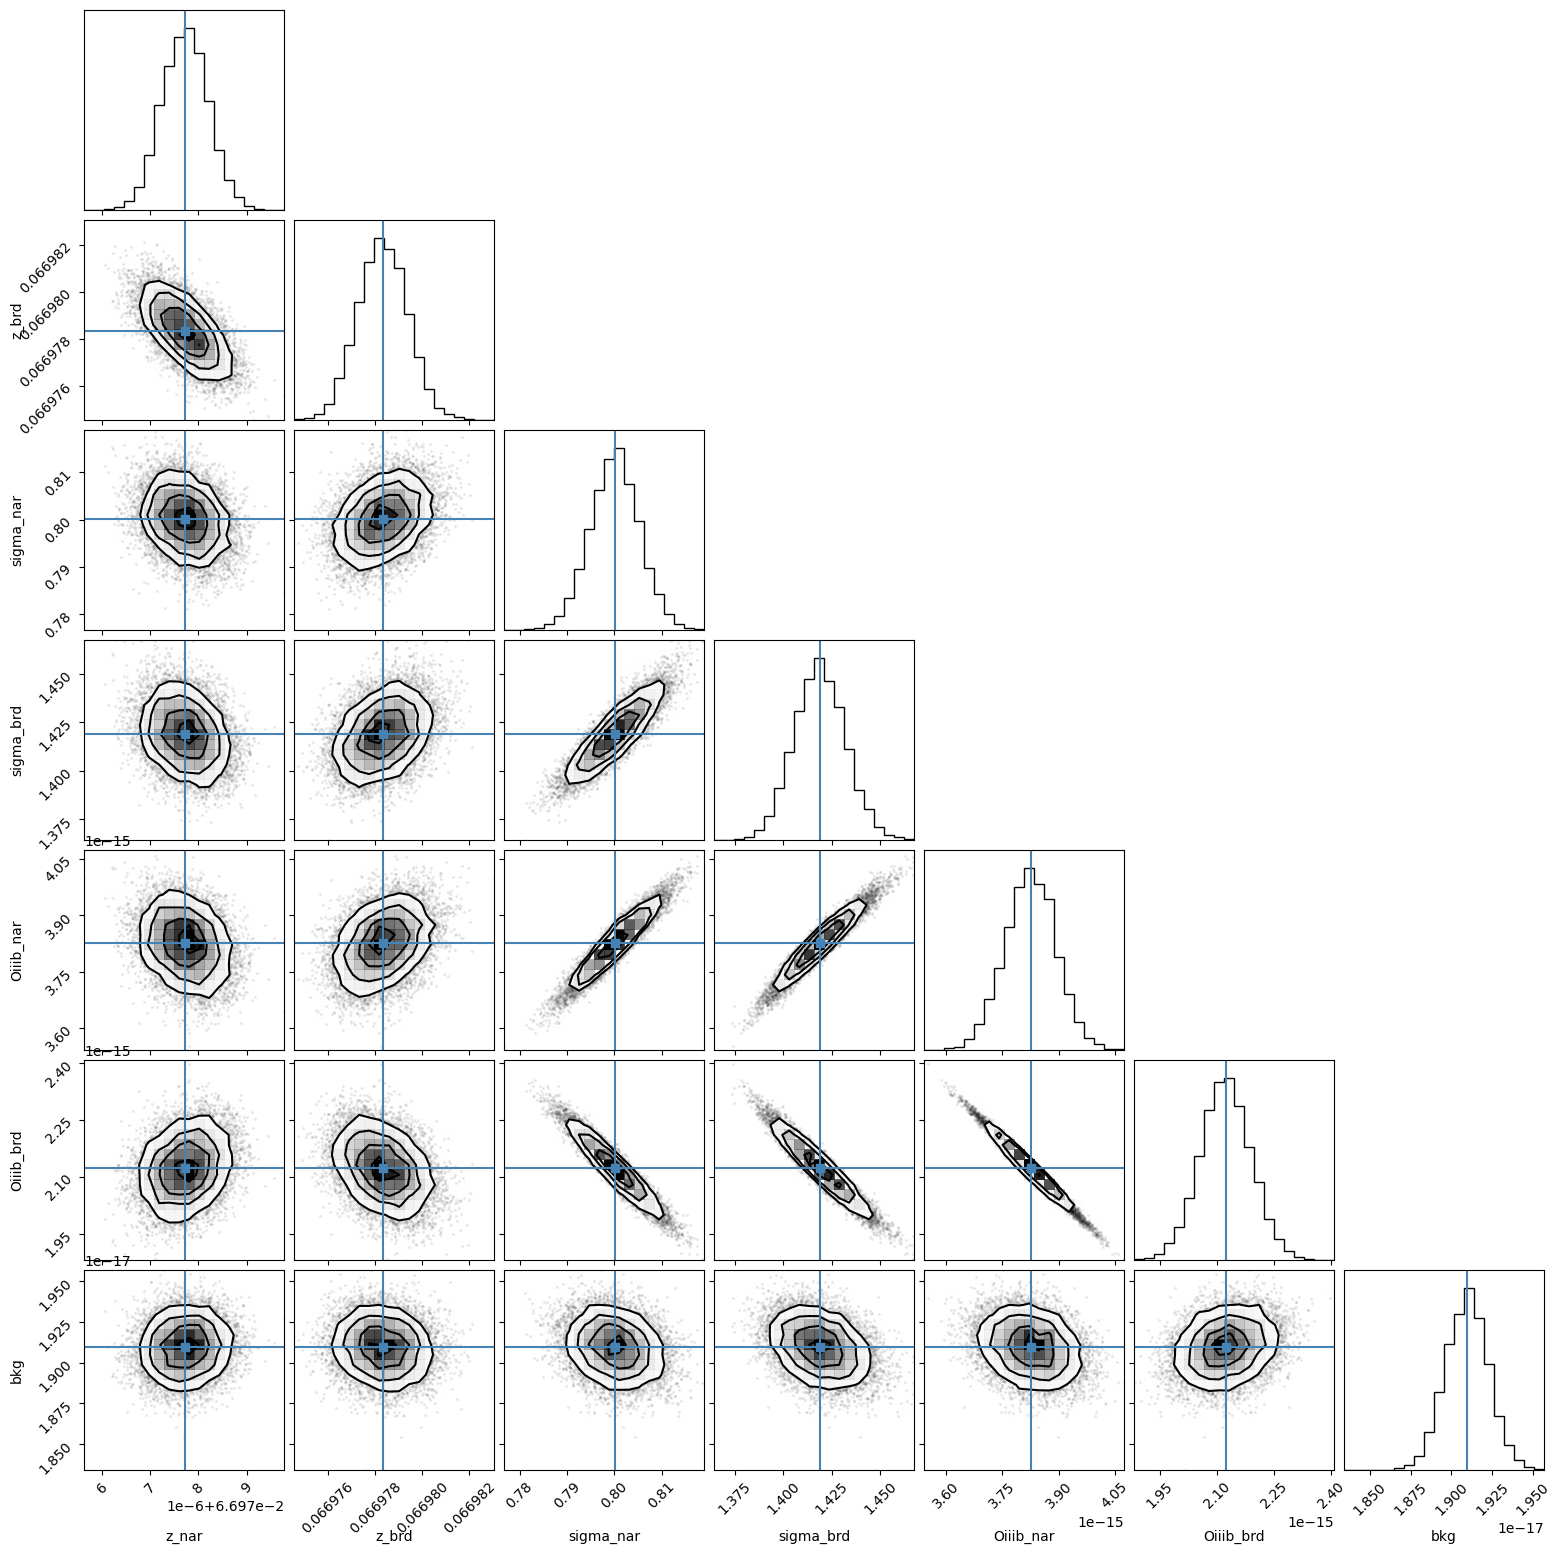

In [7]:
corner.corner(out_oiii_4959.flatchain, labels=out_oiii_4959.var_names,
             truths=list(out_oiii_4959.params.valuesdict().values()));
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

In [8]:
out_oiii_4959

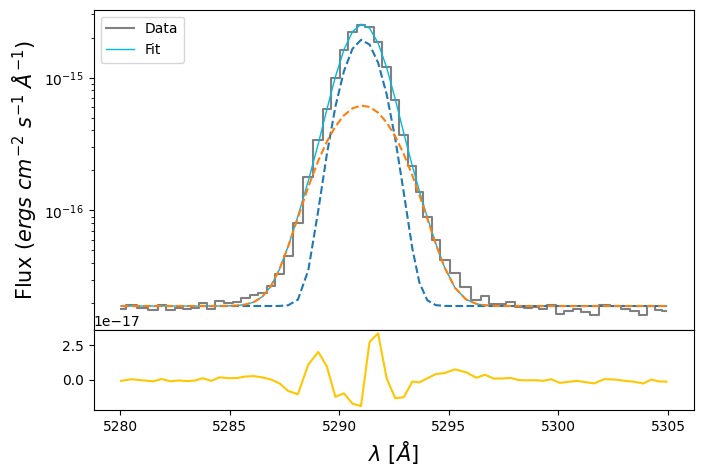

In [9]:
oiiib_nar_flux = out_oiii_4959.flatchain.Oiiib_nar.mean()
oiiib_nar_std = out_oiii_4959.flatchain.Oiiib_nar.std()

oiiib_brd_flux = out_oiii_4959.flatchain.Oiiib_brd.mean()
oiiib_brd_std = out_oiii_4959.flatchain.Oiiib_brd.std()

bkg_oiii_4959 = out_oiii_4959.flatchain.bkg.mean()
bkg_oiii_4959_std = out_oiii_4959.flatchain.bkg.std()

z_nar_oiii_4959 = out_oiii_4959.flatchain.z_nar.mean()
z_nar_oiii_4959_std = out_oiii_4959.flatchain.z_nar.std()

z_brd_oiii_4959 = out_oiii_4959.flatchain.z_brd.mean()
z_brd_oiii_4959_std = out_oiii_4959.flatchain.z_brd.std()

sigma_nar_oiii_4959 = out_oiii_4959.flatchain.sigma_nar.mean()
sigma_nar_oiii_4959_std = out_oiii_4959.flatchain.sigma_nar.std()

sigma_brd_oiii_4959 = out_oiii_4959.flatchain.sigma_brd.mean()
sigma_brd_oiii_4959_std = out_oiii_4959.flatchain.sigma_brd.std()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(oiii_4959.wavelength, oiii_4959.flux,
            color='gray', label='Data', where='mid')

oiiib_nar = gaussian(oiii_4959.wavelength, oiiib_nar_flux, wave_cat['[OIII]4959'], z_nar_oiii_4959, sigma_nar_oiii_4959)
oiiib_brd = gaussian(oiii_4959.wavelength, oiiib_brd_flux, wave_cat['[OIII]4959'], z_brd_oiii_4959, sigma_brd_oiii_4959)
oiiib = oiiib_nar + oiiib_brd

ax.plot(oiii_4959.wavelength, bkg_oiii_4959 + oiiib,
        lw=1, color=c[0], label='Fit')
ax.plot(oiii_4959.wavelength, bkg_oiii_4959 + oiiib_nar, ls='--')
ax.plot(oiii_4959.wavelength, bkg_oiii_4959 + oiiib_brd, ls='--')
ax1.plot(oiii_4959.wavelength, oiii_4959.flux - bkg_oiii_4959 - oiiib,
         color=c[3])
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
ax.set_yscale('log')
ax.legend(loc='upper left')
#plt.savefig(fname='ha_nii.svg', bbox_inches='tight')

#ls_4959 = (wave_cat['[OIII]4959'] * (1 + z_nar_oiii_4959)) + (4 * sigma_brd_oiii_4959)
#li_4959 = (wave_cat['[OIII]4959'] * (1 + z_nar_oiii_4959)) - (4 * sigma_brd_oiii_4959)

#ax.axvline(ls_4959, ls='--', color='gray', lw=0.8)
#ax.axvline(li_4959, ls='--', color='gray', lw=0.8)

In [10]:
# EW
EW_OIII_4959_nar = ufloat(oiiib_nar_flux, oiiib_nar_std) / ufloat(bkg_oiii_4959, bkg_oiii_4959_std)
EW_OIII_4959_brd = ufloat(oiiib_brd_flux, oiiib_brd_std) / ufloat(bkg_oiii_4959, bkg_oiii_4959_std)
EW_OIII_4959 = (ufloat(oiiib_nar_flux, oiiib_nar_std) + ufloat(oiiib_brd_flux, oiiib_brd_std)) / ufloat(bkg_oiii_4959, bkg_oiii_4959_std)

# FWHM
FWHM_4959_nar = FWHM(ufloat(sigma_nar_oiii_4959, sigma_nar_oiii_4959_std),  wave_cat['[OIII]4959']*(1 + ufloat(z_nar_oiii_4959, z_nar_oiii_4959_std)))
FWHM_4959_brd = FWHM(ufloat(sigma_brd_oiii_4959, sigma_brd_oiii_4959_std),  wave_cat['[OIII]4959']*(1 + ufloat(z_brd_oiii_4959, z_brd_oiii_4959_std)))

# velocity shift
dV_4959 = dV(ufloat(z_brd_oiii_4959, z_brd_oiii_4959_std),
             ufloat(z_nar_oiii_4959, z_nar_oiii_4959_std))

# Ratio to fix velocity shifts between components
z_ratio = z_brd_oiii_4959 / z_nar_oiii_4959

# Ratio to distribute the flux between components in no detection
brd_to_nar = oiiib_brd_flux / oiiib_nar_flux

# Dispersion for the whole spectra
dLam = (np.max(wave) - np.min(wave)) / len(wave)

mask_4959 = (oiii_4959.wavelength >= li_4959) & (oiii_4959.wavelength < ls_4959)
N_4959 = len(oiii_4959.wavelength[mask_4959])
sigmac_4959 = np.std(oiii_4959.flux[np.logical_not(mask_4959)])

# Uncertainties added
sigmal_4959_nar = sigmac_4959 * np.sqrt(N_4959 + (EW_OIII_4959_nar.nominal_value/dLam))
sigmal_4959_brd = sigmac_4959 * np.sqrt(N_4959 + (EW_OIII_4959_brd.nominal_value/dLam))

print('Previous narrow error:', oiiib_nar_std)
print('Previous broad error:', oiiib_brd_std)

# Final uncertainties
oiiib_nar_std = np.sqrt(oiiib_nar_std**2 + sigmal_4959_nar**2)
oiiib_brd_std = np.sqrt(oiiib_brd_std**2 + sigmal_4959_brd**2)

print('New narrow error:', oiiib_nar_std)
print('New broad error:', oiiib_brd_std)

# Low ionization

## [NII]6548 + H$\alpha$ + [NII]6584

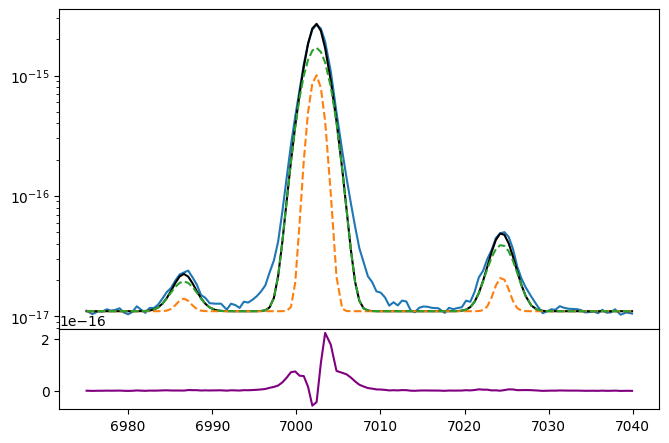

In [11]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(ha_nii.wavelength, ha_nii.flux)
bkg = 1.1e-17

ha_nar = gaussian(ha_nii.wavelength, 0.2e-14, wave_cat['Ha'], z=z_nar_oiii_4959, sigma=sigma_nar_oiii_4959)
ha_brd = gaussian(ha_nii.wavelength, 0.6e-14, wave_cat['Ha'], z=z_brd_oiii_4959, sigma=sigma_brd_oiii_4959)

niib_nar = gaussian(ha_nii.wavelength, 0.06e-16, wave_cat['[NII]6548'], z=z_nar_oiii_4959, sigma=sigma_nar_oiii_4959)
niib_brd = gaussian(ha_nii.wavelength, 0.3e-16, wave_cat['[NII]6548'], z=z_brd_oiii_4959, sigma=sigma_brd_oiii_4959)

niia_nar = gaussian(ha_nii.wavelength, 0.2e-16, wave_cat['[NII]6584'], z=z_nar_oiii_4959, sigma=sigma_nar_oiii_4959)
niia_brd = gaussian(ha_nii.wavelength, 1e-16, wave_cat['[NII]6584'], z=z_brd_oiii_4959, sigma=sigma_brd_oiii_4959)

ha = ha_nar + ha_brd
niib = niib_nar + niib_brd
niia = niia_nar + niia_brd

ax.plot(ha_nii.wavelength, bkg + niib + ha + niia, color='black')
ax.plot(ha_nii.wavelength, bkg + niib_nar + ha_nar + niia_nar, ls='--')
ax.plot(ha_nii.wavelength, bkg + niib_brd + ha_brd + niia_brd, ls='--')
ax1.plot(ha_nii.wavelength, ha_nii.flux - bkg - niib - ha - niia, color='purple')

#ax.axvline(7175)
#ax.axvline(7247)
ax.set_yscale('log')

In [12]:
params_ha_nii = Parameters()
params_ha_nii.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_ha_nii.add('z_ratio', value=z_ratio, vary=False)
params_ha_nii.add('sigma_nar', value=sigma_nar_oiii_4959, vary=False)
params_ha_nii.add('sigma_brd', value=sigma_brd_oiii_4959, vary=False)
params_ha_nii.add('Ha_nar', value=0.2e-14, min=0.)
params_ha_nii.add('Ha_brd', value=0.6e-14, min=0.)
params_ha_nii.add('Niia_nar', value=0.2e-16, min=0.)
params_ha_nii.add('Niia_brd', value=1.0e-16, min=0.)
params_ha_nii.add('Niib_to_niia', value=1/3, min=0., max=1.)
params_ha_nii.add('bkg', value=1.1e-17, vary=True)


def residual_ha_nii(params_ha_nii, x, data, uncertainty):
    
    z_nar = params_ha_nii['z_nar']
    z_brd = params_ha_nii['z_nar'] * params_ha_nii['z_ratio']
    sigma_nar = params_ha_nii['sigma_nar']
    sigma_brd = params_ha_nii['sigma_brd']
    ha_nar = params_ha_nii['Ha_nar']
    ha_brd = params_ha_nii['Ha_brd']
    niia_nar = params_ha_nii['Niia_nar']
    niia_brd = params_ha_nii['Niia_brd']
    niib_nar = params_ha_nii['Niia_nar']*params_ha_nii['Niib_to_niia']
    niib_brd = params_ha_nii['Niia_brd']*params_ha_nii['Niib_to_niia']
    bkg = params_ha_nii['bkg']
    
    x = ha_nii.wavelength
    
    model_ha = gaussian(x, ha_nar, wave_cat['Ha'], z_nar, sigma_nar) \
             + gaussian(x, ha_brd, wave_cat['Ha'], z_brd, sigma_brd)
    
    model_niia = gaussian(x, niia_nar, wave_cat['[NII]6584'], z_nar, sigma_nar) \
               + gaussian(x, niia_brd, wave_cat['[NII]6584'], z_brd, sigma_brd)
    
    model_niib = gaussian(x, niib_nar, wave_cat['[NII]6548'], z_nar, sigma_nar) \
               + gaussian(x, niib_brd, wave_cat['[NII]6548'], z_brd, sigma_brd)
    model = model_niib + model_ha + model_niia
    
    return (model + bkg - ha_nii.flux) / ha_nii.noise

In [13]:
np.random.seed(2225)
out_ha_nii = minimize(residual_ha_nii, params_ha_nii, args=(1, 1, 1),
                      method='emcee', burn=1000, steps=2500, thin=10)

100%|███████████████████████████████████████| 2500/2500 [00:32<00:00, 76.08it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 5 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 29.0537453  115.23827137 104.95512309 158.05125574 167.80946151
 125.85751596  31.37970367]


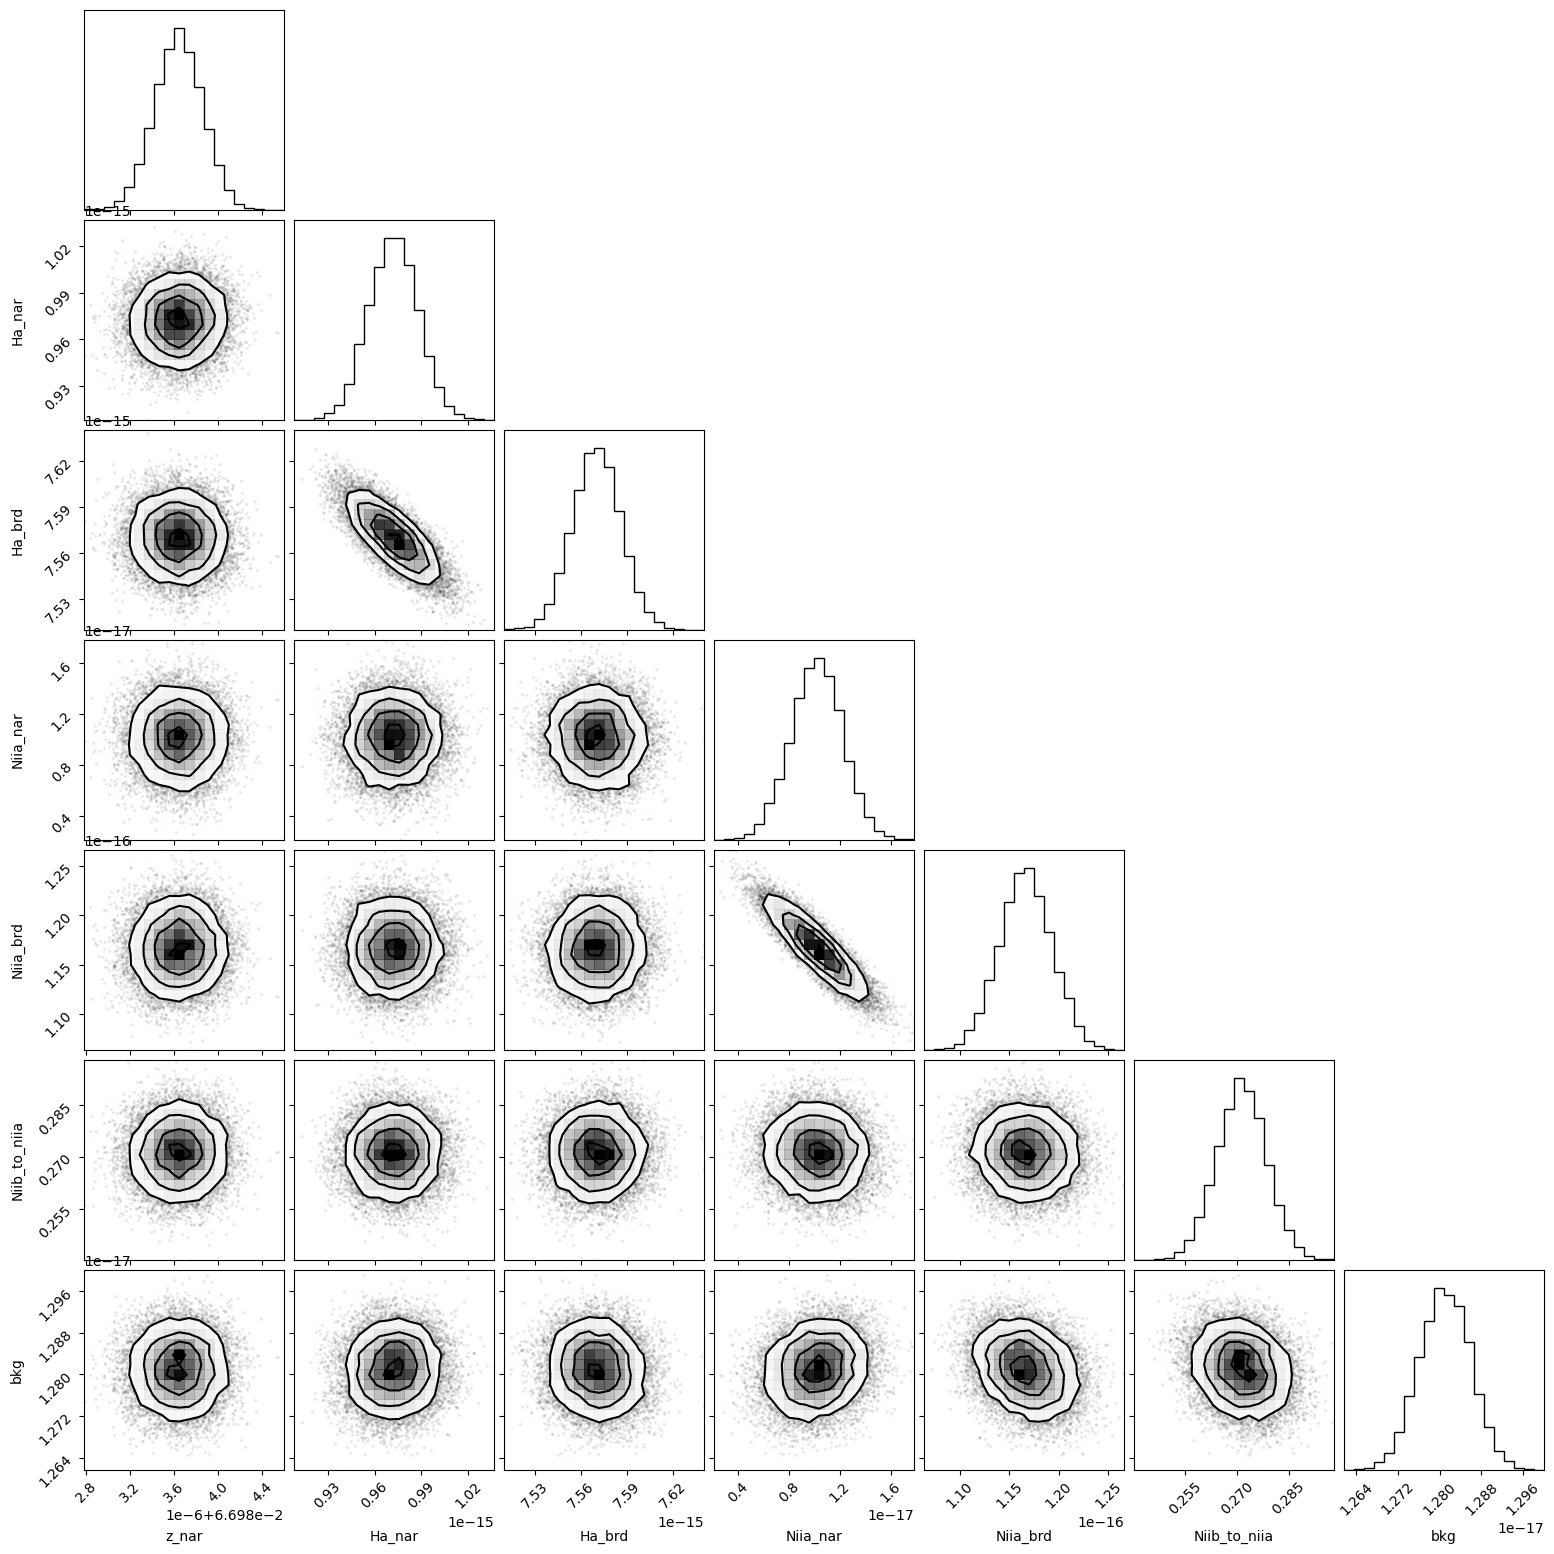

In [14]:
corner.corner(out_ha_nii.flatchain, labels=out_ha_nii.var_names);
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

In [15]:
out_ha_nii

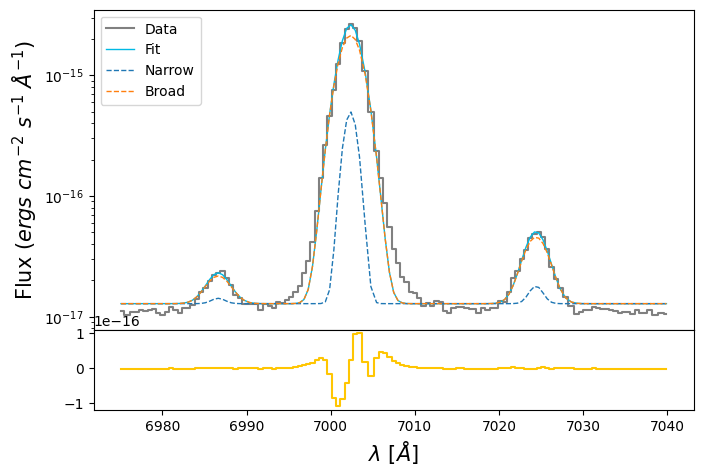

In [16]:
ha_nar_flux = out_ha_nii.flatchain.Ha_nar.mean()
ha_nar_std = out_ha_nii.flatchain.Ha_nar.std()

ha_brd_flux = out_ha_nii.flatchain.Ha_brd.mean()
ha_brd_std = out_ha_nii.flatchain.Ha_brd.std()

niia_nar_flux = out_ha_nii.flatchain.Niia_nar.mean()
niia_nar_std = out_ha_nii.flatchain.Niia_nar.std()

niia_brd_flux = out_ha_nii.flatchain.Niia_brd.mean()
niia_brd_std = out_ha_nii.flatchain.Niia_brd.std()

niib_nar_flux = (niia_nar_flux * out_ha_nii.flatchain.Niib_to_niia).mean()
niib_nar_std = (niia_nar_flux * out_ha_nii.flatchain.Niib_to_niia).std()

niib_brd_flux = (niia_brd_flux * out_ha_nii.flatchain.Niib_to_niia).mean()
niib_brd_std = (niia_brd_flux * out_ha_nii.flatchain.Niib_to_niia).std()

z_ha_nii = out_ha_nii.flatchain.z_nar.mean()
z_ha_nii_std = out_ha_nii.flatchain.z_nar.std()

bkg_ha_nii = out_ha_nii.flatchain.bkg.mean()
bkg_ha_nii_std = out_ha_nii.flatchain.bkg.std()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(ha_nii.wavelength, ha_nii.flux,
            color='gray', label='Data', where='mid')

ha_nar = gaussian(ha_nii.wavelength, ha_nar_flux, wave_cat['Ha'], z_nar_oiii_4959, sigma_nar_oiii_4959)
ha_brd = gaussian(ha_nii.wavelength, ha_brd_flux, wave_cat['Ha'], z_brd_oiii_4959, sigma_brd_oiii_4959)

niia_nar = gaussian(ha_nii.wavelength, niia_nar_flux, wave_cat['[NII]6584'], z_nar_oiii_4959, sigma_nar_oiii_4959)
niia_brd = gaussian(ha_nii.wavelength, niia_brd_flux, wave_cat['[NII]6584'], z_brd_oiii_4959, sigma_brd_oiii_4959)

niib_nar = gaussian(ha_nii.wavelength, niib_nar_flux, wave_cat['[NII]6548'], z_nar_oiii_4959, sigma_nar_oiii_4959)
niib_brd = gaussian(ha_nii.wavelength, niib_brd_flux, wave_cat['[NII]6548'], z_brd_oiii_4959, sigma_brd_oiii_4959)

niia = niia_nar + niia_brd
ha = ha_nar + ha_brd
niib = niib_nar + niib_brd

ax.plot(ha_nii.wavelength, bkg_ha_nii + niia + ha + niib,
        lw=1, color=c[0], label='Fit')

ax.plot(ha_nii.wavelength, bkg_ha_nii + niia_nar + ha_nar + niib_nar,
        ls='--', lw=1, label='Narrow')
ax.plot(ha_nii.wavelength, bkg_ha_nii + niia_brd + ha_brd + niib_brd,
        ls='--', lw=1, label='Broad')

ax1.step(ha_nii.wavelength, ha_nii.flux - bkg_ha_nii - niia - ha - niib,
         color=c[3], where='mid')
#ax1.set_ylim(-5*bkg_ha_nii, 5*bkg_ha_nii)
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
ax.set_yscale('log')
#ax.text(x=7008, y=1.5e-13, s=r'[NII]$\lambda$6548 + H$\alpha$ + [NII]$\lambda$6584',
#       fontsize=15)
ax.legend(loc='upper left')
#plt.savefig(fname='ha_nii.svg', bbox_inches='tight')

#ls_niib = (wave_cat['[NII]6548'] * (1 + z_ha_nii)) + (3 * sigma_brd_oiii_4959)
#li_niib = (wave_cat['[NII]6548'] * (1 + z_ha_nii)) - (3 * sigma_brd_oiii_4959)

#ls_ha = (wave_cat['Ha'] * (1 + z_ha_nii)) + (5 * sigma_brd_oiii_4959)
#li_ha = (wave_cat['Ha'] * (1 + z_ha_nii)) - (5 * sigma_brd_oiii_4959)

#ls_niia = (wave_cat['[NII]6584'] * (1 + z_ha_nii)) + (3 * sigma_brd_oiii_4959)
#li_niia = (wave_cat['[NII]6584'] * (1 + z_ha_nii)) - (3 * sigma_brd_oiii_4959)

#ax.axvline(ls_niib, ls='--', color='gray', lw=0.8)
#ax.axvline(li_niib, ls='--', color='gray', lw=0.8)

#ax.axvline(ls_ha, ls='--', color='gray', lw=0.8)
#ax.axvline(li_ha, ls='--', color='gray', lw=0.8)

#ax.axvline(ls_niia, ls='--', color='gray', lw=0.8)
#ax.axvline(li_niia, ls='--', color='gray', lw=0.8)

In [17]:
# EW
EW_Ha_nar = ufloat(ha_nar_flux, ha_nar_std) / ufloat(bkg_ha_nii, bkg_ha_nii_std)
EW_Ha_brd = ufloat(ha_brd_flux, ha_brd_std) / ufloat(bkg_ha_nii, bkg_ha_nii_std)
EW_Ha = (ufloat(ha_nar_flux, ha_nar_std) + ufloat(ha_brd_flux, ha_brd_std)) / ufloat(bkg_ha_nii, bkg_ha_nii_std)

EW_NII_6584_nar = ufloat(niia_nar_flux, niia_nar_std) / ufloat(bkg_ha_nii, bkg_ha_nii_std)
EW_NII_6584_brd = ufloat(niia_brd_flux, niia_brd_std) / ufloat(bkg_ha_nii, bkg_ha_nii_std)
EW_NII_6584 = (ufloat(niia_nar_flux, niia_nar_std) + ufloat(niia_brd_flux, niia_brd_std)) / ufloat(bkg_ha_nii, bkg_ha_nii_std)

EW_NII_6548_nar = ufloat(niib_nar_flux, niib_nar_std) / ufloat(bkg_ha_nii, bkg_ha_nii_std)
EW_NII_6548_brd = ufloat(niib_brd_flux, niib_brd_std) / ufloat(bkg_ha_nii, bkg_ha_nii_std)
EW_NII_6548 = (ufloat(niib_nar_flux, niib_nar_std) + ufloat(niib_brd_flux, niib_brd_std)) / ufloat(bkg_ha_nii, bkg_ha_nii_std)

mask_niib = (ha_nii.wavelength >= li_niib) & (ha_nii.wavelength < ls_niib)
mask_ha = (ha_nii.wavelength >= li_ha) & (ha_nii.wavelength < ls_ha)
mask_niia = (ha_nii.wavelength >= li_niia) & (ha_nii.wavelength < ls_niia)

c_mask_ha_nii = (ha_nii.wavelength > ls_niia) + (ha_nii.wavelength < li_niib)

N_niib = len(ha_nii.wavelength[mask_niib])
N_ha = len(ha_nii.wavelength[mask_ha])
N_niia = len(ha_nii.wavelength[mask_niia])

sigmac_ha_nii = np.std(ha_nii.flux[c_mask_ha_nii])

# Uncertainties added

sigmal_niib_nar = sigmac_ha_nii * np.sqrt(N_niib + (EW_NII_6548_nar.nominal_value/dLam))
sigmal_niib_brd = sigmac_ha_nii * np.sqrt(N_niib + (EW_NII_6548_brd.nominal_value/dLam))

sigmal_ha_nar = sigmac_ha_nii * np.sqrt(N_ha + (EW_Ha_nar.nominal_value/dLam))
sigmal_ha_brd = sigmac_ha_nii * np.sqrt(N_ha + (EW_Ha_brd.nominal_value/dLam))

sigmal_niia_nar = sigmac_ha_nii * np.sqrt(N_niia + (EW_NII_6584_nar.nominal_value/dLam))
sigmal_niia_brd = sigmac_ha_nii * np.sqrt(N_niia + (EW_NII_6584_brd.nominal_value/dLam))

print('Previous nar error (Niib)', niib_nar_std)
print('Previous brd error (Niib)', niib_brd_std)

print('Previous nar error (Ha)', ha_nar_std)
print('Previous brd error (Ha)', ha_brd_std)

print('Previous nar error (Niia)', niia_nar_std)
print('Previous brd error (Niia)', niia_brd_std)

# Final uncertainties
niib_nar_std = np.sqrt((niib_nar_std**2) + (sigmal_niib_nar**2))
niib_brd_std = np.sqrt((niib_brd_std**2) + (sigmal_niib_brd**2))

ha_nar_std = np.sqrt((ha_nar_std**2) + (sigmal_ha_nar**2))
ha_brd_std = np.sqrt((ha_brd_std**2) + (sigmal_ha_brd**2))

niia_nar_std = np.sqrt((niia_nar_std**2) + (sigmal_niia_nar**2))
niia_brd_std = np.sqrt((niia_brd_std**2) + (sigmal_niia_brd**2))

print('New nar error (Niib)', niib_nar_std)
print('New brd error (Niib)', niib_brd_std)

print('New nar error (Ha)', ha_nar_std)
print('New brd error (Ha)', ha_brd_std)

print('New nar error (Niia)', niia_nar_std)
print('New brd error (Niia)', niia_brd_std)

## [OII]7319 + [OII]7330

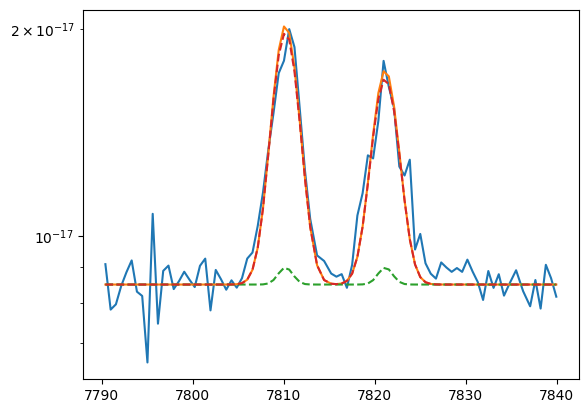

In [18]:
# Search for good initial guess

plt.plot(oii_7320.wavelength, oii_7320.flux)

oiia_nar = gaussian(oii_7320.wavelength, 0.1e-17, wave_cat['[OII]7330'], z=z_nar_oiii_4959, sigma=sigma_nar_oiii_4959)
oiia_brd = gaussian(oii_7320.wavelength, 3e-17, wave_cat['[OII]7330'], z=z_brd_oiii_4959, sigma=sigma_brd_oiii_4959)

oiib_nar = gaussian(oii_7320.wavelength, 0.1e-17, wave_cat['[OII]7319'], z=z_nar_oiii_4959, sigma=sigma_nar_oiii_4959)
oiib_brd = gaussian(oii_7320.wavelength, 4e-17, wave_cat['[OII]7319'], z=z_brd_oiii_4959, sigma=sigma_brd_oiii_4959)

oiia = oiia_nar + oiia_brd
oiib = oiib_nar + oiib_brd
bkg = 8.5e-18

plt.plot(oii_7320.wavelength, bkg + oiib + oiia)
plt.plot(oii_7320.wavelength, bkg + oiib_nar + oiia_nar, ls='--')
plt.plot(oii_7320.wavelength, bkg + oiib_brd + oiia_brd, ls='--')

plt.yscale('log')

In [19]:
params_oii_7320 = Parameters()

params_oii_7320.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_oii_7320.add('z_ratio', value=z_ratio, vary=False)
params_oii_7320.add('sigma_nar', value=sigma_nar_oiii_4959, vary=False)
params_oii_7320.add('sigma_brd', value=sigma_brd_oiii_4959, vary=False)
params_oii_7320.add('Oiia_nar', value=0.1e-17, min=0.)
params_oii_7320.add('Oiia_brd', value=3e-17, min=0.)
params_oii_7320.add('Oiib_nar', value=0.1e-17, min=0.)
params_oii_7320.add('Oiib_brd', value=4e-17, min=0.)
params_oii_7320.add('bkg', value=8.5e-18, min=0.)

def residual_oii_7320(params_oii_7320, x, data, uncertainty):
    
    z_nar = params_oii_7320['z_nar']
    z_brd = params_oii_7320['z_nar'] * params_oii_7320['z_ratio']
    sigma_nar = params_oii_7320['sigma_nar']
    sigma_brd = params_oii_7320['sigma_brd']
    oiia_nar_flux = params_oii_7320['Oiia_nar']
    oiia_brd_flux = params_oii_7320['Oiia_brd']
    oiib_nar_flux = params_oii_7320['Oiib_nar']
    oiib_brd_flux = params_oii_7320['Oiib_brd']
    bkg = params_oii_7320['bkg']
    
    x = oii_7320.wavelength
    model_oiia = gaussian(x, oiia_nar_flux, wave_cat['[OII]7330'], z_nar, sigma_nar) + \
                 gaussian(x, oiia_brd_flux, wave_cat['[OII]7330'], z_brd, sigma_brd)
    model_oiib = gaussian(x, oiib_nar_flux, wave_cat['[OII]7319'], z_nar, sigma_nar) + \
                 gaussian(x, oiib_brd_flux, wave_cat['[OII]7319'], z_brd, sigma_brd)
    model = model_oiia + model_oiib
    return (model + bkg - oii_7320.flux) / oii_7320.noise

In [20]:
np.random.seed(2225)
out_oii_7320 = minimize(residual_oii_7320, params_oii_7320, args=(1, 1, 1),
                         method='emcee', burn=1000, steps=2500, thin=10)

100%|██████████████████████████████████████| 2500/2500 [00:20<00:00, 122.29it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 6 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [65.51282063 69.61709198 68.25077979 80.17994352 77.83646893 67.15136313]


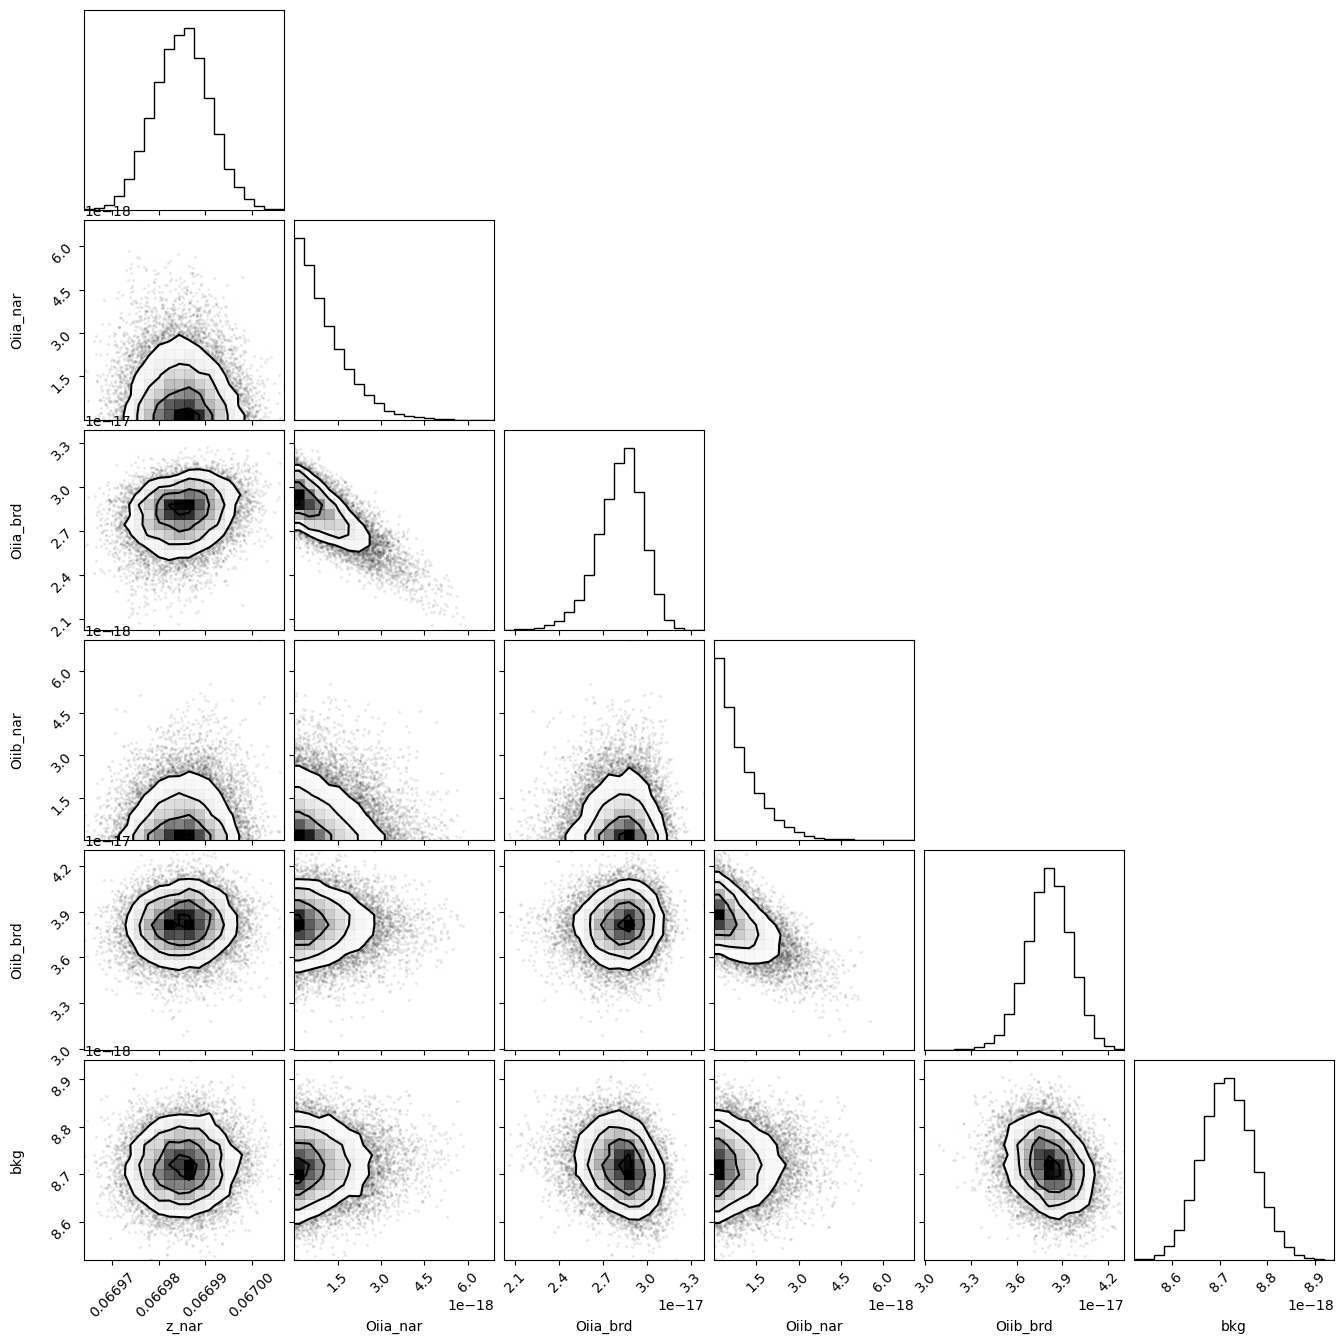

In [21]:
corner.corner(out_oii_7320.flatchain, labels=out_oii_7320.var_names);

In [22]:
out_oii_7320

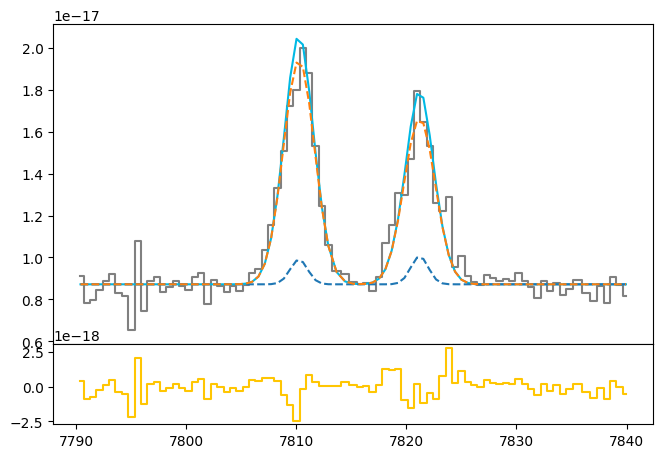

In [23]:
oiia_nar_flux = 3 * out_oii_7320.flatchain.Oiia_nar.std()
oiia_nar_std = 0.0

oiia_brd_flux = out_oii_7320.flatchain.Oiia_brd.mean()
oiia_brd_std = out_oii_7320.flatchain.Oiia_brd.std()

oiib_nar_flux = 3 * out_oii_7320.flatchain.Oiib_nar.std()
oiib_nar_std = 0.0

oiib_brd_flux = out_oii_7320.flatchain.Oiib_brd.mean()
oiib_brd_std = out_oii_7320.flatchain.Oiib_brd.std()

z_oii_7320 = out_oii_7320.flatchain.z_nar.mean()
z_oii_7320_std = out_oii_7320.flatchain.z_nar.std()

bkg_oii_7320 = out_oii_7320.flatchain.bkg.mean()
bkg_oii_7320_std = out_oii_7320.flatchain.bkg.std()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(oii_7320.wavelength, oii_7320.flux, color='gray', label='Data', where='mid')

oiia_nar = gaussian(oii_7320.wavelength, oiia_nar_flux, wave_cat['[OII]7330'], z_oii_7320, sigma_nar_oiii_4959)
oiib_nar = gaussian(oii_7320.wavelength, oiib_nar_flux, wave_cat['[OII]7319'], z_oii_7320, sigma_nar_oiii_4959)

oiia_brd = gaussian(oii_7320.wavelength, oiia_brd_flux, wave_cat['[OII]7330'], z_oii_7320 * z_ratio, sigma_brd_oiii_4959)
oiib_brd = gaussian(oii_7320.wavelength, oiib_brd_flux, wave_cat['[OII]7319'], z_oii_7320 * z_ratio, sigma_brd_oiii_4959)

oiia = oiia_nar + oiia_brd
oiib = oiib_nar + oiib_brd

ax.plot(oii_7320.wavelength, bkg_oii_7320 + oiia + oiib, color=c[0])
ax.plot(oii_7320.wavelength, bkg_oii_7320 + oiia_nar + oiib_nar, ls='--')
ax.plot(oii_7320.wavelength, bkg_oii_7320 + oiia_brd + oiib_brd, ls='--')
#plt.yscale('log')
ax1.step(oii_7320.wavelength, oii_7320.flux - bkg_oii_7320 - oiia - oiib, color=c[3], where='mid')

#ls_oiib = (wave_cat['[OII]7319'] * (1 + z_oii_7320)) + (3 * sigma_brd_oiii_4959)
#li_oiib = (wave_cat['[OII]7319'] * (1 + z_oii_7320)) - (3 * sigma_brd_oiii_4959)

#ls_oiia = (wave_cat['[OII]7330'] * (1 + z_oii_7320)) + (3 * sigma_brd_oiii_4959)
#li_oiia = (wave_cat['[OII]7330'] * (1 + z_oii_7320)) - (3 * sigma_brd_oiii_4959)

#ax.axvline(ls_oiib, ls='--', color='gray', lw=0.8)
#ax.axvline(li_oiib, ls='--', color='gray', lw=0.8)

#ax.axvline(ls_oiia, ls='--', color='gray', lw=0.8)
#ax.axvline(li_oiia, ls='--', color='gray', lw=0.8)

In [24]:
# EW
EW_OII_7330_nar = ufloat(oiia_nar_flux, oiia_nar_std) / ufloat(bkg_oii_7320, bkg_oii_7320_std)
EW_OII_7330_brd = ufloat(oiia_brd_flux, oiia_brd_std) / ufloat(bkg_oii_7320, bkg_oii_7320_std)
EW_OII_7330 = (ufloat(oiia_nar_flux, oiia_nar_std) + ufloat(oiia_brd_flux, oiia_brd_std)) / ufloat(bkg_oii_7320, bkg_oii_7320_std)

EW_OII_7319_nar = ufloat(oiib_nar_flux, oiib_nar_std) / ufloat(bkg_oii_7320, bkg_oii_7320_std)
EW_OII_7319_brd = ufloat(oiib_brd_flux, oiib_brd_std) / ufloat(bkg_oii_7320, bkg_oii_7320_std)
EW_OII_7319 = (ufloat(oiib_nar_flux, oiib_nar_std) + ufloat(oiib_brd_flux, oiib_brd_std)) / ufloat(bkg_oii_7320, bkg_oii_7320_std)

mask_oiib = (oii_7320.wavelength >= li_oiib) & (oii_7320.wavelength < ls_oiib)
mask_oiia = (oii_7320.wavelength >= li_oiia) & (oii_7320.wavelength < ls_oiia)

c_mask_oii_7320 = (oii_7320.wavelength > ls_oiia) + (oii_7320.wavelength < li_oiib)

N_oiib = len(oii_7320.wavelength[mask_oiib])
N_oiia = len(oii_7320.wavelength[mask_oiia])

sigmac_oii_7320 = np.std(oii_7320.flux[c_mask_oii_7320])

# Uncertainties added

sigmal_oiib_nar = sigmac_oii_7320 * np.sqrt(N_oiib + (EW_OII_7319_nar.nominal_value/dLam))
sigmal_oiib_brd = sigmac_oii_7320 * np.sqrt(N_oiib + (EW_OII_7319_brd.nominal_value/dLam))

sigmal_oiia_nar = sigmac_oii_7320 * np.sqrt(N_oiia + (EW_OII_7330_nar.nominal_value/dLam))
sigmal_oiia_brd = sigmac_oii_7320 * np.sqrt(N_oiia + (EW_OII_7330_brd.nominal_value/dLam))

print('Previous nar error (Oiib)', oiib_nar_std)
print('Previous brd error (Oiib)', oiib_brd_std)

print('Previous nar error (Oiia)', oiia_nar_std)
print('Previous brd error (Oiia)', oiia_brd_std)

# Final uncertainties
oiib_nar_std = 0.0
oiib_brd_std = np.sqrt((oiib_brd_std**2) + (sigmal_oiib_brd**2))

oiia_nar_std = 0.0
oiia_brd_std = np.sqrt((oiia_brd_std**2) + (sigmal_oiia_brd**2))

print('New nar error (Oiib)', oiib_nar_std)
print('New brd error (Oiib)', oiib_brd_std)

print('New nar error (Oiia)', oiia_nar_std)
print('New brd error (Oiia)', oiia_brd_std)

## [SII]6716 + [SII]6730

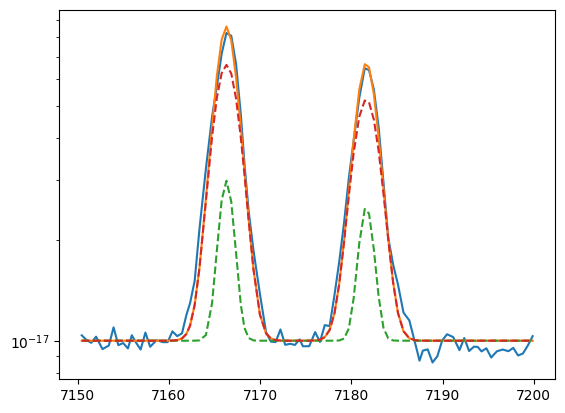

In [25]:
plt.plot(sii.wavelength, sii.flux)
bkg = 1e-17

siia_nar = gaussian(sii.wavelength, 0.3e-16, wave_cat['[SII]6730'], z=z_nar_oiii_4959, sigma=sigma_nar_oiii_4959)
siia_brd = gaussian(sii.wavelength, 1.5e-16, wave_cat['[SII]6730'], z=z_brd_oiii_4959, sigma=sigma_brd_oiii_4959)

siib_nar = gaussian(sii.wavelength, 0.4e-16, wave_cat['[SII]6716'], z=z_nar_oiii_4959, sigma=sigma_nar_oiii_4959)
siib_brd = gaussian(sii.wavelength, 2e-16, wave_cat['[SII]6716'], z=z_brd_oiii_4959, sigma=sigma_brd_oiii_4959)

siia = siia_nar + siia_brd
siib = siib_nar + siib_brd

plt.plot(sii.wavelength, siia + siib + bkg)
plt.plot(sii.wavelength, siia_nar + siib_nar + bkg, ls='--')
plt.plot(sii.wavelength, siia_brd + siib_brd + bkg, ls='--')
plt.yscale('log')

In [26]:
params_sii = Parameters()
params_sii.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_sii.add('z_ratio', value=z_ratio, vary=False)
params_sii.add('sigma_nar', value=sigma_nar_oiii_4959, vary=False)
params_sii.add('sigma_brd', value=sigma_brd_oiii_4959, vary=False)
params_sii.add('Siia_nar', value=0.3e-16, min=0.)
params_sii.add('Siia_brd', value=1.5e-16, min=0.)
params_sii.add('Siib_nar', value=0.4e-16, min=0.)
params_sii.add('Siib_brd', value=2.0e-16, min=0.)
params_sii.add('bkg', value=1e-17, min=0.)


def residual_sii(params_sii, x, data, uncertainty):
    
    z_nar = params_sii['z_nar']
    z_brd = params_sii['z_nar'] * params_sii['z_ratio']
    sigma_nar = params_sii['sigma_nar']
    sigma_brd = params_sii['sigma_brd']
    siia_nar_flux = params_sii['Siia_nar']
    siia_brd_flux = params_sii['Siia_brd']
    siib_nar_flux = params_sii['Siib_nar']
    siib_brd_flux = params_sii['Siib_brd']
    bkg = params_sii['bkg']
    
    x = sii.wavelength
    model_siia = gaussian(x, siia_nar_flux, wave_cat['[SII]6730'], z_nar, sigma_nar) + \
                 gaussian(x, siia_brd_flux, wave_cat['[SII]6730'], z_brd, sigma_brd)
    model_siib = gaussian(x, siib_nar_flux, wave_cat['[SII]6716'], z_nar, sigma_nar) + \
                 gaussian(x, siib_brd_flux, wave_cat['[SII]6716'], z_brd, sigma_brd)
    model = model_siia + model_siib
    return (model + bkg - sii.flux) / sii.noise

In [27]:
np.random.seed(2225)
out_sii = minimize(residual_sii, params_sii, args=(1, 1, 1),
                    method='emcee', burn=1000, steps=2500, thin=30)

100%|██████████████████████████████████████| 2500/2500 [00:23<00:00, 106.15it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 6 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 64.38720777 101.76535254  88.0434652  124.79265463 120.69715582
  54.92060523]


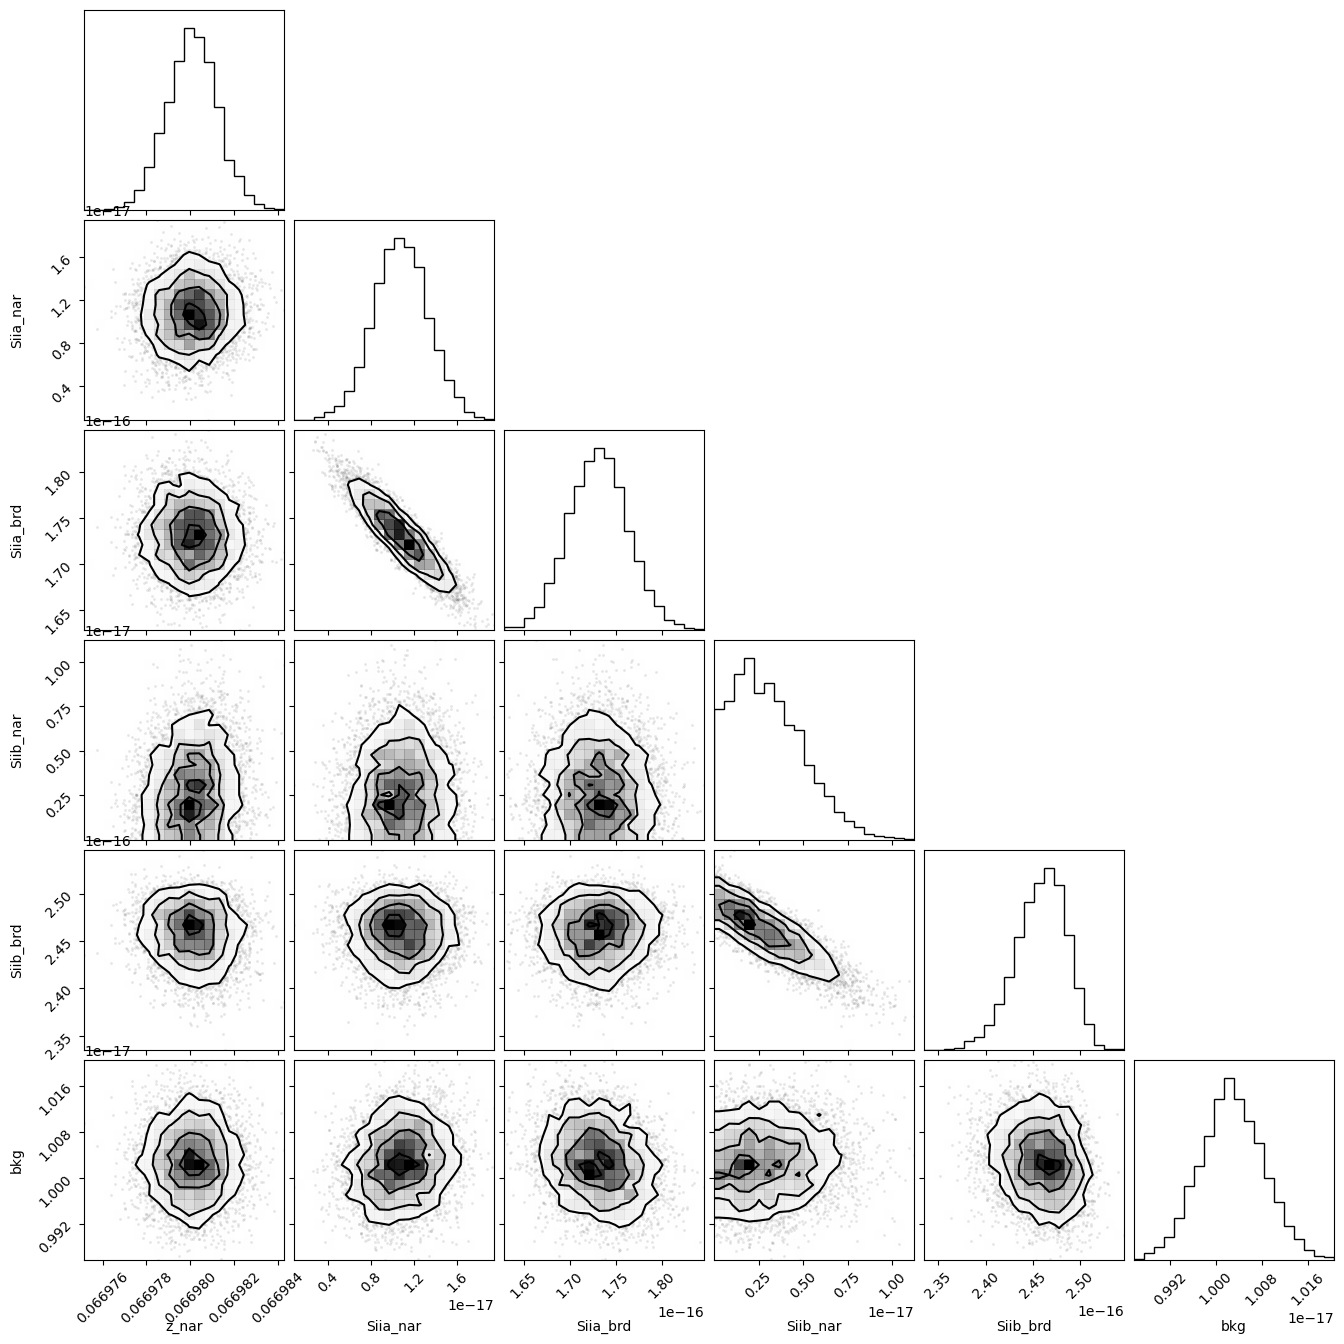

In [28]:
corner.corner(out_sii.flatchain, labels=out_sii.var_names);

In [29]:
out_sii

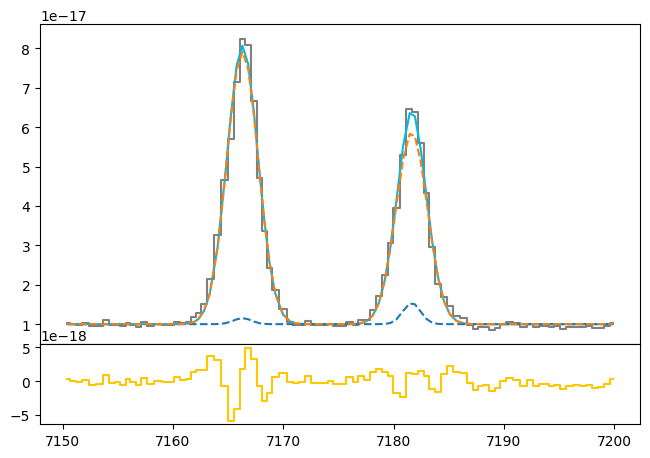

In [30]:
siia_nar_flux = out_sii.flatchain.Siia_nar.mean()
siia_nar_std = out_sii.flatchain.Siia_nar.std()

siia_brd_flux = out_sii.flatchain.Siia_brd.mean()
siia_brd_std = out_sii.flatchain.Siia_brd.std()

siib_nar_flux = out_sii.flatchain.Siib_nar.mean()
siib_nar_std = out_sii.flatchain.Siib_nar.std()

siib_brd_flux = out_sii.flatchain.Siib_brd.mean()
siib_brd_std = out_sii.flatchain.Siib_brd.std()

z_sii = out_sii.flatchain.z_nar.mean()
z_sii_std = out_sii.flatchain.z_nar.std()

bkg_sii = out_sii.flatchain.bkg.mean()
bkg_sii_std = out_sii.flatchain.bkg.std()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(sii.wavelength, sii.flux, color='gray', label='Data', where='mid')

siia_nar = gaussian(sii.wavelength, siia_nar_flux, wave_cat['[SII]6730'], z_sii, sigma_nar_oiii_4959)
siib_nar = gaussian(sii.wavelength, siib_nar_flux, wave_cat['[SII]6716'], z_sii, sigma_nar_oiii_4959)

siia_brd = gaussian(sii.wavelength, siia_brd_flux, wave_cat['[SII]6730'], z_sii * z_ratio, sigma_brd_oiii_4959)
siib_brd = gaussian(sii.wavelength, siib_brd_flux, wave_cat['[SII]6716'], z_sii * z_ratio, sigma_brd_oiii_4959)

siia = siia_nar + siia_brd
siib = siib_nar + siib_brd

ax.plot(sii.wavelength, bkg_sii + siia + siib, color=c[0])
ax.plot(sii.wavelength, bkg_sii + siia_nar + siib_nar, ls='--')
ax.plot(sii.wavelength, bkg_sii + siia_brd + siib_brd, ls='--')
#plt.yscale('log')
ax1.step(sii.wavelength, sii.flux - bkg_sii - siia - siib, color=c[3], where='mid')

#ls_siib = (wave_cat['[SII]6716'] * (1 + z_sii)) + (3 * sigma_brd_oiii_4959)
#li_siib = (wave_cat['[SII]6716'] * (1 + z_sii)) - (3 * sigma_brd_oiii_4959)

#ls_siia = (wave_cat['[SII]6730'] * (1 + z_sii)) + (3 * sigma_brd_oiii_4959)
#li_siia = (wave_cat['[SII]6730'] * (1 + z_sii)) - (3 * sigma_brd_oiii_4959)

#ax.axvline(ls_siib, ls='--', color='gray', lw=0.8)
#ax.axvline(li_siib, ls='--', color='gray', lw=0.8)

#ax.axvline(ls_siia, ls='--', color='gray', lw=0.8)
#ax.axvline(li_siia, ls='--', color='gray', lw=0.8)

In [31]:
# EW
EW_SII_6730_nar = ufloat(siia_nar_flux, siia_nar_std) / ufloat(bkg_sii, bkg_sii_std)
EW_SII_6730_brd = ufloat(siia_brd_flux, siia_brd_std) / ufloat(bkg_sii, bkg_sii_std)
EW_SII_6730 = (ufloat(siia_nar_flux, siia_nar_std) + ufloat(siia_brd_flux, siia_brd_std)) / ufloat(bkg_sii, bkg_sii_std)

EW_SII_6716_nar = ufloat(siib_nar_flux, siib_nar_std) / ufloat(bkg_sii, bkg_sii_std)
EW_SII_6716_brd = ufloat(siib_brd_flux, siib_brd_std) / ufloat(bkg_sii, bkg_sii_std)
EW_SII_6716 = (ufloat(siib_nar_flux, siib_nar_std) + ufloat(siib_brd_flux, siib_brd_std)) / ufloat(bkg_sii, bkg_sii_std)

mask_siib = (sii.wavelength >= li_siib) & (sii.wavelength < ls_siib)
mask_siia = (sii.wavelength >= li_siia) & (sii.wavelength < ls_siia)

c_mask_sii = (sii.wavelength > ls_siia) + (sii.wavelength < li_siib)

N_siib = len(sii.wavelength[mask_siib])
N_siia = len(sii.wavelength[mask_siia])

sigmac_sii = np.std(sii.flux[c_mask_sii])

# Uncertainties added

sigmal_siib_nar = sigmac_sii * np.sqrt(N_siib + (EW_SII_6716_nar.nominal_value/dLam))
sigmal_siib_brd = sigmac_sii * np.sqrt(N_siib + (EW_SII_6716_brd.nominal_value/dLam))

sigmal_siia_nar = sigmac_sii * np.sqrt(N_siia + (EW_SII_6730_nar.nominal_value/dLam))
sigmal_siia_brd = sigmac_sii * np.sqrt(N_siia + (EW_SII_6730_brd.nominal_value/dLam))

print('Previous nar error (Siib)', siib_nar_std)
print('Previous brd error (Siib)', siib_brd_std)

print('Previous nar error (Siia)', siia_nar_std)
print('Previous brd error (Siia)', siia_brd_std)

# Final uncertainties
siib_nar_std = np.sqrt((siib_nar_std**2) + (sigmal_siib_nar**2))
siib_brd_std = np.sqrt((siib_brd_std**2) + (sigmal_siib_brd**2))

siia_nar_std = np.sqrt((siia_nar_std**2) + (sigmal_siia_nar**2))
siia_brd_std = np.sqrt((siia_brd_std**2) + (sigmal_siia_brd**2))

print('New nar error (Siib)', siib_nar_std)
print('New brd error (Siib)', siib_brd_std)

print('New nar error (Siia)', siia_nar_std)
print('New brd error (Siia)', siia_brd_std)

## [NII]5755

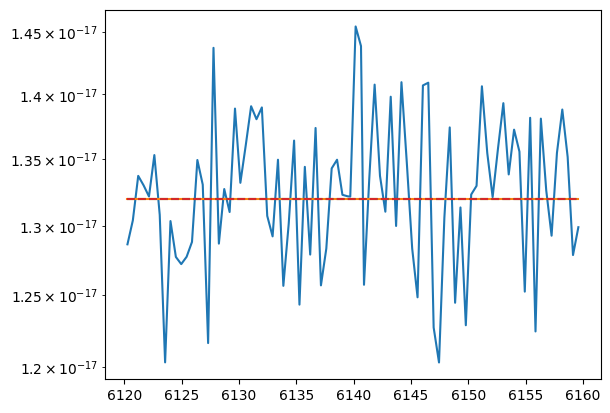

In [32]:
plt.plot(nii_5755.wavelength, nii_5755.flux)
bkg = 1.32e-17

niic_nar = gaussian(nii_5755.wavelength, 0.0, wave_cat['[NII]5755'], z=z_nar_oiii_4959, sigma=sigma_nar_oiii_4959)
niic_brd = gaussian(nii_5755.wavelength, 0.0, wave_cat['[NII]5755'], z=z_brd_oiii_4959, sigma=sigma_brd_oiii_4959)

niic = niic_nar + niic_brd

plt.plot(nii_5755.wavelength, niic + bkg)
plt.plot(nii_5755.wavelength, niic_nar + bkg, ls='--')
plt.plot(nii_5755.wavelength, niic_brd + bkg, ls='--')
plt.yscale('log')

In [33]:
nii_5755_rms = np.sqrt(np.mean((nii_5755.flux)**2))
nii_5755_flux = 3 * nii_5755_rms

niic_nar_flux = nii_5755_flux / (1 + brd_to_nar)
niic_nar_std = 0.0

niic_brd_flux = niic_nar_flux * brd_to_nar
niic_brd_std = 0.0

### Leave the fit just in case

In [34]:
params_nii = Parameters()
params_nii.add('z_nar', value=z_nar_oiii_4959, vary=False)
params_nii.add('z_ratio', value=z_ratio, vary=False)
params_nii.add('sigma_nar', value=sigma_nar_oiii_4959, vary=False)
params_nii.add('sigma_brd', value=sigma_brd_oiii_4959, vary=False)
params_nii.add('Niic_nar', value=0.0, min=0., vary=False)
params_nii.add('Niic_brd', value=0.0, min=0., vary=False)
params_nii.add('bkg', value=1.32e-17, min=0.)

def residual_nii(params_nii, x, data, uncertainty):
    
    z_nar = params_nii['z_nar']
    z_brd = params_nii['z_nar'] * params_nii['z_ratio']
    sigma_nar = params_nii['sigma_nar']
    sigma_brd = params_nii['sigma_brd']
    niic_nar_flux = params_nii['Niic_nar']
    niic_brd_flux = params_nii['Niic_brd']
    bkg = params_nii['bkg']
    
    x = nii_5755.wavelength
    model = gaussian(x, niic_nar_flux, wave_cat['[NII]5755'], z_nar, sigma_nar) + \
            gaussian(x, niic_brd_flux, wave_cat['[NII]5755'], z_brd, sigma_brd)
    return (model + bkg - nii_5755.flux) / nii_5755.noise

In [35]:
np.random.seed(2225)
out_nii = minimize(residual_nii, params_nii, args=(1, 1, 1),
                   method='emcee', burn=1000, steps=2500, thin=30)

100%|██████████████████████████████████████| 2500/2500 [00:18<00:00, 137.19it/s]


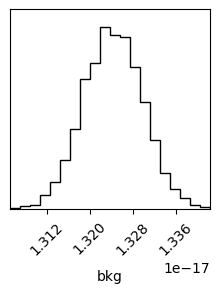

In [36]:
corner.corner(out_nii.flatchain, labels=out_nii.var_names);

In [37]:
out_nii

In [38]:
bkg_nii = out_nii.flatchain.bkg.mean()
bkg_nii_std = out_nii.flatchain.bkg.std()

# EW
EW_NII_5755_nar = ufloat(niic_nar_flux, niic_nar_std) / ufloat(bkg_nii, bkg_nii_std)
EW_NII_5755_brd = ufloat(niic_brd_flux, niic_brd_std) / ufloat(bkg_nii, bkg_nii_std)
EW_NII_5755 = (ufloat(niic_nar_flux, niic_nar_std) + ufloat(niic_brd_flux, niic_brd_std)) / ufloat(bkg_nii, bkg_nii_std)

## H$\beta$

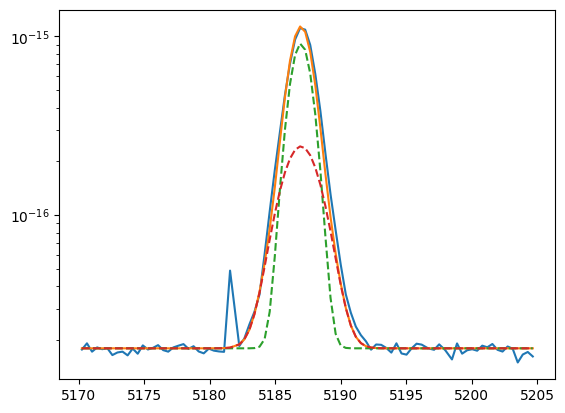

In [39]:
plt.plot(hbeta.wavelength, hbeta.flux)
bkg = 1.8e-17

hb_nar = gaussian(hbeta.wavelength, 1.8e-15, wave_cat['Hb'], z=z_nar_oiii_4959, sigma=sigma_nar_oiii_4959)
hb_brd = gaussian(hbeta.wavelength, 8e-16, wave_cat['Hb'], z=z_brd_oiii_4959, sigma=sigma_brd_oiii_4959)

hb = hb_nar + hb_brd

plt.plot(hbeta.wavelength, hb + bkg)
plt.plot(hbeta.wavelength, hb_nar + bkg, ls='--')
plt.plot(hbeta.wavelength, hb_brd + bkg, ls='--')
plt.yscale('log')

In [40]:
params_hb = Parameters()
params_hb.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_hb.add('z_ratio', value=z_ratio, vary=False)
params_hb.add('sigma_nar', value=sigma_nar_oiii_4959, vary=False)
params_hb.add('sigma_brd', value=sigma_brd_oiii_4959, vary=False)
params_hb.add('Hb_nar', value=1.8e-15, min=0.)
params_hb.add('Hb_brd', value=8.0e-16, min=0.)
params_hb.add('bkg', value=1.8e-17, min=0.)

def residual_hb(params_hb, x, data, uncertainty):
    
    z_nar = params_hb['z_nar']
    z_brd = params_hb['z_nar'] * params_hb['z_ratio']
    sigma_nar = params_hb['sigma_nar']
    sigma_brd = params_hb['sigma_brd']
    hb_nar_flux = params_hb['Hb_nar']
    hb_brd_flux = params_hb['Hb_brd']
    bkg = params_hb['bkg']
    
    x = hbeta.wavelength
    model = gaussian(x, hb_nar_flux, wave_cat['Hb'], z_nar, sigma_nar) + \
            gaussian(x, hb_brd_flux, wave_cat['Hb'], z_brd, sigma_brd)
    return (model + bkg - hbeta.flux) / hbeta.noise

In [41]:
np.random.seed(2225)
out_hb = minimize(residual_hb, params_hb, args=(1, 1, 1),
                   method='emcee', burn=1000, steps=2500, thin=30)

100%|██████████████████████████████████████| 2500/2500 [00:18<00:00, 133.51it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 3 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [22.4347956  87.59231848 85.79050911 62.84729277]


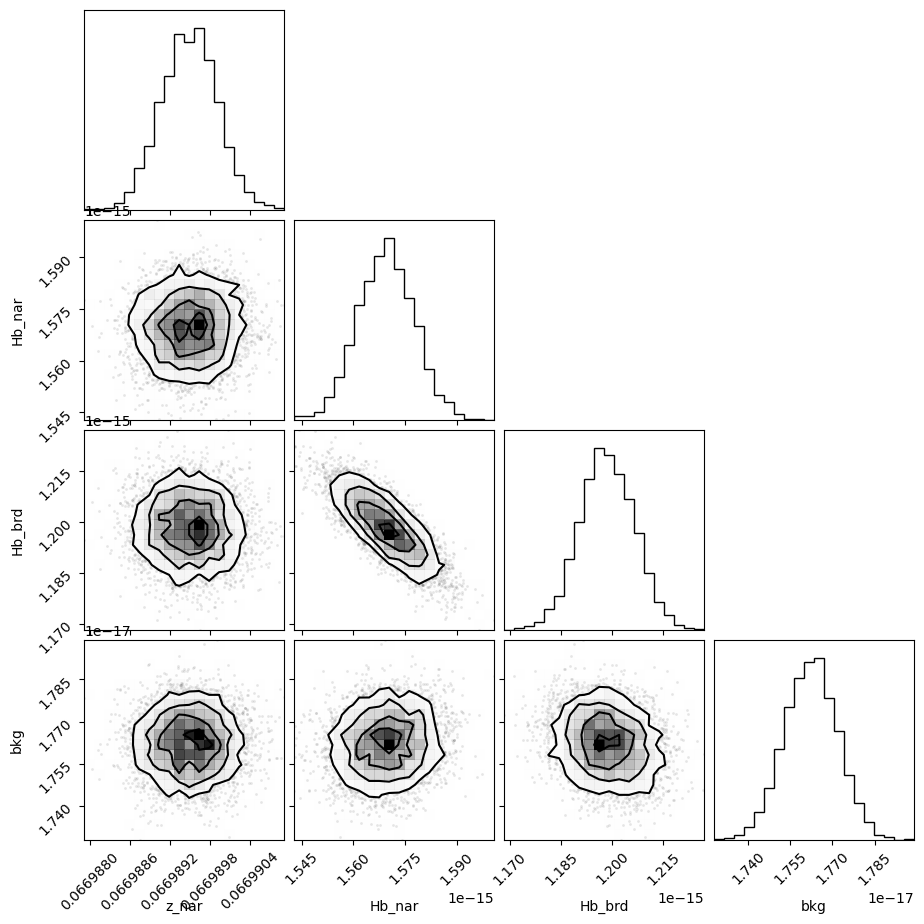

In [42]:
corner.corner(out_hb.flatchain, labels=out_hb.var_names);

In [43]:
out_hb

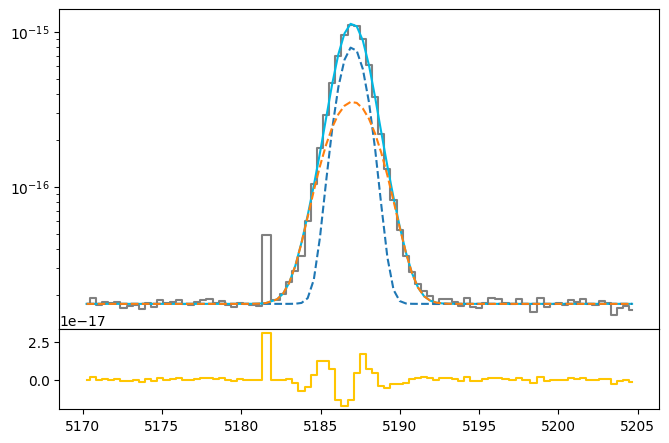

In [44]:
hb_nar_flux = out_hb.flatchain.Hb_nar.mean()
hb_nar_std = out_hb.flatchain.Hb_nar.std()

hb_brd_flux = out_hb.flatchain.Hb_brd.mean()
hb_brd_std = out_hb.flatchain.Hb_brd.std()

z_hb = out_hb.flatchain.z_nar.mean()
z_hb_std = out_hb.flatchain.z_nar.std()

bkg_hb = out_hb.flatchain.bkg.mean()
bkg_hb_std = out_hb.flatchain.bkg.std()

# Search for good initial guess

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(hbeta.wavelength, hbeta.flux, color='gray', label='Data', where='mid')

hb_nar = gaussian(hbeta.wavelength, hb_nar_flux, wave_cat['Hb'], z_hb, sigma_nar_oiii_4959)
hb_brd = gaussian(hbeta.wavelength, hb_brd_flux, wave_cat['Hb'], z_hb * z_ratio, sigma_brd_oiii_4959)

hb = hb_nar + hb_brd

ax.plot(hbeta.wavelength, bkg_hb + hb, color=c[0])
ax.plot(hbeta.wavelength, bkg_hb + hb_nar, ls='--')
ax.plot(hbeta.wavelength, bkg_hb + hb_brd, ls='--')
ax.set_yscale('log')
ax1.step(hbeta.wavelength, hbeta.flux - bkg_hb - hb, color=c[3], where='mid')

#ls_hb = (wave_cat['Hb'] * (1 + z_hb)) + (4 * sigma_brd_oiii_4959)
#li_hb = (wave_cat['Hb'] * (1 + z_hb)) - (4 * sigma_brd_oiii_4959)

#ax.axvline(ls_hb, ls='--', color='black', lw=0.8)
#ax.axvline(li_hb, ls='--', color='black', lw=0.8)

In [45]:
# EW
EW_Hb_nar = ufloat(hb_nar_flux, hb_nar_std) / ufloat(bkg_hb, bkg_hb_std)
EW_Hb_brd = ufloat(hb_brd_flux, hb_brd_std) / ufloat(bkg_hb, bkg_hb_std)
EW_Hb = (ufloat(hb_nar_flux, hb_nar_std) + ufloat(hb_brd_flux, hb_brd_std)) / ufloat(bkg_hb, bkg_hb_std)

mask_hb = (hbeta.wavelength >= li_hb) & (hbeta.wavelength < ls_hb)
N_hb = len(hbeta.wavelength[mask_hb])
sigmac_hb = np.std(hbeta.flux[np.logical_not(mask_hb)])

# Uncertainties added
sigmal_hb_nar = sigmac_hb * np.sqrt(N_hb + (EW_Hb_nar.nominal_value/dLam))
sigmal_hb_brd = sigmac_hb * np.sqrt(N_hb + (EW_Hb_brd.nominal_value/dLam))

print('Previous narrow error:', hb_nar_std)
print('Previous broad error:', hb_brd_std)

# Final uncertainties
hb_nar_std = np.sqrt(hb_nar_std**2 + sigmal_hb_nar**2)
hb_brd_std = np.sqrt(hb_brd_std**2 + sigmal_hb_brd**2)

print('New narrow error:', hb_nar_std)
print('New broad error:', hb_brd_std)

## H$\gamma$

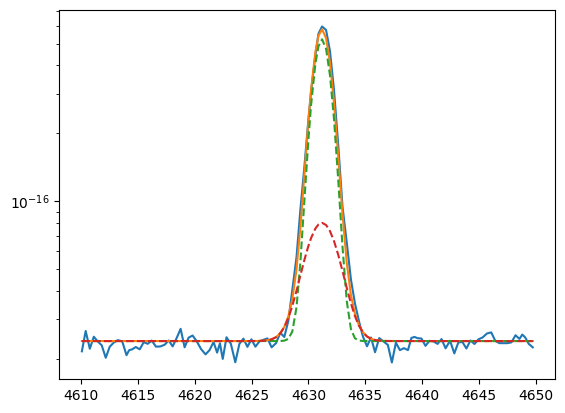

In [46]:
plt.plot(hgamma.wavelength, hgamma.flux)
bkg = 2.4e-17

hg_nar = gaussian(hgamma.wavelength, 1e-15, wave_cat['Hg'], z=z_nar_oiii_4959, sigma=sigma_nar_oiii_4959)
hg_brd = gaussian(hgamma.wavelength, 2e-16, wave_cat['Hg'], z=z_brd_oiii_4959, sigma=sigma_brd_oiii_4959)

hg = hg_nar + hg_brd

plt.plot(hgamma.wavelength, hg + bkg)
plt.plot(hgamma.wavelength, hg_nar + bkg, ls='--')
plt.plot(hgamma.wavelength, hg_brd + bkg, ls='--')
plt.yscale('log')

In [47]:
params_hg = Parameters()
params_hg.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_hg.add('z_ratio', value=z_ratio, vary=False)
params_hg.add('sigma_nar', value=sigma_nar_oiii_4959, vary=False)
params_hg.add('sigma_brd', value=sigma_brd_oiii_4959, vary=False)
params_hg.add('Hg_nar', value=1.0e-15, min=0.)
params_hg.add('Hg_brd', value=2.0e-16, min=0.)
params_hg.add('bkg', value=2.4e-17, min=0.)

def residual_hg(params_hg, x, data, uncertainty):
    
    z_nar = params_hg['z_nar']
    z_brd = params_hg['z_nar'] * params_hg['z_ratio']
    sigma_nar = params_hg['sigma_nar']
    sigma_brd = params_hg['sigma_brd']
    hg_nar_flux = params_hg['Hg_nar']
    hg_brd_flux = params_hg['Hg_brd']
    bkg = params_hg['bkg']
    
    x = hgamma.wavelength
    model = gaussian(x, hg_nar_flux, wave_cat['Hg'], z_nar, sigma_nar) + \
            gaussian(x, hg_brd_flux, wave_cat['Hg'], z_brd, sigma_brd)
    return (model + bkg - hgamma.flux) / hgamma.noise

In [48]:
np.random.seed(2225)
out_hg = minimize(residual_hg, params_hg, args=(1, 1, 1),
                   method='emcee', burn=1000, steps=2500, thin=30)

100%|██████████████████████████████████████| 2500/2500 [00:19<00:00, 128.58it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 3 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 44.24972333  81.36964582 112.80036625  61.91742724]


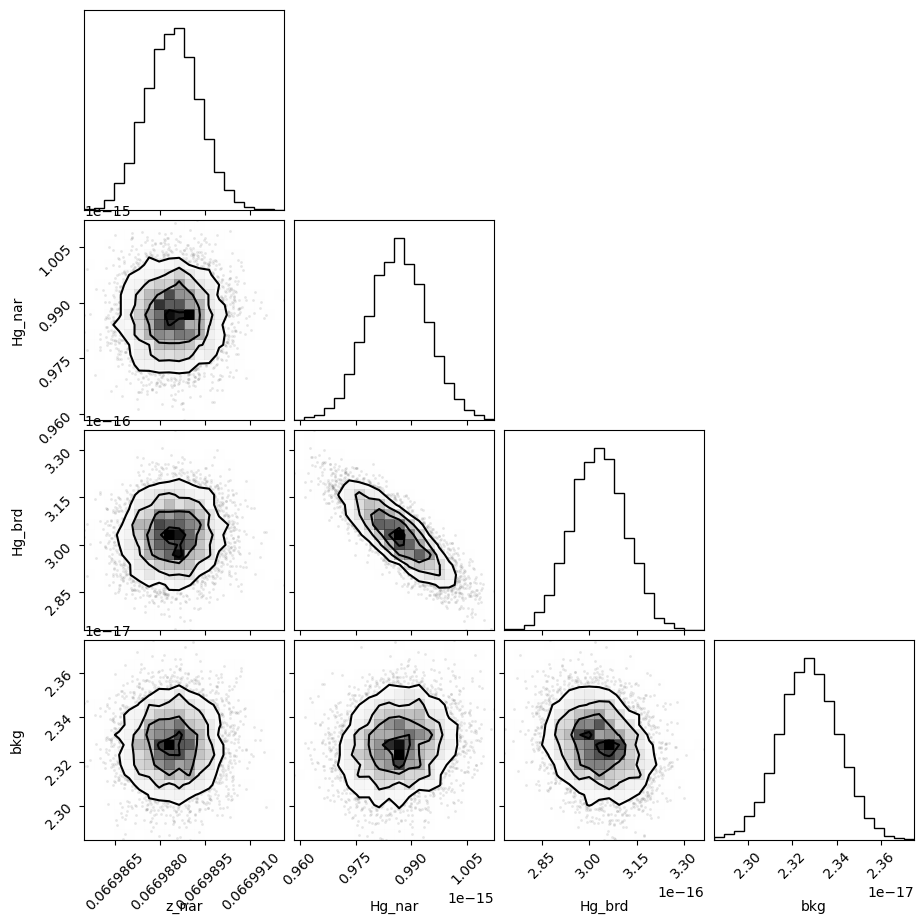

In [49]:
corner.corner(out_hg.flatchain, labels=out_hg.var_names);

In [50]:
out_hg

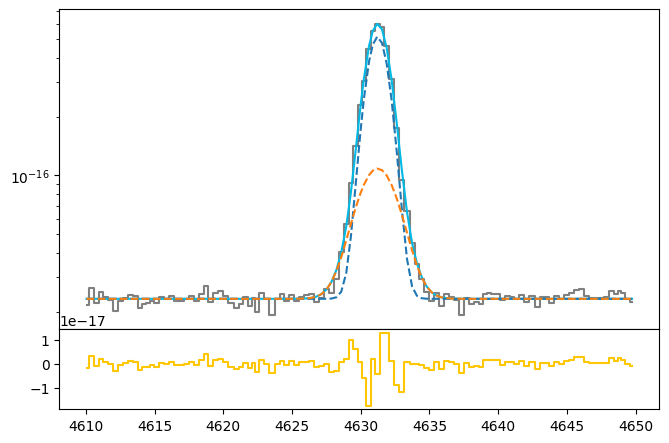

In [51]:
hg_nar_flux = out_hg.flatchain.Hg_nar.mean()
hg_nar_std = out_hg.flatchain.Hg_nar.std()

hg_brd_flux = out_hg.flatchain.Hg_brd.mean()
hg_brd_std = out_hg.flatchain.Hg_brd.std()

z_hg = out_hg.flatchain.z_nar.mean()
z_hg_std = out_hg.flatchain.z_nar.std()

bkg_hg = out_hg.flatchain.bkg.mean()
bkg_hg_std = out_hg.flatchain.bkg.std()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(hgamma.wavelength, hgamma.flux, color='gray', label='Data', where='mid')

hg_nar = gaussian(hgamma.wavelength, hg_nar_flux, wave_cat['Hg'], z_hg, sigma_nar_oiii_4959)
hg_brd = gaussian(hgamma.wavelength, hg_brd_flux, wave_cat['Hg'], z_hg * z_ratio, sigma_brd_oiii_4959)

hg = hg_nar + hg_brd

ax.plot(hgamma.wavelength, bkg_hg + hg, color=c[0])
ax.plot(hgamma.wavelength, bkg_hg + hg_nar, ls='--')
ax.plot(hgamma.wavelength, bkg_hg + hg_brd, ls='--')
ax.set_yscale('log')
ax1.step(hgamma.wavelength, hgamma.flux - bkg_hg - hg, color=c[3], where='mid')

#ls_hg = (wave_cat['Hg'] * (1 + z_hg)) + (3 * sigma_brd_oiii_4959)
#li_hg = (wave_cat['Hg'] * (1 + z_hg)) - (3 * sigma_brd_oiii_4959)

#ax.axvline(ls_hg, ls='--', color='black', lw=0.8)
#ax.axvline(li_hg, ls='--', color='black', lw=0.8)

In [52]:
# EW
EW_Hg_nar = ufloat(hg_nar_flux, hg_nar_std) / ufloat(bkg_hg, bkg_hg_std)
EW_Hg_brd = ufloat(hg_brd_flux, hg_brd_std) / ufloat(bkg_hg, bkg_hg_std)
EW_Hg = (ufloat(hg_nar_flux, hg_nar_std) + ufloat(hg_brd_flux, hg_brd_std)) / ufloat(bkg_hg, bkg_hg_std)

mask_hg = (hgamma.wavelength >= li_hg) & (hgamma.wavelength < ls_hg)
N_hg = len(hgamma.wavelength[mask_hg])
sigmac_hg = np.std(hgamma.flux[np.logical_not(mask_hg)])

# Uncertainties added
sigmal_hg_nar = sigmac_hg * np.sqrt(N_hg + (EW_Hg_nar.nominal_value/dLam))
sigmal_hg_brd = sigmac_hg * np.sqrt(N_hg + (EW_Hg_brd.nominal_value/dLam))

print('Previous narrow error:', hg_nar_std)
print('Previous broad error:', hg_brd_std)

# Final uncertainties
hg_nar_std = np.sqrt(hg_nar_std**2 + sigmal_hg_nar**2)
hg_brd_std = np.sqrt(hg_brd_std**2 + sigmal_hg_brd**2)

print('New narrow error:', hg_nar_std)
print('New broad error:', hg_brd_std)

## H$\delta$

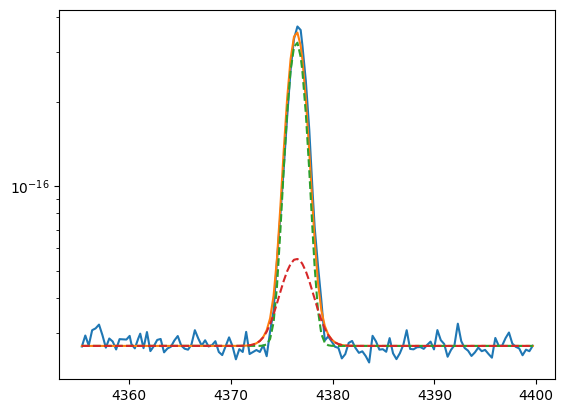

In [53]:
plt.plot(hdelta.wavelength, hdelta.flux)
bkg = 2.7e-17

hd_nar = gaussian(hdelta.wavelength, 6e-16, wave_cat['Hd'], z=z_nar_oiii_4959, sigma=sigma_nar_oiii_4959)
hd_brd = gaussian(hdelta.wavelength, 1e-16, wave_cat['Hd'], z=z_brd_oiii_4959, sigma=sigma_brd_oiii_4959)

hd = hd_nar + hd_brd

plt.plot(hdelta.wavelength, hd + bkg)
plt.plot(hdelta.wavelength, hd_nar + bkg, ls='--')
plt.plot(hdelta.wavelength, hd_brd + bkg, ls='--')
plt.yscale('log')

In [54]:
params_hd = Parameters()
params_hd.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_hd.add('z_ratio', value=z_ratio, vary=False)
params_hd.add('sigma_nar', value=sigma_nar_oiii_4959, vary=False)
params_hd.add('sigma_brd', value=sigma_brd_oiii_4959, vary=False)
params_hd.add('Hd_nar', value=6.0e-16, min=0.)
params_hd.add('Hd_brd', value=1.0e-16, min=0.)
params_hd.add('bkg', value=2.7e-17, min=0.)

def residual_hd(params_hd, x, data, uncertainty):
    
    z_nar = params_hd['z_nar']
    z_brd = params_hd['z_nar'] * params_hd['z_ratio']
    sigma_nar = params_hd['sigma_nar']
    sigma_brd = params_hd['sigma_brd']
    hd_nar_flux = params_hd['Hd_nar']
    hd_brd_flux = params_hd['Hd_brd']
    bkg = params_hd['bkg']
    
    x = hdelta.wavelength
    model = gaussian(x, hd_nar_flux, wave_cat['Hd'], z_nar, sigma_nar) + \
            gaussian(x, hd_brd_flux, wave_cat['Hd'], z_brd, sigma_brd)
    return (model + bkg - hdelta.flux) / hdelta.noise

In [55]:
np.random.seed(2225)
out_hd = minimize(residual_hd, params_hd, args=(1, 1, 1),
                   method='emcee', burn=1000, steps=2500, thin=30)

100%|██████████████████████████████████████| 2500/2500 [00:19<00:00, 125.48it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 1 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [27.95107545 60.73517434 48.95572754 41.75307521]


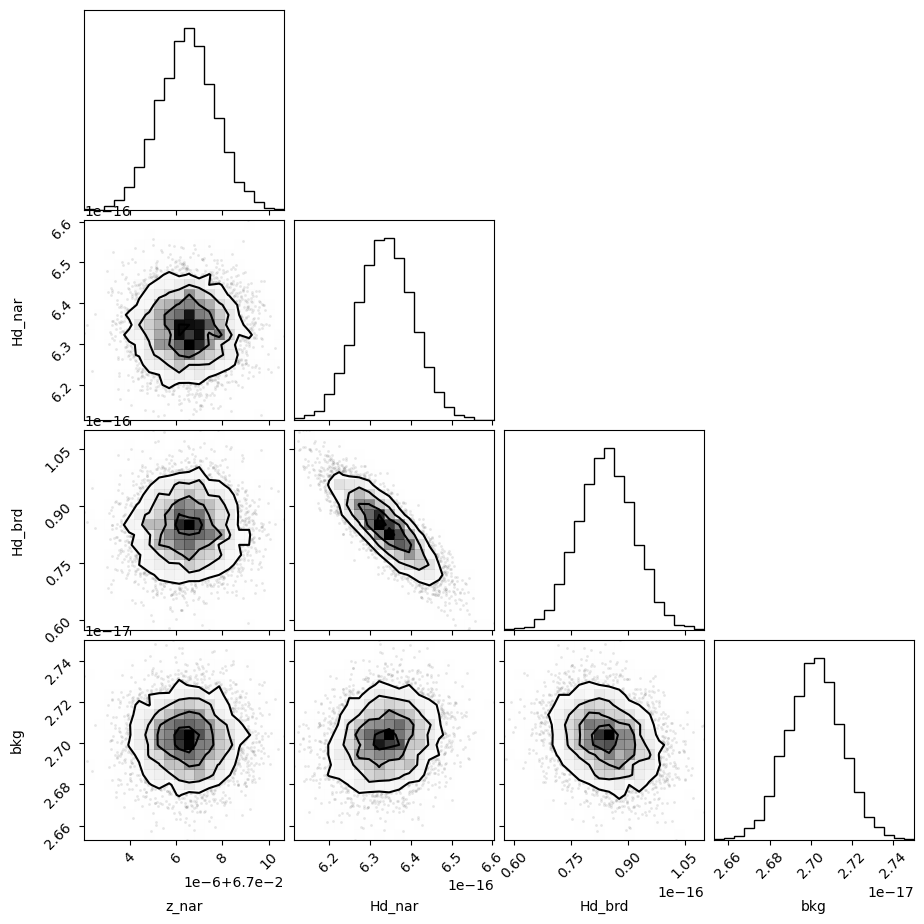

In [56]:
corner.corner(out_hd.flatchain, labels=out_hd.var_names);

In [57]:
out_hd

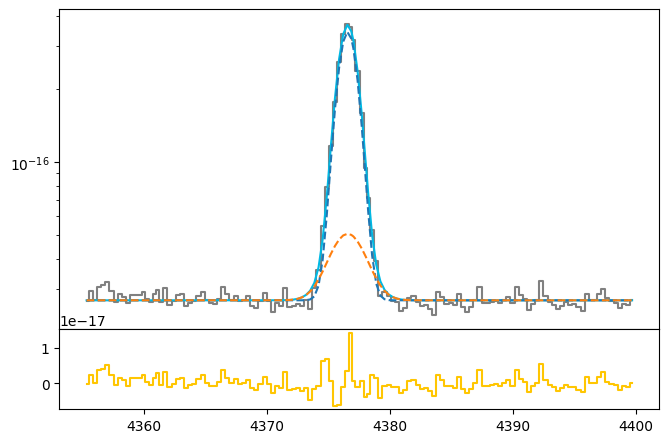

In [58]:
hd_nar_flux = out_hd.flatchain.Hd_nar.mean()
hd_nar_std = out_hd.flatchain.Hd_nar.std()

hd_brd_flux = out_hd.flatchain.Hd_brd.mean()
hd_brd_std = out_hd.flatchain.Hd_brd.std()

z_hd = out_hd.flatchain.z_nar.mean()
z_hd_std = out_hd.flatchain.z_nar.std()

bkg_hd = out_hd.flatchain.bkg.mean()
bkg_hd_std = out_hd.flatchain.bkg.std()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(hdelta.wavelength, hdelta.flux, color='gray', label='Data', where='mid')

hd_nar = gaussian(hdelta.wavelength, hd_nar_flux, wave_cat['Hd'], z_hd, sigma_nar_oiii_4959)
hd_brd = gaussian(hdelta.wavelength, hd_brd_flux, wave_cat['Hd'], z_hd * z_ratio, sigma_brd_oiii_4959)

hd = hd_nar + hd_brd

ax.plot(hdelta.wavelength, bkg_hd + hd, color=c[0])
ax.plot(hdelta.wavelength, bkg_hd + hd_nar, ls='--')
ax.plot(hdelta.wavelength, bkg_hd + hd_brd, ls='--')
ax.set_yscale('log')
ax1.step(hdelta.wavelength, hdelta.flux - bkg_hd - hd, color=c[3], where='mid')

#ls_hd = (wave_cat['Hd'] * (1 + z_hd)) + (3 * sigma_brd_oiii_4959)
#li_hd = (wave_cat['Hd'] * (1 + z_hd)) - (3 * sigma_brd_oiii_4959)

#ax.axvline(ls_hd, ls='--', color='black', lw=0.8)
#ax.axvline(li_hd, ls='--', color='black', lw=0.8)

In [59]:
# EW
EW_Hd_nar = ufloat(hd_nar_flux, hd_nar_std) / ufloat(bkg_hd, bkg_hd_std)
EW_Hd_brd = ufloat(hd_brd_flux, hd_brd_std) / ufloat(bkg_hd, bkg_hd_std)
EW_Hd = (ufloat(hd_nar_flux, hd_nar_std) + ufloat(hd_brd_flux, hd_brd_std)) / ufloat(bkg_hd, bkg_hd_std)

mask_hd = (hdelta.wavelength >= li_hd) & (hdelta.wavelength < ls_hd)
N_hd = len(hdelta.wavelength[mask_hd])
sigmac_hd = np.std(hdelta.flux[np.logical_not(mask_hd)])

# Uncertainties added
sigmal_hd_nar = sigmac_hd * np.sqrt(N_hd + (EW_Hd_nar.nominal_value/dLam))
sigmal_hd_brd = sigmac_hd * np.sqrt(N_hd + (EW_Hd_brd.nominal_value/dLam))

print('Previous narrow error:', hd_nar_std)
print('Previous broad error:', hd_brd_std)

# Final uncertainties
hd_nar_std = np.sqrt(hd_nar_std**2 + sigmal_hd_nar**2)
hd_brd_std = np.sqrt(hd_brd_std**2 + sigmal_hd_brd**2)

print('New narrow error:', hd_nar_std)
print('New broad error:', hd_brd_std)

## [SII]4068 + [SII]4076

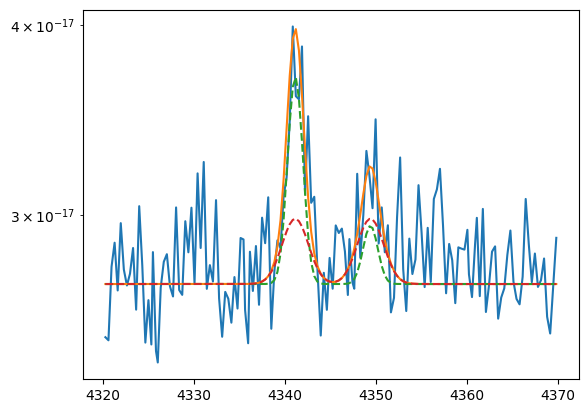

In [60]:
plt.plot(sii2.wavelength, sii2.flux)
bkg = 2.7e-17

siic_nar = gaussian(sii2.wavelength, 0.5e-17, wave_cat['[SII]4076'], z=z_nar_oiii_4959, sigma=sigma_nar_oiii_4959)
siic_brd = gaussian(sii2.wavelength, 1.0e-17, wave_cat['[SII]4076'], z=z_brd_oiii_4959, sigma=sigma_brd_oiii_4959)

siid_nar = gaussian(sii2.wavelength, 2.0e-17, wave_cat['[SII]4068'], z=z_nar_oiii_4959, sigma=sigma_nar_oiii_4959)
siid_brd = gaussian(sii2.wavelength, 1.0e-17, wave_cat['[SII]4068'], z=z_brd_oiii_4959, sigma=sigma_brd_oiii_4959)

siic = siic_nar + siic_brd
siid = siid_nar + siid_brd

plt.plot(sii2.wavelength, siic + siid + bkg)
plt.plot(sii2.wavelength, siic_nar + siid_nar + bkg, ls='--')
plt.plot(sii2.wavelength, siic_brd + siid_brd + bkg, ls='--')
plt.yscale('log')

In [61]:
params_sii2 = Parameters()
params_sii2.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_sii2.add('z_ratio', value=z_ratio, vary=False)
params_sii2.add('sigma_nar', value=sigma_nar_oiii_4959, vary=False)
params_sii2.add('sigma_brd', value=sigma_brd_oiii_4959, vary=False)
params_sii2.add('Siic_nar', value=0.5e-17, min=0.)
params_sii2.add('Siic_brd', value=1.0e-17, min=0.)
params_sii2.add('Siid_nar', value=2.0e-17, min=0.)
params_sii2.add('Siid_brd', value=1.0e-17, min=0.)
params_sii2.add('bkg', value=2.7e-17, min=0.)


def residual_sii2(params_sii2, x, data, uncertainty):
    
    z_nar = params_sii2['z_nar']
    z_brd = params_sii2['z_nar'] * params_sii2['z_ratio']
    sigma_nar = params_sii2['sigma_nar']
    sigma_brd = params_sii2['sigma_brd']
    siic_nar_flux = params_sii2['Siic_nar']
    siic_brd_flux = params_sii2['Siic_brd']
    siid_nar_flux = params_sii2['Siid_nar']
    siid_brd_flux = params_sii2['Siid_brd']
    bkg = params_sii2['bkg']
    
    x = sii2.wavelength
    model_siic = gaussian(x, siic_nar_flux, wave_cat['[SII]4076'], z_nar, sigma_nar) + \
                 gaussian(x, siic_brd_flux, wave_cat['[SII]4076'], z_brd, sigma_brd)
    model_siid = gaussian(x, siid_nar_flux, wave_cat['[SII]4068'], z_nar, sigma_nar) + \
                 gaussian(x, siid_brd_flux, wave_cat['[SII]4068'], z_brd, sigma_brd)
    model = model_siic + model_siid
    return (model + bkg - sii2.flux) / sii2.noise

In [62]:
np.random.seed(2225)
out_sii2 = minimize(residual_sii2, params_sii2, args=(1, 1, 1),
                    method='emcee', burn=1000, steps=2500, thin=30)

100%|██████████████████████████████████████| 2500/2500 [00:22<00:00, 112.04it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 6 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [56.20772602 63.42412601 67.81225684 62.43392058 62.58962975 56.25986776]


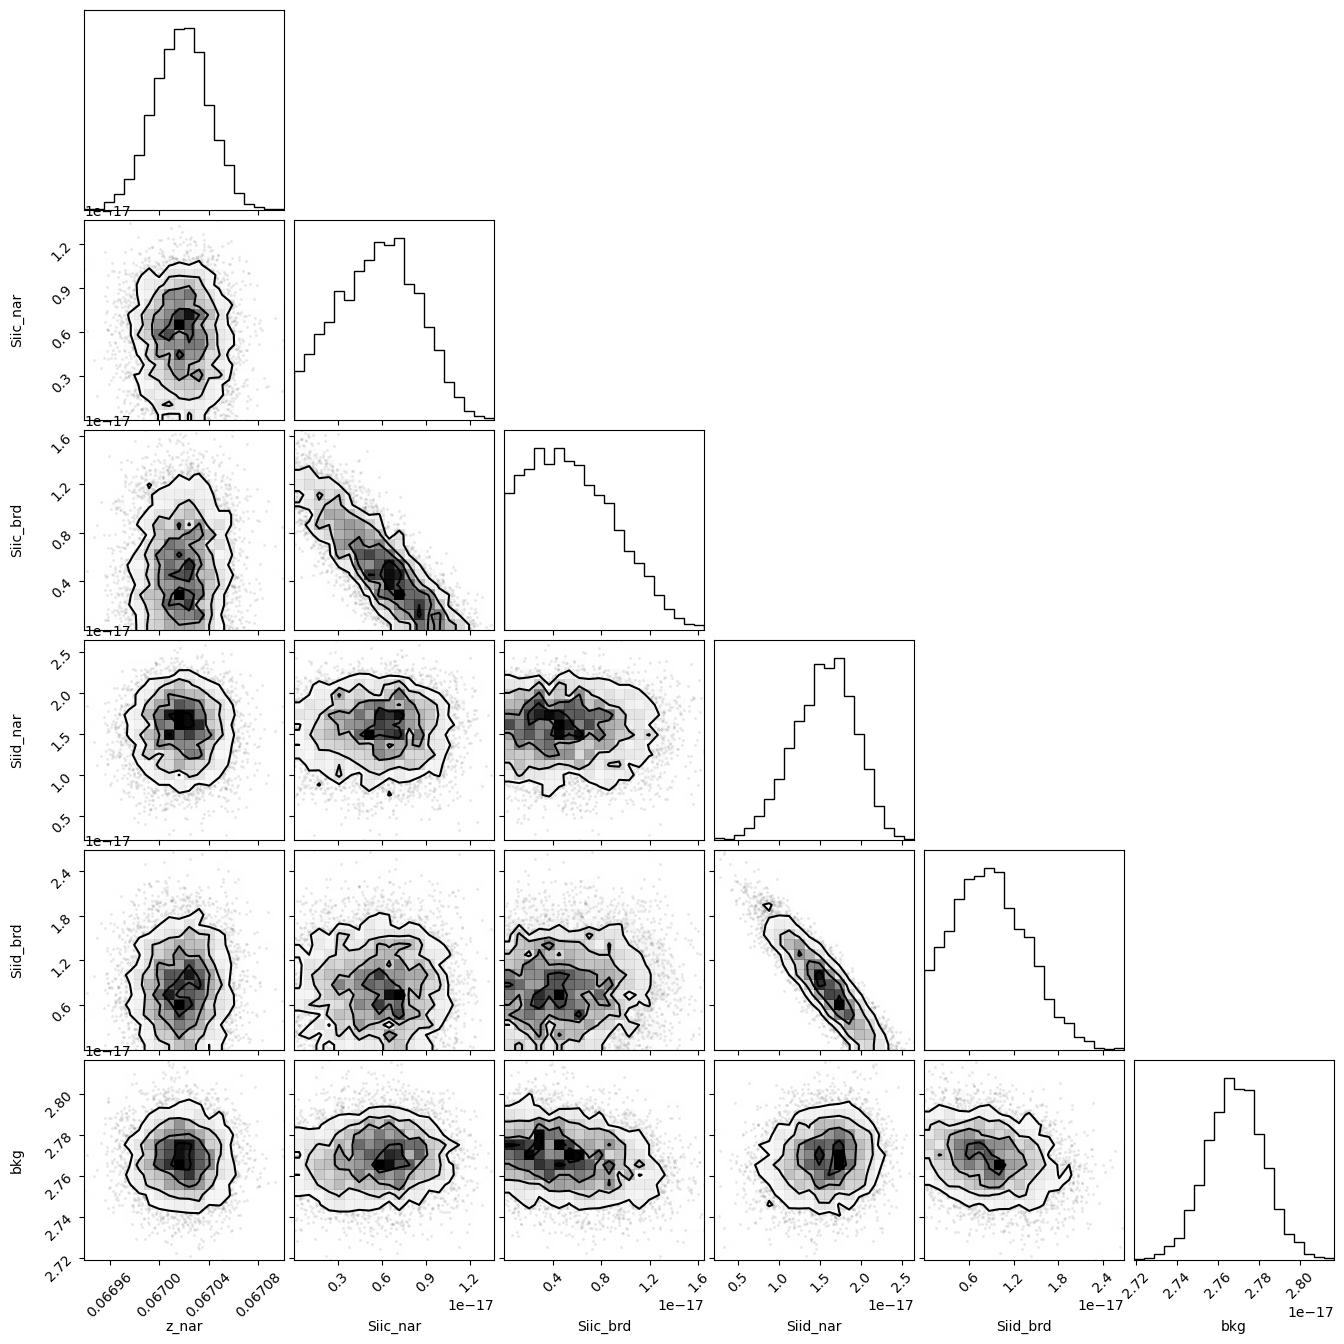

In [63]:
corner.corner(out_sii2.flatchain, labels=out_sii2.var_names);

In [64]:
out_sii2

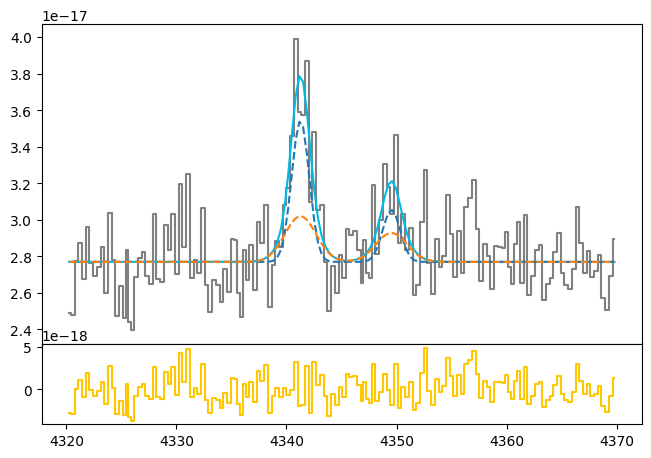

In [65]:
siic_nar_flux = out_sii2.flatchain.Siic_nar.mean()
siic_nar_std = out_sii2.flatchain.Siic_nar.std()

siic_brd_flux = out_sii2.flatchain.Siic_brd.mean()
siic_brd_std = out_sii2.flatchain.Siic_brd.std()

siid_nar_flux = out_sii2.flatchain.Siid_nar.mean()
siid_nar_std = out_sii2.flatchain.Siid_nar.std()

siid_brd_flux = out_sii2.flatchain.Siid_brd.mean()
siid_brd_std = out_sii2.flatchain.Siid_brd.std()

z_sii2 = out_sii2.flatchain.z_nar.mean()
z_sii2_std = out_sii2.flatchain.z_nar.std()

bkg_sii2 = out_sii2.flatchain.bkg.mean()
bkg_sii2_std = out_sii2.flatchain.bkg.std()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(sii2.wavelength, sii2.flux, color='gray', label='Data', where='mid')

siic_nar = gaussian(sii2.wavelength, siic_nar_flux, wave_cat['[SII]4076'], z_sii2, sigma_nar_oiii_4959)
siid_nar = gaussian(sii2.wavelength, siid_nar_flux, wave_cat['[SII]4068'], z_sii2, sigma_nar_oiii_4959)

siic_brd = gaussian(sii2.wavelength, siic_brd_flux, wave_cat['[SII]4076'], z_sii2 * z_ratio, sigma_brd_oiii_4959)
siid_brd = gaussian(sii2.wavelength, siid_brd_flux, wave_cat['[SII]4068'], z_sii2 * z_ratio, sigma_brd_oiii_4959)

siic = siic_nar + siic_brd
siid = siid_nar + siid_brd

ax.plot(sii2.wavelength, bkg_sii2 + siic + siid, color=c[0])
ax.plot(sii2.wavelength, bkg_sii2 + siic_nar + siid_nar, ls='--')
ax.plot(sii2.wavelength, bkg_sii2 + siic_brd + siid_brd, ls='--')
#plt.yscale('log')
ax1.step(sii2.wavelength, sii2.flux - bkg_sii2 - siic - siid, color=c[3], where='mid')

#ls_siid = (wave_cat['[SII]4068'] * (1 + z_sii2)) + (3 * sigma_brd_oiii_4959)
#li_siid = (wave_cat['[SII]4068'] * (1 + z_sii2)) - (3 * sigma_brd_oiii_4959)

#ls_siic = (wave_cat['[SII]4076'] * (1 + z_sii2)) + (3 * sigma_brd_oiii_4959)
#li_siic = (wave_cat['[SII]4076'] * (1 + z_sii2)) - (3 * sigma_brd_oiii_4959)

#ax.axvline(ls_siid, ls='--', color='gray', lw=0.8)
#ax.axvline(li_siid, ls='--', color='gray', lw=0.8)

#ax.axvline(ls_siic, ls='--', color='gray', lw=0.8)
#ax.axvline(li_siic, ls='--', color='gray', lw=0.8)

In [66]:
# EW
EW_SII_4076_nar = ufloat(siic_nar_flux, siic_nar_std) / ufloat(bkg_sii2, bkg_sii2_std)
EW_SII_4076_brd = ufloat(siic_brd_flux, siic_brd_std) / ufloat(bkg_sii2, bkg_sii2_std)
EW_SII_4076 = (ufloat(siic_nar_flux, siic_nar_std) + ufloat(siic_brd_flux, siic_brd_std)) / ufloat(bkg_sii2, bkg_sii2_std)

EW_SII_4068_nar = ufloat(siid_nar_flux, siid_nar_std) / ufloat(bkg_sii2, bkg_sii2_std)
EW_SII_4068_brd = ufloat(siid_brd_flux, siid_brd_std) / ufloat(bkg_sii2, bkg_sii2_std)
EW_SII_4068 = (ufloat(siid_nar_flux, siid_nar_std) + ufloat(siid_brd_flux, siid_brd_std)) / ufloat(bkg_sii2, bkg_sii2_std)

mask_siid = (sii2.wavelength >= li_siid) & (sii2.wavelength < ls_siid)
mask_siic = (sii2.wavelength >= li_siic) & (sii2.wavelength < ls_siic)

c_mask_sii2 = (sii2.wavelength > ls_siic) + (sii2.wavelength < li_siid)

N_siid = len(sii2.wavelength[mask_siid])
N_siic = len(sii2.wavelength[mask_siic])

sigmac_sii2 = np.std(sii2.flux[c_mask_sii2])

# Uncertainties added

sigmal_siid_nar = sigmac_sii2 * np.sqrt(N_siid + (EW_SII_4068_nar.nominal_value/dLam))
sigmal_siid_brd = sigmac_sii2 * np.sqrt(N_siid + (EW_SII_4068_brd.nominal_value/dLam))

sigmal_siic_nar = sigmac_sii2 * np.sqrt(N_siic + (EW_SII_4076_nar.nominal_value/dLam))
sigmal_siic_brd = sigmac_sii2 * np.sqrt(N_siic + (EW_SII_4076_brd.nominal_value/dLam))

print('Previous nar error (Siid)', siid_nar_std)
print('Previous brd error (Siid)', siid_brd_std)

print('Previous nar error (Siic)', siic_nar_std)
print('Previous brd error (Siic)', siic_brd_std)

# Final uncertainties
siid_nar_std = np.sqrt((siid_nar_std**2) + (sigmal_siid_nar**2))
siid_brd_std = np.sqrt((siid_brd_std**2) + (sigmal_siid_brd**2))

siic_nar_std = np.sqrt((siic_nar_std**2) + (sigmal_siic_nar**2))
siic_brd_std = np.sqrt((siic_brd_std**2) + (sigmal_siic_brd**2))

print('New nar error (Siid)', siid_nar_std)
print('New brd error (Siid)', siid_brd_std)

print('New nar error (Siic)', siic_nar_std)
print('New brd error (Siic)', siic_brd_std)

## [OII]3726 + [OII]3729

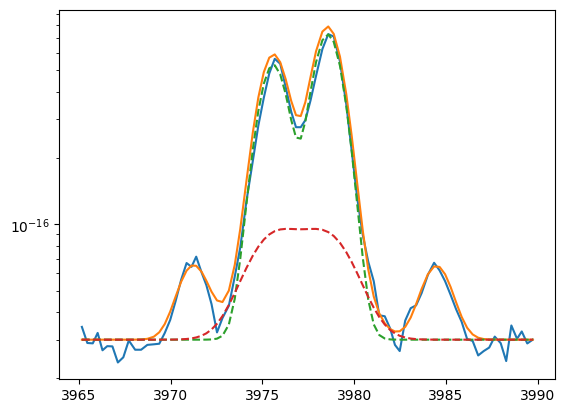

In [67]:
# Search for good initial guess

plt.plot(oii_3727.wavelength, oii_3727.flux)

h13 = gaussian(oii_3727.wavelength, 0.7e-16, wave_cat['H13'], z=z_nar_oiii_4959, sigma=sigma_nar_oiii_4959)

oiic_nar = gaussian(oii_3727.wavelength, 1.4e-15, wave_cat['[OII]3729'], z=z_nar_oiii_4959, sigma=sigma_nar_oiii_4959)
oiic_brd = gaussian(oii_3727.wavelength, 2.0e-16, wave_cat['[OII]3729'], z=z_brd_oiii_4959, sigma=sigma_brd_oiii_4959)

oiid_nar = gaussian(oii_3727.wavelength, 1.0e-15, wave_cat['[OII]3726'], z=z_nar_oiii_4959, sigma=sigma_nar_oiii_4959)
oiid_brd = gaussian(oii_3727.wavelength, 2.0e-16, wave_cat['[OII]3726'], z=z_brd_oiii_4959, sigma=sigma_brd_oiii_4959)

h14 = gaussian(oii_3727.wavelength, 0.7e-16, wave_cat['H14'], z=z_nar_oiii_4959, sigma=sigma_nar_oiii_4959)

oiic = oiic_nar + oiic_brd
oiid = oiid_nar + oiid_brd

bkg = 3e-17

plt.plot(oii_3727.wavelength, bkg + oiid + oiic + h13 + h14)
plt.plot(oii_3727.wavelength, bkg + oiid_nar + oiic_nar, ls='--')
plt.plot(oii_3727.wavelength, bkg + oiid_brd + oiic_brd, ls='--')

plt.yscale('log')

In [68]:
params_oii_3727 = Parameters()

params_oii_3727.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_oii_3727.add('z_ratio', value=z_ratio, vary=False)
params_oii_3727.add('sigma_nar', value=sigma_nar_oiii_4959, vary=False)
params_oii_3727.add('sigma_brd', value=sigma_brd_oiii_4959, vary=False)
params_oii_3727.add('H13', value=0.7e-16, min=0.)
params_oii_3727.add('Oiic_nar', value=1.4e-15, min=0.)
params_oii_3727.add('Oiic_brd', value=2.0e-16, min=0.)
params_oii_3727.add('Oiid_nar', value=1.0e-15, min=0.)
params_oii_3727.add('Oiid_brd', value=2.0e-16, min=0.)
params_oii_3727.add('H14', value=0.7e-16, min=0.)
params_oii_3727.add('bkg', value=3e-17, min=0.)

def residual_oii_3727(params_oii_3727, x, data, uncertainty):
    
    z_nar = params_oii_3727['z_nar']
    z_brd = params_oii_3727['z_nar'] * params_oii_3727['z_ratio']
    sigma_nar = params_oii_3727['sigma_nar']
    sigma_brd = params_oii_3727['sigma_brd']
    
    h13_flux = params_oii_3727['H13']
    oiic_nar_flux = params_oii_3727['Oiic_nar']
    oiic_brd_flux = params_oii_3727['Oiic_brd']
    oiid_nar_flux = params_oii_3727['Oiid_nar']
    oiid_brd_flux = params_oii_3727['Oiid_brd']
    h14_flux = params_oii_3727['H14']
    bkg = params_oii_3727['bkg']
    
    x = oii_3727.wavelength
    model_h13 = gaussian(x, h13_flux, wave_cat['H13'], z_nar, sigma_nar)
    model_oiic = gaussian(x, oiic_nar_flux, wave_cat['[OII]3729'], z_nar, sigma_nar) + \
                 gaussian(x, oiic_brd_flux, wave_cat['[OII]3729'], z_brd, sigma_brd)
    model_oiid = gaussian(x, oiid_nar_flux, wave_cat['[OII]3726'], z_nar, sigma_nar) + \
                 gaussian(x, oiid_brd_flux, wave_cat['[OII]3726'], z_brd, sigma_brd)
    model_h14 = gaussian(x, h14_flux, wave_cat['H14'], z_nar, sigma_nar)
    model = model_h13 + model_oiic + model_oiid + model_h14
    return (model + bkg - oii_3727.flux) / oii_3727.noise

In [69]:
np.random.seed(2225)
out_oii_3727 = minimize(residual_oii_3727, params_oii_3727, args=(1, 1, 1),
                         method='emcee', burn=1000, steps=2500, thin=10)

100%|███████████████████████████████████████| 2500/2500 [00:30<00:00, 80.78it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 7 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 54.57696973  66.12128062  57.53412074 116.83971909  45.14348909
 123.16583616  97.76823321  53.72937364]


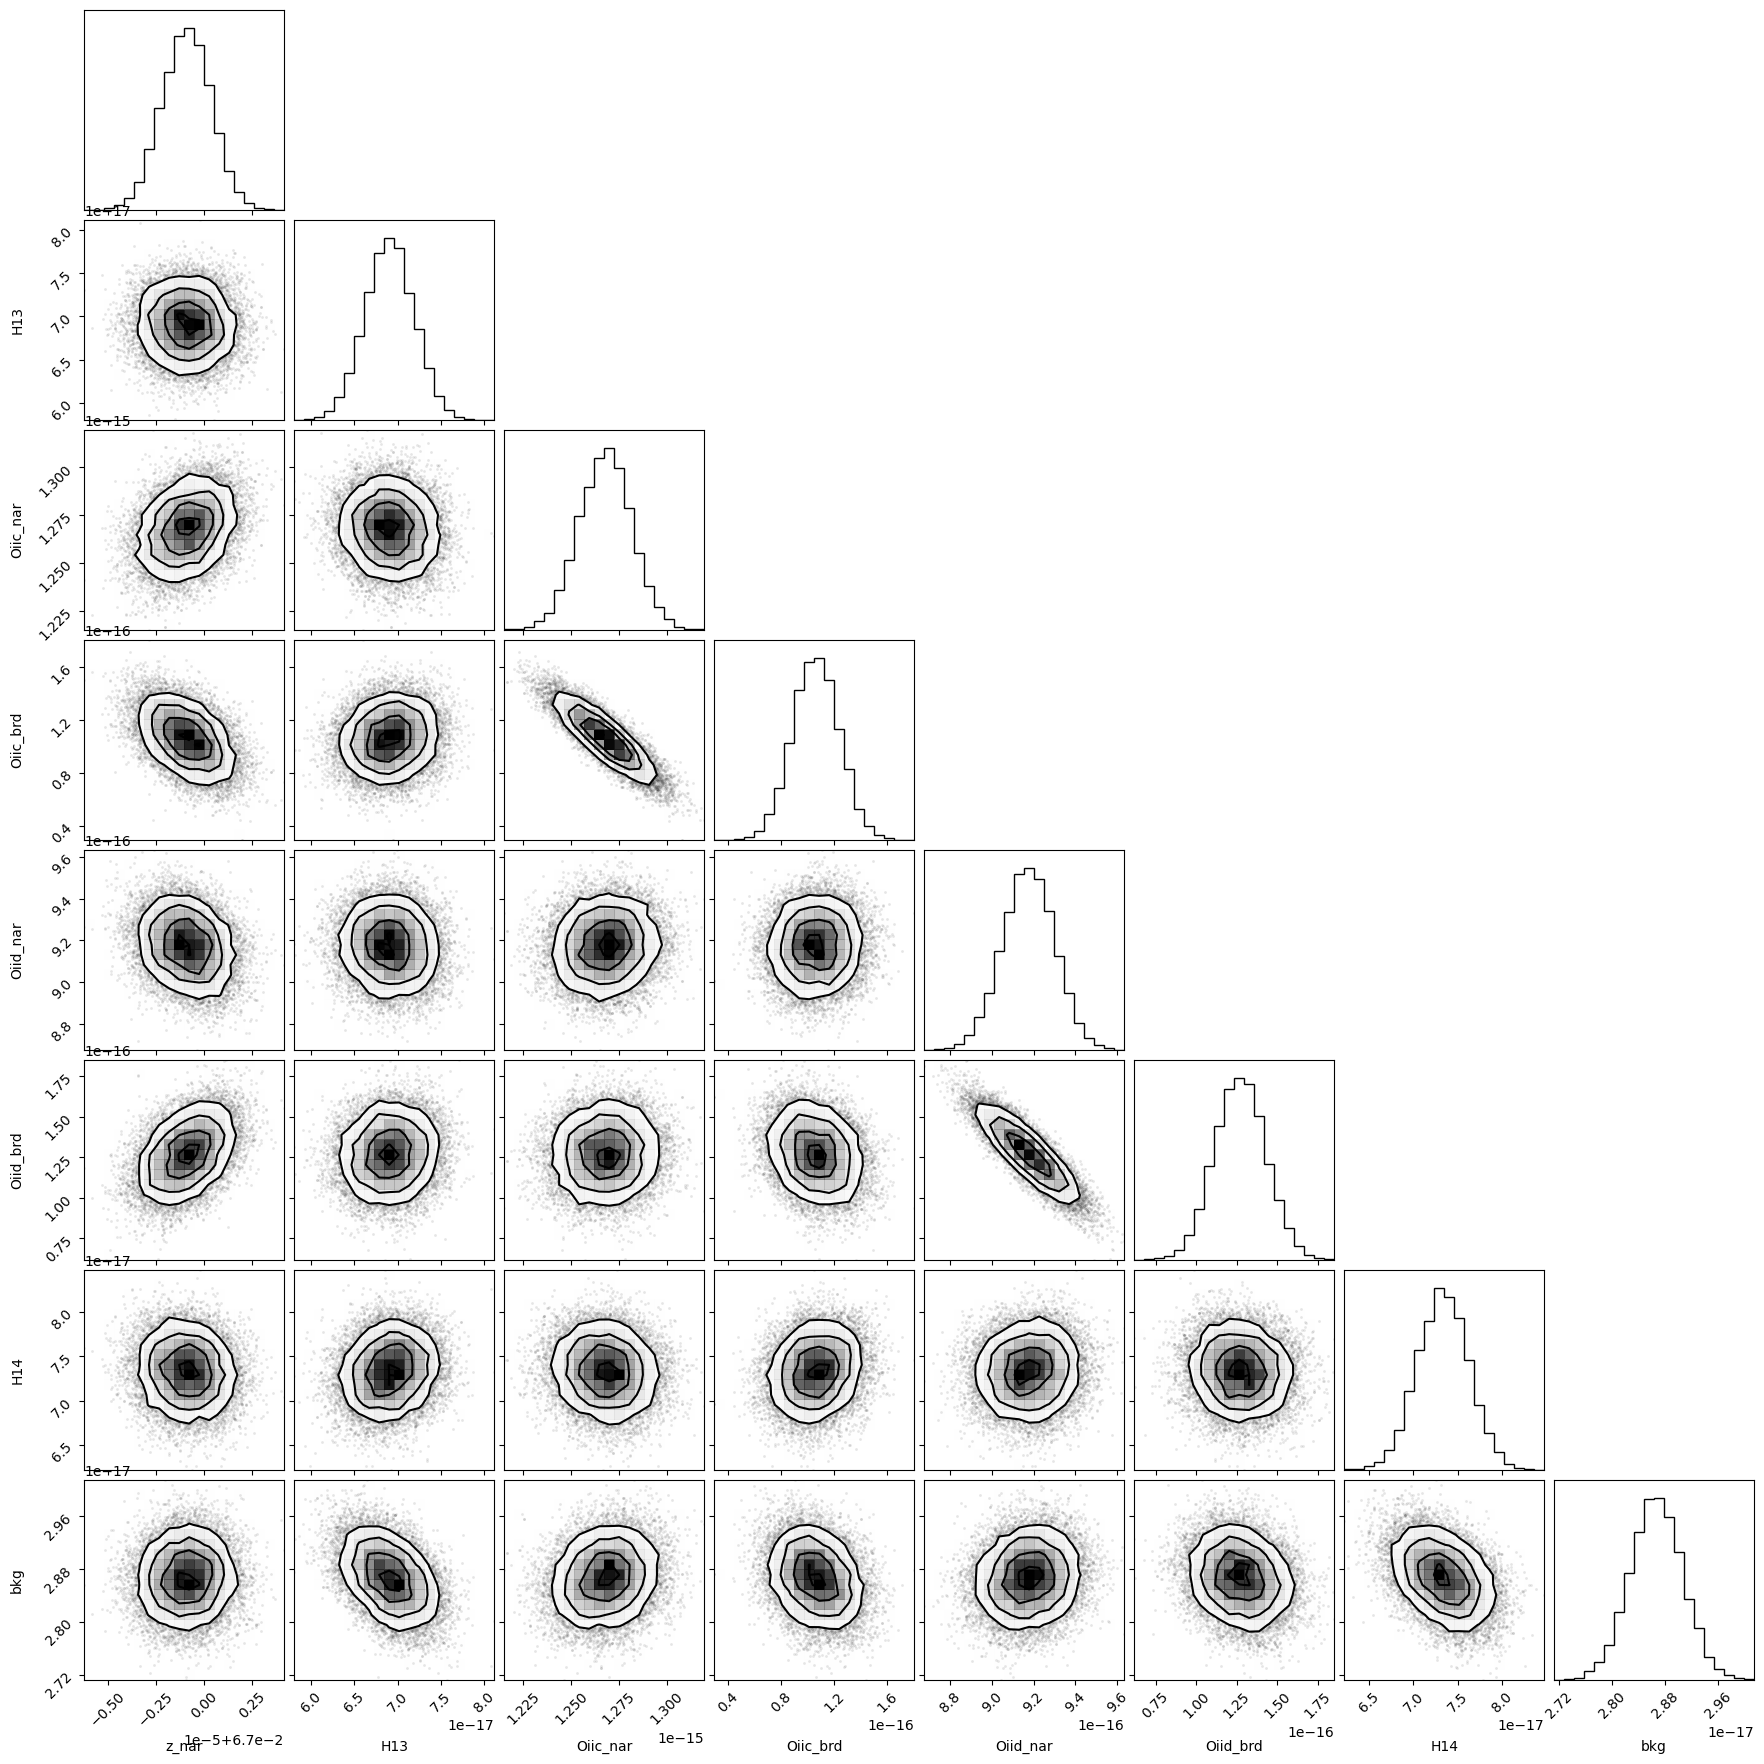

In [70]:
corner.corner(out_oii_3727.flatchain, labels=out_oii_3727.var_names);

In [71]:
out_oii_3727

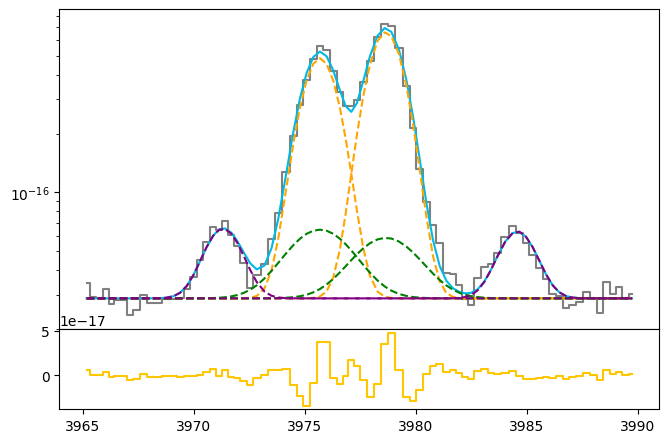

In [72]:
h13_flux = out_oii_3727.flatchain.H13.mean()
h13_std = out_oii_3727.flatchain.H13.std()

oiic_nar_flux = out_oii_3727.flatchain.Oiic_nar.mean()
oiic_nar_std = out_oii_3727.flatchain.Oiic_nar.std()

oiic_brd_flux = out_oii_3727.flatchain.Oiic_brd.mean()
oiic_brd_std = out_oii_3727.flatchain.Oiic_brd.std()

oiid_nar_flux = out_oii_3727.flatchain.Oiid_nar.mean()
oiid_nar_std = out_oii_3727.flatchain.Oiid_nar.std()

oiid_brd_flux = out_oii_3727.flatchain.Oiid_brd.mean()
oiid_brd_std = out_oii_3727.flatchain.Oiid_brd.std()

h14_flux = out_oii_3727.flatchain.H14.mean()
h14_std = out_oii_3727.flatchain.H14.std()

z_oii_3727 = out_oii_3727.flatchain.z_nar.mean()
z_oii_3727_std = out_oii_3727.flatchain.z_nar.std()

bkg_oii_3727 = out_oii_3727.flatchain.bkg.mean()
bkg_oii_3727_std = out_oii_3727.flatchain.bkg.std()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(oii_3727.wavelength, oii_3727.flux, color='gray', label='Data', where='mid')

h13 = gaussian(oii_3727.wavelength, h13_flux, wave_cat['H13'], z_oii_3727, sigma_nar_oiii_4959)

oiic_nar = gaussian(oii_3727.wavelength, oiic_nar_flux, wave_cat['[OII]3729'], z_oii_3727, sigma_nar_oiii_4959)
oiic_brd = gaussian(oii_3727.wavelength, oiic_brd_flux, wave_cat['[OII]3729'], z_oii_3727 * z_ratio, sigma_brd_oiii_4959)

oiid_nar = gaussian(oii_3727.wavelength, oiid_nar_flux, wave_cat['[OII]3726'], z_oii_3727, sigma_nar_oiii_4959)
oiid_brd = gaussian(oii_3727.wavelength, oiid_brd_flux, wave_cat['[OII]3726'], z_oii_3727 * z_ratio, sigma_brd_oiii_4959)

h14 = gaussian(oii_3727.wavelength, h14_flux, wave_cat['H14'], z_oii_3727, sigma_nar_oiii_4959)

oiic = oiic_nar + oiic_brd
oiid = oiid_nar + oiid_brd

ax.plot(oii_3727.wavelength, bkg_oii_3727 + h13 + oiic + oiid + h14, color=c[0])
ax.plot(oii_3727.wavelength, bkg_oii_3727 + oiic_nar, ls='--', color='orange')
ax.plot(oii_3727.wavelength, bkg_oii_3727 + oiid_nar, ls='--', color='orange')
ax.plot(oii_3727.wavelength, bkg_oii_3727 + oiic_brd, ls='--', color='green')
ax.plot(oii_3727.wavelength, bkg_oii_3727 + oiid_brd, ls='--', color='green')
ax.plot(oii_3727.wavelength, bkg_oii_3727 + h13, ls='--', color='purple')
ax.plot(oii_3727.wavelength, bkg_oii_3727 + h14, ls='--', color='purple')

ax.set_yscale('log')
ax1.step(oii_3727.wavelength, oii_3727.flux - bkg_oii_3727 - oiic - oiid - h13 - h14, color=c[3], where='mid')

#ls_oiid = (wave_cat['[OII]3726'] * (1 + z_oii_3727)) + (3 * sigma_brd_oiii_4959)
#li_oiid = (wave_cat['[OII]3726'] * (1 + z_oii_3727)) - (3 * sigma_brd_oiii_4959)

#ls_oiic = (wave_cat['[OII]3729'] * (1 + z_oii_3727)) + (3 * sigma_brd_oiii_4959)
#li_oiic = (wave_cat['[OII]3729'] * (1 + z_oii_3727)) - (3 * sigma_brd_oiii_4959)

#ax.axvline(ls_oiid, ls='--', color='gray', lw=0.8)
#ax.axvline(li_oiid, ls='--', color='gray', lw=0.8)

#ax.axvline(ls_oiic, ls='--', color='gray', lw=0.8)
#ax.axvline(li_oiic, ls='--', color='gray', lw=0.8)

In [73]:
# EW
EW_OII_3729_nar = ufloat(oiic_nar_flux, oiic_nar_std) / ufloat(bkg_oii_3727, bkg_oii_3727_std)
EW_OII_3729_brd = ufloat(oiic_brd_flux, oiic_brd_std) / ufloat(bkg_oii_3727, bkg_oii_3727_std)
EW_OII_3729 = (ufloat(oiic_nar_flux, oiic_nar_std) + ufloat(oiic_brd_flux, oiic_brd_std)) / ufloat(bkg_oii_3727, bkg_oii_3727_std)

EW_OII_3726_nar = ufloat(oiid_nar_flux, oiid_nar_std) / ufloat(bkg_oii_3727, bkg_oii_3727_std)
EW_OII_3726_brd = ufloat(oiid_brd_flux, oiid_brd_std) / ufloat(bkg_oii_3727, bkg_oii_3727_std)
EW_OII_3726 = (ufloat(oiid_nar_flux, oiid_nar_std) + ufloat(oiid_brd_flux, oiid_brd_std)) / ufloat(bkg_oii_3727, bkg_oii_3727_std)

mask_oiid = (oii_3727.wavelength >= li_oiid) & (oii_3727.wavelength < ls_oiid)
mask_oiic = (oii_3727.wavelength >= li_oiic) & (oii_3727.wavelength < ls_oiic)

c_mask_oii_3727 = (oii_3727.wavelength > ls_oiic) + (oii_3727.wavelength < li_oiid)

N_oiid = len(oii_3727.wavelength[mask_oiid])
N_oiic = len(oii_3727.wavelength[mask_oiic])

sigmac_oii_3727 = np.std(oii_3727.flux[c_mask_oii_3727])

# Uncertainties added

sigmal_oiid_nar = sigmac_oii_3727 * np.sqrt(N_oiid + (EW_OII_3726_nar.nominal_value/dLam))
sigmal_oiid_brd = sigmac_oii_3727 * np.sqrt(N_oiid + (EW_OII_3726_brd.nominal_value/dLam))

sigmal_oiic_nar = sigmac_oii_3727 * np.sqrt(N_oiic + (EW_OII_3729_nar.nominal_value/dLam))
sigmal_oiic_brd = sigmac_oii_3727 * np.sqrt(N_oiic + (EW_OII_3729_brd.nominal_value/dLam))

print('Previous nar error (Oiid)', oiid_nar_std)
print('Previous brd error (Oiid)', oiid_brd_std)

print('Previous nar error (Oiic)', oiic_nar_std)
print('Previous brd error (Oiic)', oiic_brd_std)

# Final uncertainties
oiid_nar_std = np.sqrt((oiid_nar_std**2) + (sigmal_oiid_nar**2))
oiid_brd_std = np.sqrt((oiid_brd_std**2) + (sigmal_oiid_brd**2))

oiic_nar_std = np.sqrt((oiic_nar_std**2) + (sigmal_oiic_nar**2))
oiic_brd_std = np.sqrt((oiic_brd_std**2) + (sigmal_oiic_brd**2))

print('New nar error (Oiid)', oiid_nar_std)
print('New brd error (Oiid)', oiid_brd_std)

print('New nar error (Oiic)', oiic_nar_std)
print('New brd error (Oiic)', oiic_brd_std)

----

# High ionization

## [SIII]9532

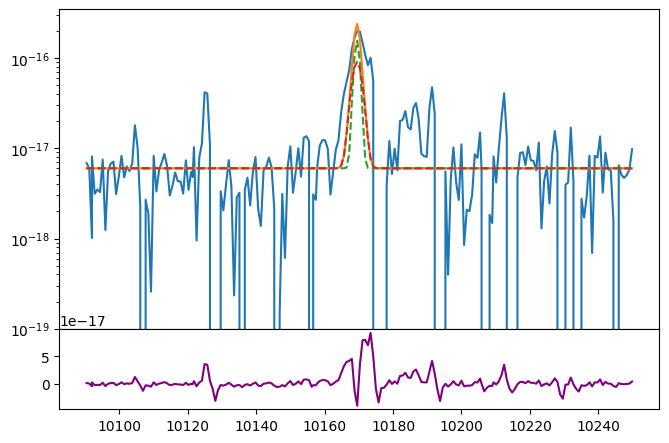

In [74]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(siii_9532.wavelength, siii_9532.flux)
bkg = 6e-18

siiia_nar = gaussian(siii_9532.wavelength, 0.3e-15, wave_cat['[SIII]9532'], z=z_nar_oiii_4959, sigma=sigma_nar_oiii_4959)
siiia_brd = gaussian(siii_9532.wavelength, 0.3e-15, wave_cat['[SIII]9532'], z=z_brd_oiii_4959, sigma=sigma_brd_oiii_4959)

ax.plot(siii_9532.wavelength, bkg + siiia_nar + siiia_brd)
ax.plot(siii_9532.wavelength, bkg + siiia_nar, ls='--')
ax.plot(siii_9532.wavelength, bkg + siiia_brd, ls='--')
ax1.plot(siii_9532.wavelength, siii_9532.flux - bkg - siiia_nar - siiia_brd, color='purple')
ax.set_yscale('log')

In [75]:
params_siiia = Parameters()
params_siiia.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_siiia.add('z_ratio', value=z_ratio, vary=False)
params_siiia.add('sigma_nar', value=sigma_nar_oiii_4959, vary=False)
params_siiia.add('sigma_brd', value=sigma_brd_oiii_4959, vary=False)
params_siiia.add('Siiia_nar', value=0.3e-15, min=0.)
params_siiia.add('Siiia_brd', value=0.3e-15, min=0.)
params_siiia.add('bkg', value=6e-18, min=0.)


def residual_siiia(params_siiia, x, data, uncertainty):
    
    z_nar = params_siiia['z_nar']
    z_brd = params_siiia['z_nar'] * params_siiia['z_ratio']
    sigma_nar = params_siiia['sigma_nar']
    sigma_brd = params_siiia['sigma_brd']
    siiia_nar_flux = params_siiia['Siiia_nar']
    siiia_brd_flux = params_siiia['Siiia_brd']
    bkg = params_siiia['bkg']
    
    x = siii_9532.wavelength
    model = gaussian(x, siiia_nar_flux, wave_cat['[SIII]9532'], z_nar, sigma_nar) + \
            gaussian(x, siiia_brd_flux, wave_cat['[SIII]9532'], z_brd, sigma_brd)
    
    return (model + bkg - siii_9532.flux) / siii_9532.noise

In [76]:
np.random.seed(2225)
out_siiia = minimize(residual_siiia, params_siiia, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

100%|██████████████████████████████████████| 2500/2500 [00:19<00:00, 131.08it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 2 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [36.35556568 99.43583867 99.80072222 44.67726568]


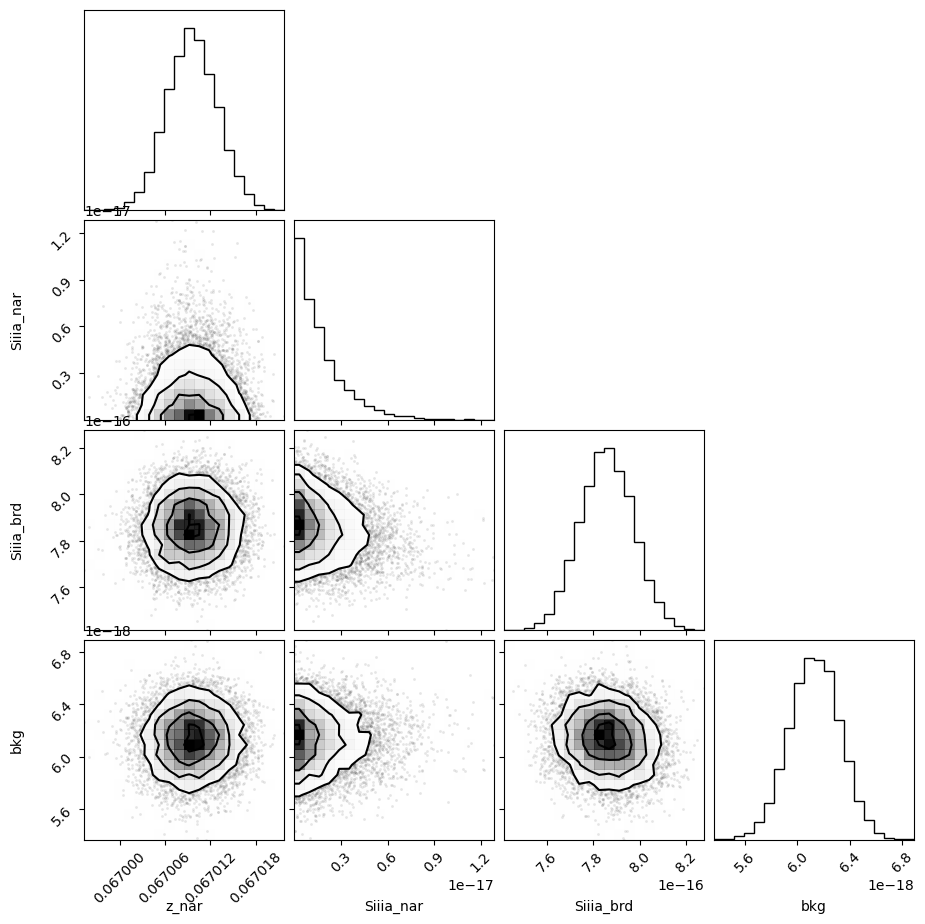

In [77]:
corner.corner(out_siiia.flatchain, labels=out_siiia.var_names);
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

In [78]:
out_siiia

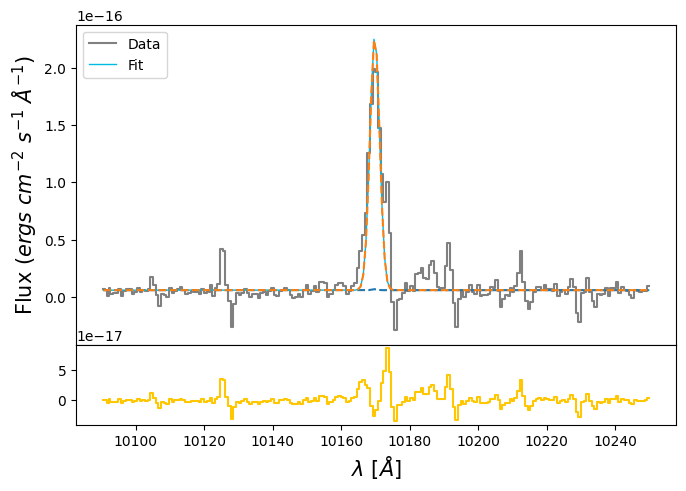

In [79]:
siiia_nar_flux = out_siiia.flatchain.Siiia_nar.mean()
siiia_nar_std = out_siiia.flatchain.Siiia_nar.std()

siiia_brd_flux = out_siiia.flatchain.Siiia_brd.mean()
siiia_brd_std = out_siiia.flatchain.Siiia_brd.std()

z_siiia = out_siiia.flatchain.z_nar.mean()
z_siiia_std = out_siiia.flatchain.z_nar.std()

bkg_siiia = out_siiia.flatchain.bkg.mean()
bkg_siiia_std = out_siiia.flatchain.bkg.std()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(siii_9532.wavelength, siii_9532.flux,
            color='gray', label='Data', where='mid')

siiia_nar = gaussian(siii_9532.wavelength, siiia_nar_flux, wave_cat['[SIII]9532'], z_siiia, sigma_nar_oiii_4959)
siiia_brd = gaussian(siii_9532.wavelength, siiia_brd_flux, wave_cat['[SIII]9532'], z_siiia * z_ratio, sigma_brd_oiii_4959)
siiia = siiia_nar + siiia_brd

ax.plot(siii_9532.wavelength, bkg_siiia + siiia, lw=1, color=c[0], label='Fit')
ax.plot(siii_9532.wavelength, bkg_siiia + siiia_nar, ls='--')
ax.plot(siii_9532.wavelength, bkg_siiia + siiia_brd, ls='--')
ax1.step(siii_9532.wavelength, siii_9532.flux - bkg_siiia - siiia, color=c[3], where='mid')
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
#ax.set_yscale('log')
ax.legend(loc='upper left')
#plt.savefig(fname='ha_nii.svg', bbox_inches='tight')

#ls_9532 = (wave_cat['[SIII]9532'] * (1 + z_siiia)) + (5 * sigma_brd_oiii_4959)
#li_9532 = (wave_cat['[SIII]9532'] * (1 + z_siiia)) - (5 * sigma_brd_oiii_4959)

#ax.axvline(ls_9532, ls='--', color='gray', lw=0.8)
#ax.axvline(li_9532, ls='--', color='gray', lw=0.8)

In [80]:
# EW
EW_SIII_9532_nar = (ufloat(siiia_nar_flux, siiia_nar_std) + ufloat(siiia_brd_flux, siiia_brd_std)) / ufloat(bkg_siiia, bkg_siiia_std)
EW_SIII_9532_brd = (ufloat(siiia_nar_flux, siiia_nar_std) + ufloat(siiia_brd_flux, siiia_brd_std)) / ufloat(bkg_siiia, bkg_siiia_std)
EW_SIII_9532 = (ufloat(siiia_nar_flux, siiia_nar_std) + ufloat(siiia_brd_flux, siiia_brd_std)) / ufloat(bkg_siiia, bkg_siiia_std)

mask_9532 = (siii_9532.wavelength >= li_9532) & (siii_9532.wavelength < ls_9532)
N_9532 = len(siii_9532.wavelength[mask_9532])
sigmac_9532 = np.std(siii_9532.flux[np.logical_not(mask_9532)])

# Uncertainties added
sigmal_9532_nar = sigmac_9532 * np.sqrt(N_9532 + (EW_SIII_9532_nar.nominal_value/dLam))
sigmal_9532_brd = sigmac_9532 * np.sqrt(N_9532 + (EW_SIII_9532_brd.nominal_value/dLam))

print('Previous narrow error:', siiia_nar_std)
print('Previous broad error:', siiia_brd_std)

# Final uncertainties
siiia_nar_std = np.sqrt(siiia_nar_std**2 + sigmal_9532_nar**2)
siiia_brd_std = np.sqrt(siiia_brd_std**2 + sigmal_9532_brd**2)

print('New narrow error:', siiia_nar_std)
print('New broad error:', siiia_brd_std)

## [SIII]9069

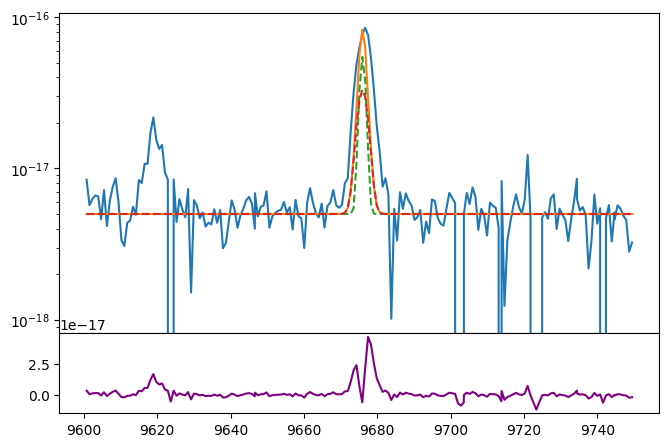

In [81]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(siii_9069.wavelength, siii_9069.flux)
bkg = 5e-18

siiib_nar = gaussian(siii_9069.wavelength, 1e-16, wave_cat['[SIII]9069'], z=z_nar_oiii_4959, sigma=sigma_nar_oiii_4959)
siiib_brd = gaussian(siii_9069.wavelength, 1e-16, wave_cat['[SIII]9069'], z=z_brd_oiii_4959, sigma=sigma_brd_oiii_4959)

ax.plot(siii_9069.wavelength, bkg + siiib_nar + siiib_brd)
ax.plot(siii_9069.wavelength, bkg + siiib_nar, ls='--')
ax.plot(siii_9069.wavelength, bkg + siiib_brd, ls='--')
ax1.plot(siii_9069.wavelength, siii_9069.flux - bkg - siiib_nar - siiib_brd, color='purple')
ax.set_yscale('log')

In [82]:
params_siiib = Parameters()
params_siiib.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_siiib.add('z_ratio', value=z_ratio, vary=False)
params_siiib.add('sigma_nar', value=sigma_nar_oiii_4959, vary=False)
params_siiib.add('sigma_brd', value=sigma_brd_oiii_4959, vary=False)
params_siiib.add('Siiib_nar', value=1.0e-16, min=0.)
params_siiib.add('Siiib_brd', value=1.0e-16, min=0.)
params_siiib.add('bkg', value=5e-18, min=0.)


def residual_siiib(params_siiib, x, data, uncertainty):
    
    z_nar = params_siiib['z_nar']
    z_brd = params_siiib['z_nar'] * params_siiib['z_ratio']
    sigma_nar = params_siiib['sigma_nar']
    sigma_brd = params_siiib['sigma_brd']
    siiib_nar_flux = params_siiib['Siiib_nar']
    siiib_brd_flux = params_siiib['Siiib_brd']
    bkg = params_siiib['bkg']
    
    x = siii_9069.wavelength
    model = gaussian(x, siiib_nar_flux, wave_cat['[SIII]9069'], z_nar, sigma_nar) + \
            gaussian(x, siiib_brd_flux, wave_cat['[SIII]9069'], z_brd, sigma_brd)
    
    return (model + bkg - siii_9069.flux) / siii_9069.noise

In [83]:
np.random.seed(2225)
out_siiib = minimize(residual_siiib, params_siiib, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

100%|██████████████████████████████████████| 2500/2500 [00:18<00:00, 132.29it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 3 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 25.52126096 107.29507922 104.8383151   62.19995638]


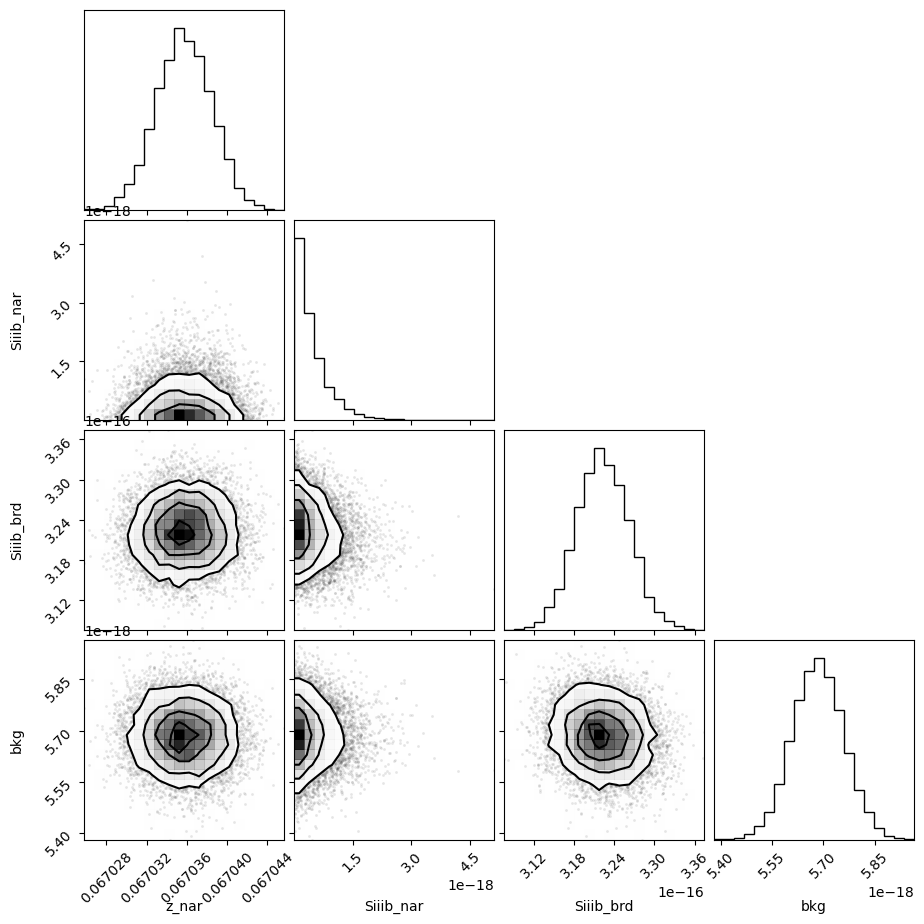

In [84]:
corner.corner(out_siiib.flatchain, labels=out_siiib.var_names);
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

In [85]:
out_siiib

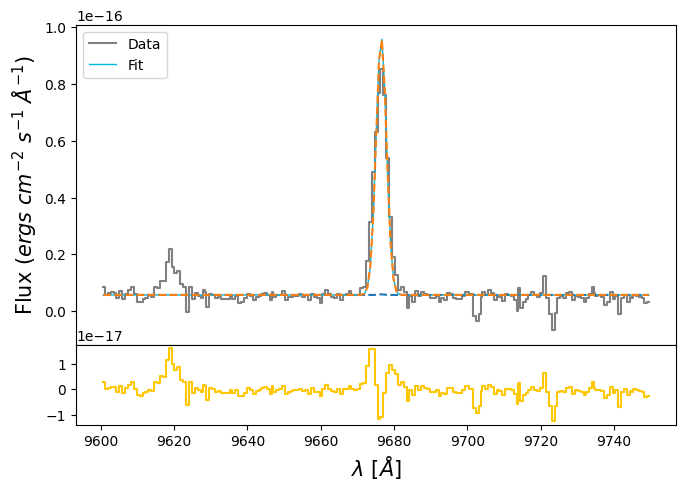

In [87]:
siiib_nar_flux = out_siiib.flatchain.Siiib_nar.mean()
siiib_nar_std = out_siiib.flatchain.Siiib_nar.std()

siiib_brd_flux = out_siiib.flatchain.Siiib_brd.mean()
siiib_brd_std = out_siiib.flatchain.Siiib_brd.std()

z_siiib = out_siiib.flatchain.z_nar.mean()
z_siiib_std = out_siiib.flatchain.z_nar.std()

bkg_siiib = out_siiib.flatchain.bkg.mean()
bkg_siiib_std = out_siiib.flatchain.bkg.std()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(siii_9069.wavelength, siii_9069.flux,
            color='gray', label='Data', where='mid')

siiib_nar = gaussian(siii_9069.wavelength, siiib_nar_flux, wave_cat['[SIII]9069'], z_siiib, sigma_nar_oiii_4959)
siiib_brd = gaussian(siii_9069.wavelength, siiib_brd_flux, wave_cat['[SIII]9069'], z_siiib * z_ratio, sigma_brd_oiii_4959)
siiib = siiib_nar + siiib_brd

ax.plot(siii_9069.wavelength, bkg_siiib + siiib, lw=1, color=c[0], label='Fit')
ax.plot(siii_9069.wavelength, bkg_siiib + siiib_nar, ls='--')
ax.plot(siii_9069.wavelength, bkg_siiib + siiib_brd, ls='--')
ax1.step(siii_9069.wavelength, siii_9069.flux - bkg_siiib - siiib, color=c[3], where='mid')
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
#ax.set_yscale('log')
ax.legend(loc='upper left')
#plt.savefig(fname='ha_nii.svg', bbox_inches='tight')

#ls_9069 = (wave_cat['[SIII]9069'] * (1 + z_siiib)) + (5 * sigma_brd_oiii_4959)
#li_9069 = (wave_cat['[SIII]9069'] * (1 + z_siiib)) - (5 * sigma_brd_oiii_4959)

#ax.axvline(ls_9069, ls='--', color='gray', lw=0.8)
#ax.axvline(li_9069, ls='--', color='gray', lw=0.8)

In [88]:
# EW
EW_SIII_9069_nar = ufloat(siiib_nar_flux, siiib_nar_std) / ufloat(bkg_siiib, bkg_siiib_std)
EW_SIII_9069_brd = ufloat(siiib_brd_flux, siiib_brd_std) / ufloat(bkg_siiib, bkg_siiib_std)
EW_SIII_9069 = (ufloat(siiib_nar_flux, siiib_nar_std) + ufloat(siiib_brd_flux, siiib_brd_std)) / ufloat(bkg_siiib, bkg_siiib_std)

mask_9069 = (siii_9069.wavelength >= li_9069) & (siii_9069.wavelength < ls_9069)
N_9069 = len(siii_9069.wavelength[mask_9069])
sigmac_9069 = np.std(siii_9069.flux[np.logical_not(mask_9069)])

# Uncertainties added
sigmal_9069_nar = sigmac_9069 * np.sqrt(N_9069 + (EW_SIII_9069_nar.nominal_value/dLam))
sigmal_9069_brd = sigmac_9069 * np.sqrt(N_9069 + (EW_SIII_9069_brd.nominal_value/dLam))

print('Previous narrow error:', siiib_nar_std)
print('Previous broad error:', siiib_brd_std)

# Final uncertainties
siiib_nar_std = np.sqrt(siiib_nar_std**2 + sigmal_9069_nar**2)
siiib_brd_std = np.sqrt(siiib_brd_std**2 + sigmal_9069_brd**2)

print('New narrow error:', siiib_nar_std)
print('New broad error:', siiib_brd_std)

## [OI]6300 + [SIII]6312

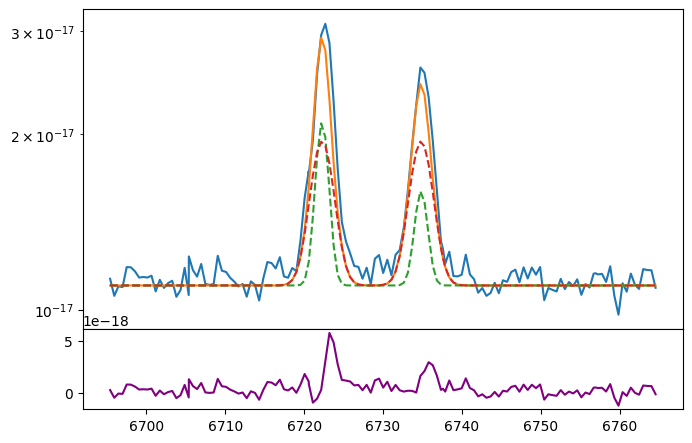

In [89]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(oi_siii.wavelength, oi_siii.flux)
bkg = 1.1e-17

oi_nar = gaussian(oi_siii.wavelength, 0.2e-16, wave_cat['[OI]6300'], z=z_nar_oiii_4959, sigma=sigma_nar_oiii_4959)
oi_brd = gaussian(oi_siii.wavelength, 0.3e-16, wave_cat['[OI]6300'], z=z_brd_oiii_4959, sigma=sigma_brd_oiii_4959)

siiic_nar = gaussian(oi_siii.wavelength, 0.1e-16, wave_cat['[SIII]6312'], z=z_nar_oiii_4959, sigma=sigma_nar_oiii_4959)
siiic_brd = gaussian(oi_siii.wavelength, 0.3e-16, wave_cat['[SIII]6312'], z=z_brd_oiii_4959, sigma=sigma_brd_oiii_4959)

ax.plot(oi_siii.wavelength, bkg + siiic_nar + siiic_brd + oi_nar + oi_brd)
ax.plot(oi_siii.wavelength, bkg + siiic_nar + oi_nar, ls='--')
ax.plot(oi_siii.wavelength, bkg + siiic_brd + oi_brd, ls='--')
ax1.plot(oi_siii.wavelength, oi_siii.flux - bkg - siiic_nar - siiic_brd - oi_nar - oi_brd, color='purple')
ax.set_yscale('log')

In [90]:
params_oi_siii = Parameters()
params_oi_siii.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_oi_siii.add('z_ratio', value=z_ratio, vary=False)
params_oi_siii.add('sigma_nar', value=sigma_nar_oiii_4959, vary=False)
params_oi_siii.add('sigma_brd', value=sigma_brd_oiii_4959, vary=False)
params_oi_siii.add('Oi_nar', value=0.2e-16, min=0.)
params_oi_siii.add('Oi_brd', value=0.3e-16, min=0.)
params_oi_siii.add('Siiic_nar', value=0.1e-16, min=0.)
params_oi_siii.add('Siiic_brd', value=0.3e-16, min=0.)
params_oi_siii.add('bkg', value=1.1e-17, min=0.)


def residual_oi_siii(params_oi_siii, x, data, uncertainty):
    
    z_nar = params_oi_siii['z_nar']
    z_brd = params_oi_siii['z_nar'] * params_oi_siii['z_ratio']
    sigma_nar = params_oi_siii['sigma_nar']
    sigma_brd = params_oi_siii['sigma_brd']
    oi_nar = params_oi_siii['Oi_nar']
    oi_brd = params_oi_siii['Oi_brd']
    siiic_nar = params_oi_siii['Siiic_nar']
    siiic_brd = params_oi_siii['Siiic_brd']
    bkg = params_oi_siii['bkg']
    
    x = oi_siii.wavelength
    model_oi = gaussian(x, oi_nar, wave_cat['[OI]6300'], z_nar, sigma_nar) \
             + gaussian(x, oi_brd, wave_cat['[OI]6300'], z_brd, sigma_brd)
    model_siii = gaussian(x, siiic_nar, wave_cat['[SIII]6312'], z_nar, sigma_nar) \
               + gaussian(x, siiic_brd, wave_cat['[SIII]6312'], z_brd, sigma_brd)
    
    return (model_siii + model_oi + bkg - oi_siii.flux) / oi_siii.noise

In [91]:
np.random.seed(2225)
out_oi_siii = minimize(residual_oi_siii, params_oi_siii, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

100%|███████████████████████████████████████| 2500/2500 [00:26<00:00, 92.71it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 4 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 44.15918565  96.79655424 111.39300949  57.93786082  59.20919712
  47.30317991]


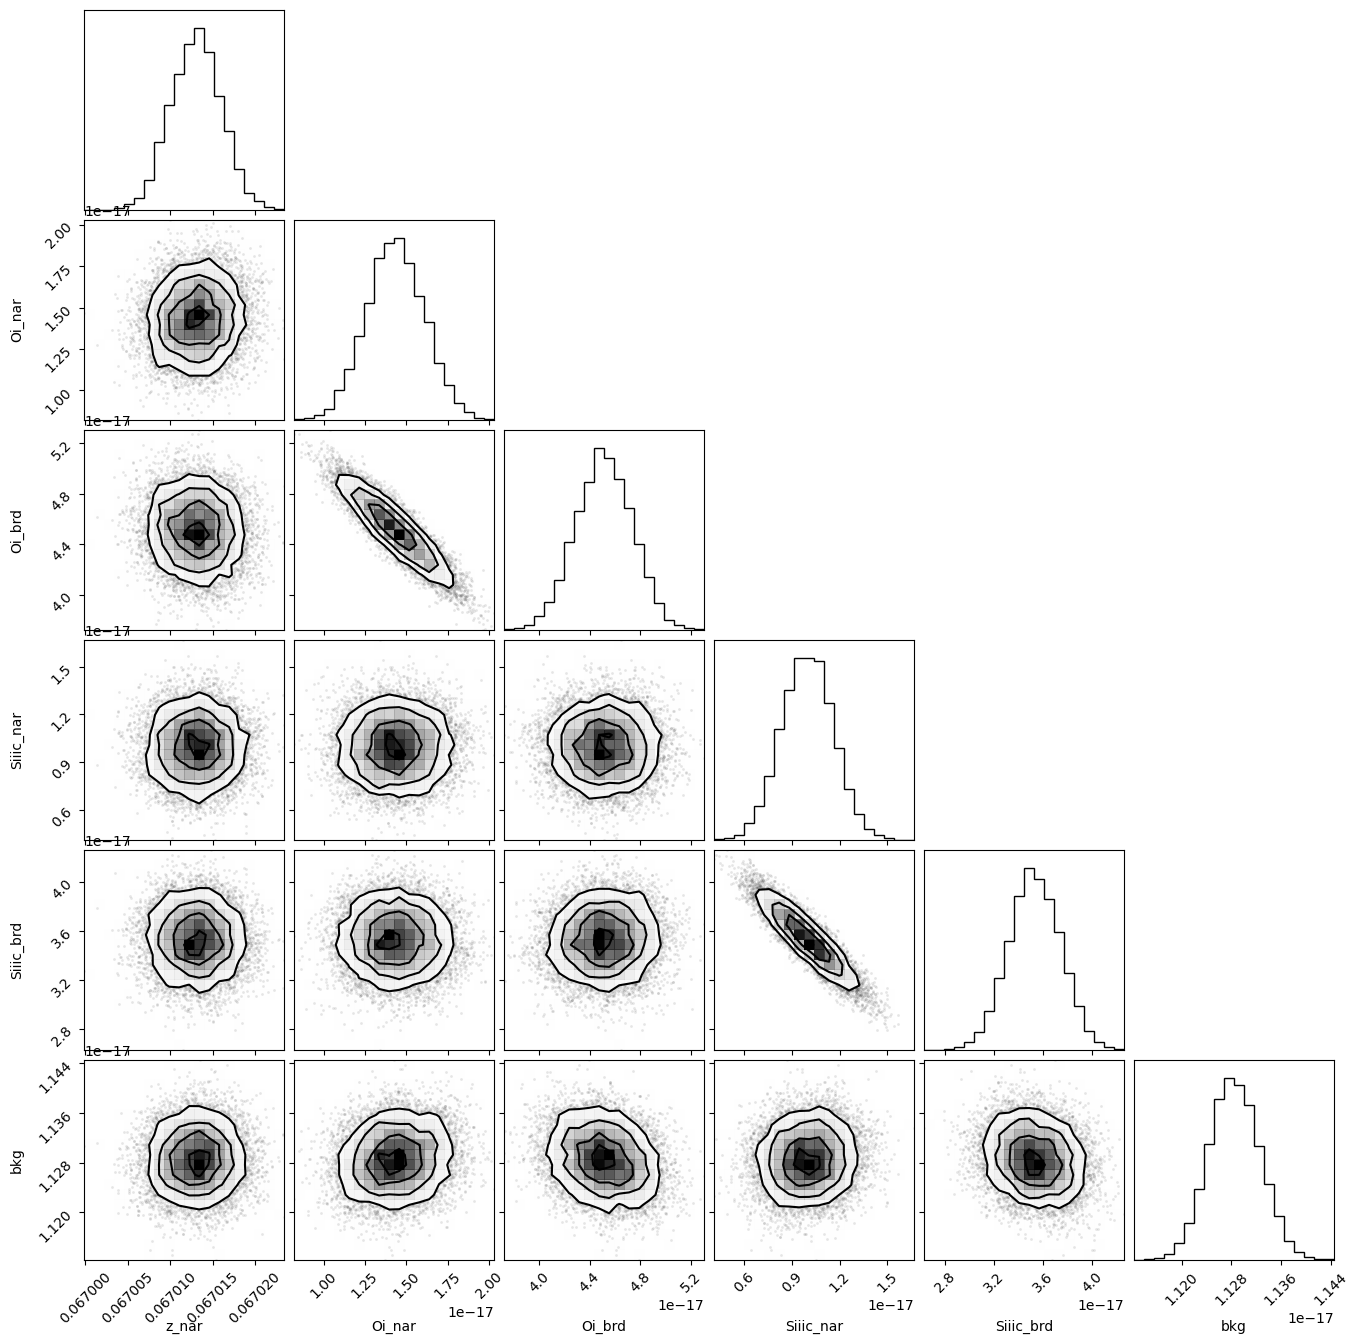

In [92]:
corner.corner(out_oi_siii.flatchain, labels=out_oi_siii.var_names);
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

In [93]:
out_oi_siii

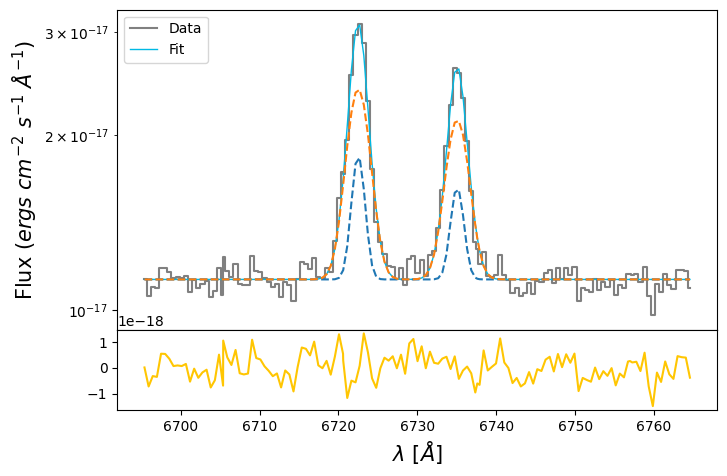

In [94]:
oi_nar_flux = out_oi_siii.flatchain.Oi_nar.mean()
oi_nar_std = out_oi_siii.flatchain.Oi_nar.std()

oi_brd_flux = out_oi_siii.flatchain.Oi_brd.mean()
oi_brd_std = out_oi_siii.flatchain.Oi_brd.std()

siiic_nar_flux = out_oi_siii.flatchain.Siiic_nar.mean()
siiic_nar_std = out_oi_siii.flatchain.Siiic_nar.std()

siiic_brd_flux = out_oi_siii.flatchain.Siiic_brd.mean()
siiic_brd_std = out_oi_siii.flatchain.Siiic_brd.std()

z_oi_siii = out_oi_siii.flatchain.z_nar.mean()
z_oi_siii_std = out_oi_siii.flatchain.z_nar.std()

bkg_oi_siii = out_oi_siii.flatchain.bkg.mean()
bkg_oi_siii_std = out_oi_siii.flatchain.bkg.std()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(oi_siii.wavelength, oi_siii.flux,
            color='gray', label='Data', where='mid')

oi_nar = gaussian(oi_siii.wavelength, oi_nar_flux, wave_cat['[OI]6300'], z_oi_siii, sigma_nar_oiii_4959)
oi_brd = gaussian(oi_siii.wavelength, oi_brd_flux, wave_cat['[OI]6300'], z_oi_siii * z_ratio, sigma_brd_oiii_4959)

siiic_nar = gaussian(oi_siii.wavelength, siiic_nar_flux, wave_cat['[SIII]6312'], z_oi_siii, sigma_nar_oiii_4959)
siiic_brd = gaussian(oi_siii.wavelength, siiic_brd_flux, wave_cat['[SIII]6312'], z_oi_siii * z_ratio, sigma_brd_oiii_4959)

oi = oi_nar + oi_brd
siiic = siiic_nar + siiic_brd

ax.plot(oi_siii.wavelength, bkg_oi_siii + siiic + oi,
        lw=1, color=c[0], label='Fit')
ax.plot(oi_siii.wavelength, bkg_oi_siii + siiic_nar + oi_nar, ls='--')
ax.plot(oi_siii.wavelength, bkg_oi_siii + siiic_brd + oi_brd, ls='--')

ax1.plot(oi_siii.wavelength, oi_siii.flux - bkg_oi_siii - siiic - oi,
         color=c[3])
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
ax.set_yscale('log')
ax.legend(loc='upper left')
#plt.savefig(fname='ha_nii.svg', bbox_inches='tight')

#ls_6300 = (wave_cat['[OI]6300'] * (1 + z_oi_siii)) + (3 * sigma_brd_oiii_4959)
#li_6300 = (wave_cat['[OI]6300'] * (1 + z_oi_siii)) - (3 * sigma_brd_oiii_4959)

#ls_6312 = (wave_cat['[SIII]6312'] * (1 + z_oi_siii)) + (3 * sigma_brd_oiii_4959)
#li_6312 = (wave_cat['[SIII]6312'] * (1 + z_oi_siii)) - (3 * sigma_brd_oiii_4959)

#ax.axvline(ls_6300, ls='--', color='gray', lw=0.8)
#ax.axvline(li_6300, ls='--', color='gray', lw=0.8)

#ax.axvline(ls_6312, ls='--', color='gray', lw=0.8)
#ax.axvline(li_6312, ls='--', color='gray', lw=0.8)

In [95]:
# EW
EW_OI_6300_nar = ufloat(oi_nar_flux, oi_nar_std) / ufloat(bkg_oi_siii, bkg_oi_siii_std)
EW_OI_6300_brd = ufloat(oi_brd_flux, oi_brd_std) / ufloat(bkg_oi_siii, bkg_oi_siii_std)
EW_OI_6300 = (ufloat(oi_nar_flux, oi_nar_std) + ufloat(oi_brd_flux, oi_brd_std)) / ufloat(bkg_oi_siii, bkg_oi_siii_std)

EW_SIII_6312_nar = ufloat(siiic_nar_flux, siiic_nar_std) / ufloat(bkg_oi_siii, bkg_oi_siii_std)
EW_SIII_6312_brd = ufloat(siiic_brd_flux, siiic_brd_std) / ufloat(bkg_oi_siii, bkg_oi_siii_std)
EW_SIII_6312 = (ufloat(siiic_nar_flux, siiic_nar_std) + ufloat(siiic_brd_flux, siiic_brd_std)) / ufloat(bkg_oi_siii, bkg_oi_siii_std)

mask_6300 = (oi_siii.wavelength >= li_6300) & (oi_siii.wavelength < ls_6300)
mask_6312 = (oi_siii.wavelength >= li_6312) & (oi_siii.wavelength < ls_6312)

c_mask_oi_siii = (oi_siii.wavelength > ls_6312) + (oi_siii.wavelength < li_6300)

N_6300 = len(oi_siii.wavelength[mask_6300])
N_6312 = len(oi_siii.wavelength[mask_6312])

sigmac_oi_siii = np.std(oi_siii.flux[c_mask_oi_siii])

# Uncertainties added

sigmal_6300_nar = sigmac_oi_siii * np.sqrt(N_6300 + (EW_OI_6300_nar.nominal_value/dLam))
sigmal_6300_brd = sigmac_oi_siii * np.sqrt(N_6300 + (EW_OI_6300_brd.nominal_value/dLam))

sigmal_6312_nar = sigmac_oi_siii * np.sqrt(N_6312 + (EW_SIII_6312_nar.nominal_value/dLam))
sigmal_6312_brd = sigmac_oi_siii * np.sqrt(N_6312 + (EW_SIII_6312_brd.nominal_value/dLam))

print('Previous nar error (Oi)', oi_nar_std)
print('Previous brd error (Oi)', oi_brd_std)

print('Previous nar error (Siiic)', siiic_nar_std)
print('Previous brd error (Siiic)', siiic_brd_std)

# Final uncertainties
oi_nar_std = np.sqrt((oi_nar_std**2) + (sigmal_6300_nar**2))
oi_brd_std = np.sqrt((oi_brd_std**2) + (sigmal_6300_brd**2))

siiic_nar_std = np.sqrt((siiic_nar_std**2) + (sigmal_6312_nar**2))
siiic_brd_std = np.sqrt((siiic_brd_std**2) + (sigmal_6312_brd**2))

print('New nar error (Oi)', oi_nar_std)
print('New brd error (Oi)', oi_brd_std)

print('New nar error (Siiic)', siiic_nar_std)
print('New brd error (Siiic)', siiic_brd_std)

## [OIII]5007 + HeI 5015

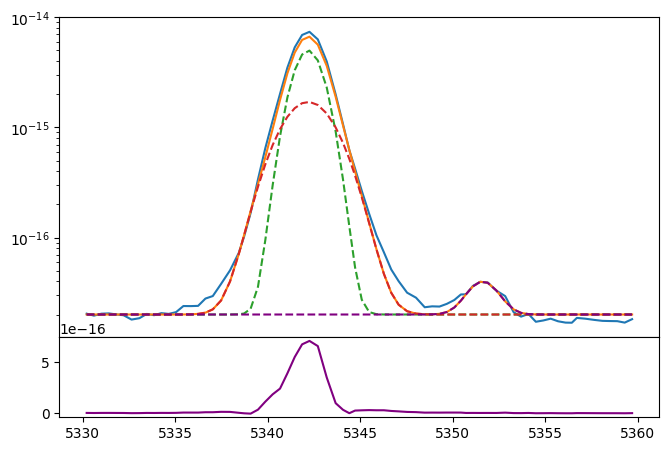

In [96]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(oiii_hei.wavelength, oiii_hei.flux)
bkg = 2e-17

oiiia_nar = gaussian(oiii_hei.wavelength, 1e-14, wave_cat['[OIII]5007'], z=z_nar_oiii_4959, sigma=sigma_nar_oiii_4959)
oiiia_brd = gaussian(oiii_hei.wavelength, 6e-15, wave_cat['[OIII]5007'], z=z_brd_oiii_4959, sigma=sigma_brd_oiii_4959)

hei_5015 = gaussian(oiii_hei.wavelength, 4e-17, wave_cat['HeI5015'], z=z_nar_oiii_4959, sigma=sigma_nar_oiii_4959)

ax.plot(oiii_hei.wavelength, bkg + oiiia_nar + oiiia_brd + hei_5015)
ax.plot(oiii_hei.wavelength, bkg + oiiia_nar, ls='--')
ax.plot(oiii_hei.wavelength, bkg + oiiia_brd, ls='--')
ax.plot(oiii_hei.wavelength, bkg + hei_5015, ls='--', color='purple')
ax1.plot(oiii_hei.wavelength, oiii_hei.flux - bkg - oiiia_nar - oiiia_brd - hei_5015, color='purple')
ax.set_yscale('log')

In [97]:
params_oiii_hei = Parameters()
params_oiii_hei.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_oiii_hei.add('z_ratio', value=z_ratio, vary=False)
params_oiii_hei.add('sigma_nar', value=sigma_nar_oiii_4959, vary=False)
params_oiii_hei.add('sigma_brd', value=sigma_brd_oiii_4959, vary=False)
params_oiii_hei.add('Hei', value=4e-17, min=0.)
params_oiii_hei.add('Oiiia_nar', value=1.0e-14, min=0.)
params_oiii_hei.add('Oiiia_brd', value=6.0e-15, min=0.)
params_oiii_hei.add('bkg', value=2e-17, min=0.)


def residual_oiii_hei(params_oiii_hei, x, data, uncertainty):
    
    z_nar = params_oiii_hei['z_nar']
    z_brd = params_oiii_hei['z_nar'] * params_oiii_hei['z_ratio']
    sigma_nar = params_oiii_hei['sigma_nar']
    sigma_brd = params_oiii_hei['sigma_brd']
    oiiia_nar = params_oiii_hei['Oiiia_nar']
    oiiia_brd = params_oiii_hei['Oiiia_brd']
    hei = params_oiii_hei['Hei']
    bkg = params_oiii_hei['bkg']
    
    x = oiii_hei.wavelength
    model_oiii = gaussian(x, oiiia_nar, wave_cat['[OIII]5007'], z_nar, sigma_nar) \
               + gaussian(x, oiiia_brd, wave_cat['[OIII]5007'], z_brd, sigma_brd)
    model_hei = gaussian(x, hei, wave_cat['HeI5015'], z_nar, sigma_nar)
    
    return (model_oiii + model_hei + bkg - oiii_hei.flux) / oiii_hei.noise

In [98]:
np.random.seed(2225)
out_oiii_hei = minimize(residual_oiii_hei, params_oiii_hei, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

100%|██████████████████████████████████████| 2500/2500 [00:22<00:00, 112.46it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 4 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [24.83042557 69.56817502 75.17158334 60.87026169 81.176149  ]


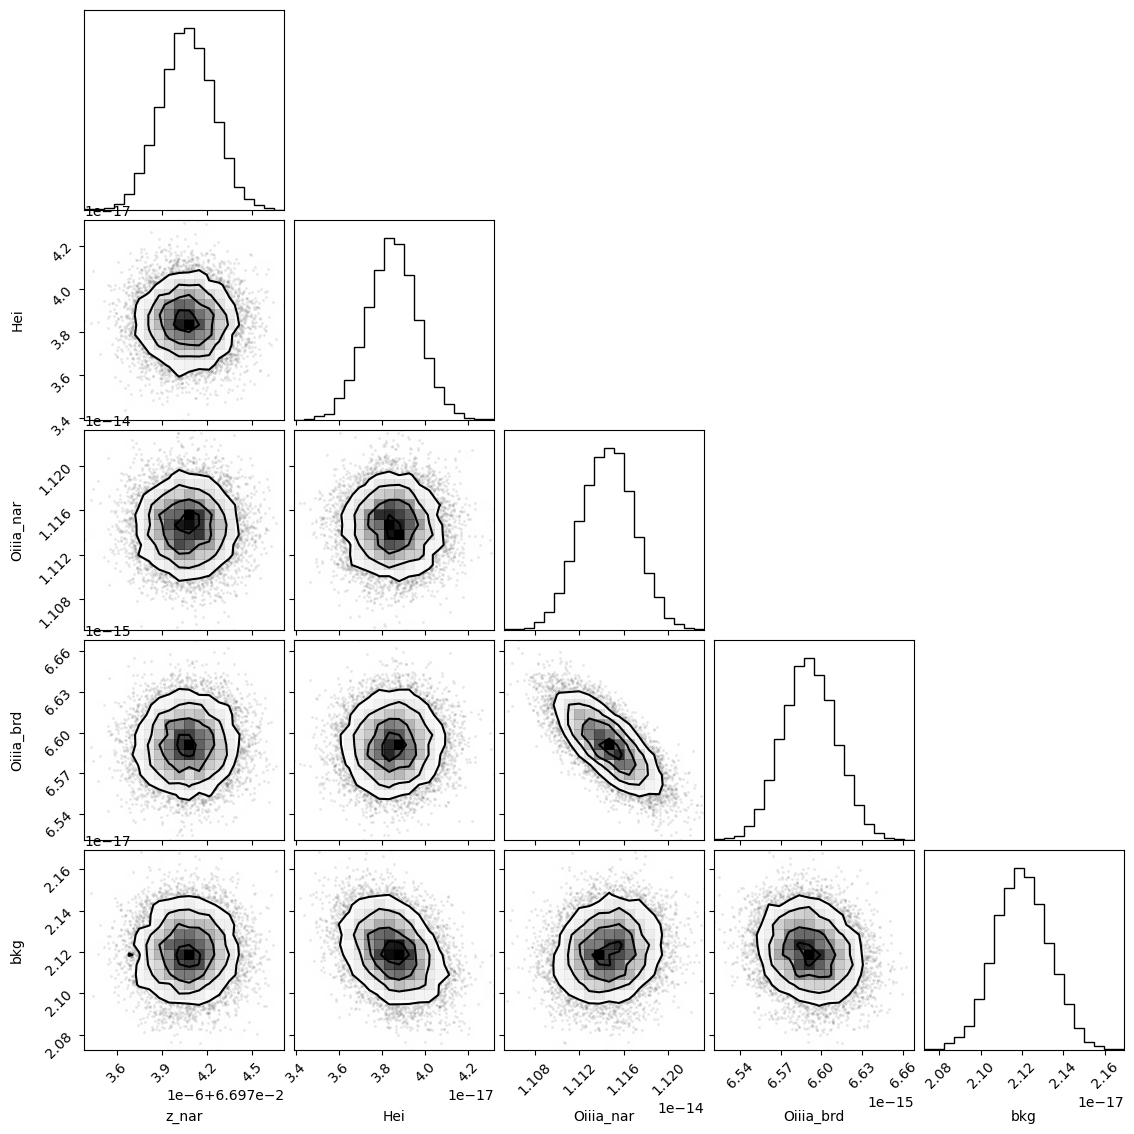

In [99]:
corner.corner(out_oiii_hei.flatchain, labels=out_oiii_hei.var_names);
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

In [100]:
out_oiii_hei

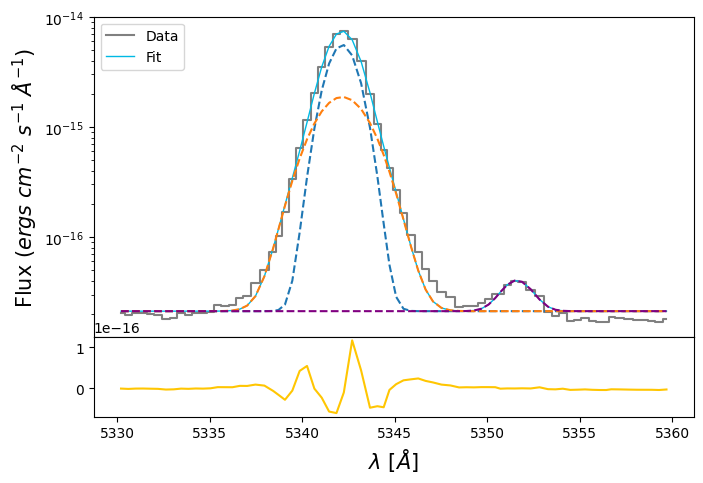

In [101]:
hei_flux = out_oiii_hei.flatchain.Hei.mean()
hei_std = out_oiii_hei.flatchain.Hei.std()

oiiia_nar_flux = out_oiii_hei.flatchain.Oiiia_nar.mean()
oiiia_nar_std = out_oiii_hei.flatchain.Oiiia_nar.std()

oiiia_brd_flux = out_oiii_hei.flatchain.Oiiia_brd.mean()
oiiia_brd_std = out_oiii_hei.flatchain.Oiiia_brd.std()

z_oiii_hei = out_oiii_hei.flatchain.z_nar.mean()
z_oiii_hei_std = out_oiii_hei.flatchain.z_nar.std()

bkg_oiii_hei = out_oiii_hei.flatchain.bkg.mean()
bkg_oiii_hei_std = out_oiii_hei.flatchain.bkg.std()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(oiii_hei.wavelength, oiii_hei.flux,
            color='gray', label='Data', where='mid')

hei = gaussian(oiii_hei.wavelength, hei_flux, wave_cat['HeI5015'], z_oiii_hei, sigma_nar_oiii_4959)

oiiia_nar = gaussian(oiii_hei.wavelength, oiiia_nar_flux, wave_cat['[OIII]5007'], z_oiii_hei, sigma_nar_oiii_4959)
oiiia_brd = gaussian(oiii_hei.wavelength, oiiia_brd_flux, wave_cat['[OIII]5007'], z_oiii_hei * z_ratio, sigma_brd_oiii_4959)

oiiia = oiiia_nar + oiiia_brd

ax.plot(oiii_hei.wavelength, bkg_oiii_hei + oiiia + hei,
        lw=1, color=c[0], label='Fit')
ax.plot(oiii_hei.wavelength, bkg_oiii_hei + oiiia_nar, ls='--')
ax.plot(oiii_hei.wavelength, bkg_oiii_hei + oiiia_brd, ls='--')
ax.plot(oiii_hei.wavelength, bkg_oiii_hei + hei, ls='--', color='purple')

ax1.plot(oiii_hei.wavelength, oiii_hei.flux - bkg_oiii_hei - oiiia - hei,
         color=c[3])
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
ax.set_yscale('log')
ax.legend(loc='upper left')
#plt.savefig(fname='ha_nii.svg', bbox_inches='tight')

#ls_5007 = (wave_cat['[OIII]5007'] * (1 + z_oiii_hei)) + (5 * sigma_brd_oiii_4959)
#li_5007 = (wave_cat['[OIII]5007'] * (1 + z_oiii_hei)) - (5 * sigma_brd_oiii_4959)

#ax.axvline(ls_5007, ls='--', color='gray', lw=0.8)
#ax.axvline(li_5007, ls='--', color='gray', lw=0.8)

In [102]:
# EW
EW_OIII_5007_nar = ufloat(oiiia_nar_flux, oiiia_nar_std) / ufloat(bkg_oiii_hei, bkg_oiii_hei_std)
EW_OIII_5007_brd = ufloat(oiiia_brd_flux, oiiia_brd_std) / ufloat(bkg_oiii_hei, bkg_oiii_hei_std)
EW_OIII_5007 = (ufloat(oiiia_nar_flux, oiiia_nar_std) + ufloat(oiiia_brd_flux, oiiia_brd_std)) / ufloat(bkg_oiii_hei, bkg_oiii_hei_std)

mask_5007 = (oiii_hei.wavelength >= li_5007) & (oiii_hei.wavelength < ls_5007)
N_5007 = len(oiii_hei.wavelength[mask_5007])
sigmac_5007 = np.std(oiii_hei.flux[np.logical_not(mask_5007)])

# Uncertainties added
sigmal_5007_nar = sigmac_5007 * np.sqrt(N_5007 + (EW_OIII_5007_nar.nominal_value/dLam))
sigmal_5007_brd = sigmac_5007 * np.sqrt(N_5007 + (EW_OIII_5007_brd.nominal_value/dLam))

print('Previous narrow error:', oiiia_nar_std)
print('Previous broad error:', oiiia_brd_std)

# Final uncertainties
oiiia_nar_std = np.sqrt(oiiia_nar_std**2 + sigmal_5007_nar**2)
oiiia_brd_std = np.sqrt(oiiia_brd_std**2 + sigmal_5007_brd**2)

print('New narrow error:', oiiia_nar_std)
print('New broad error:', oiiia_brd_std)

## [OIII]4363

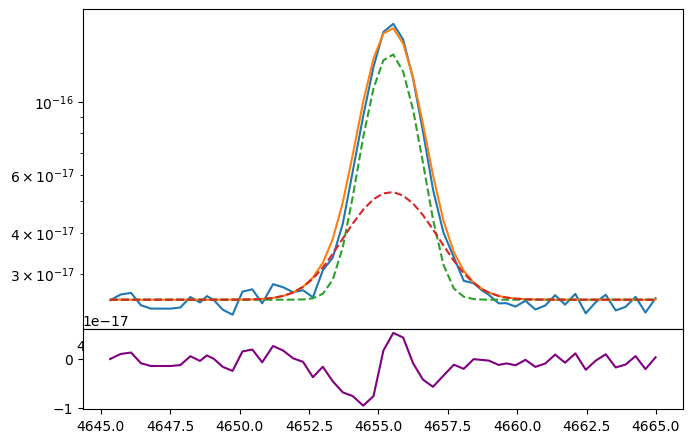

In [103]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(oiii_4363.wavelength, oiii_4363.flux)
bkg = 2.5e-17

oiiic_nar = gaussian(oiii_4363.wavelength, 2.3e-16, wave_cat['[OIII]4363'], z=z_nar_oiii_4959, sigma=sigma_nar_oiii_4959)
oiiic_brd = gaussian(oiii_4363.wavelength, 1e-16, wave_cat['[OIII]4363'], z=z_brd_oiii_4959, sigma=sigma_brd_oiii_4959)

ax.plot(oiii_4363.wavelength, bkg + oiiic_nar + oiiic_brd)
ax.plot(oiii_4363.wavelength, bkg + oiiic_nar, ls='--')
ax.plot(oiii_4363.wavelength, bkg + oiiic_brd, ls='--')
ax1.plot(oiii_4363.wavelength, oiii_4363.flux - bkg - oiiic_nar - oiiic_brd, color='purple')
ax.set_yscale('log')

In [104]:
params_oiiic = Parameters()

params_oiiic.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_oiiic.add('z_ratio', value=z_ratio, vary=False)
params_oiiic.add('sigma_nar', value=sigma_nar_oiii_4959, vary=False)
params_oiiic.add('sigma_brd', value=sigma_brd_oiii_4959, vary=False)
params_oiiic.add('Oiiic_nar', value=2.3e-16, min=0.)
params_oiiic.add('Oiiic_brd', value=1.0e-16, min=0.)
params_oiiic.add('bkg', value=2.5e-17, min=0.)


def residual_oiiic(params_oiiic, x, data, uncertainty):
    
    z_nar = params_oiiic['z_nar']
    z_brd = params_oiiic['z_nar'] * params_oiiic['z_ratio']
    sigma_nar = params_oiiic['sigma_nar']
    sigma_brd = params_oiiic['sigma_brd']
    oiiic_nar_flux = params_oiiic['Oiiic_nar']
    oiiic_brd_flux = params_oiiic['Oiiic_brd']
    bkg = params_oiiic['bkg']
    
    x = oiii_4363.wavelength
    model = gaussian(x, oiiic_nar_flux, wave_cat['[OIII]4363'], z_nar, sigma_nar) + \
            gaussian(x, oiiic_brd_flux, wave_cat['[OIII]4363'], z_brd, sigma_brd)
    
    return (model + bkg - oiii_4363.flux) / oiii_4363.noise

In [105]:
np.random.seed(2225)
out_oiiic = minimize(residual_oiiic, params_oiiic, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

100%|██████████████████████████████████████| 2500/2500 [00:19<00:00, 131.03it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 2 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [39.5978966  76.77985451 83.1517552  36.26294733]


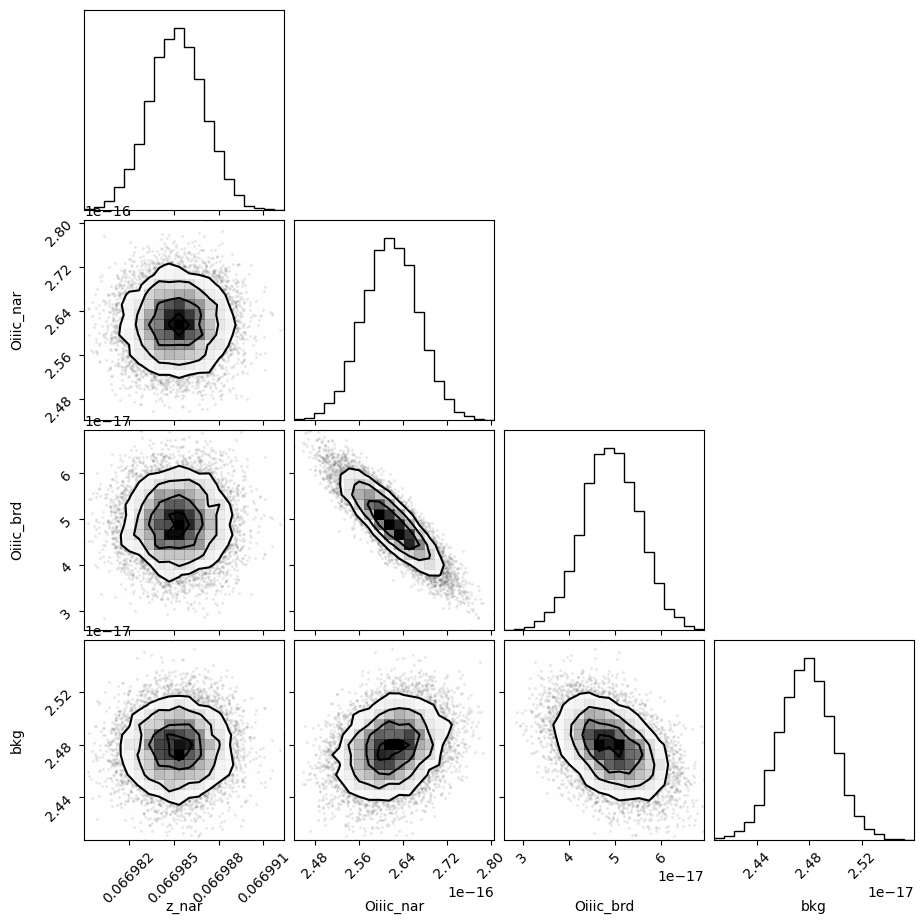

In [106]:
corner.corner(out_oiiic.flatchain, labels=out_oiiic.var_names);
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

In [107]:
out_oiiic

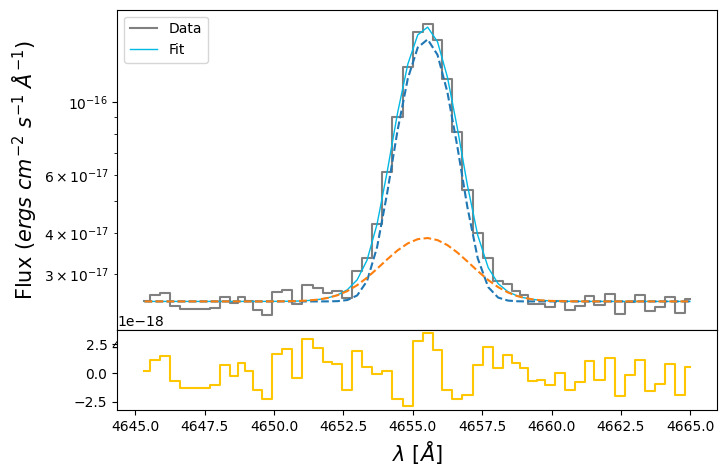

In [108]:
oiiic_nar_flux = out_oiiic.flatchain.Oiiic_nar.mean()
oiiic_nar_std = out_oiiic.flatchain.Oiiic_nar.std()

oiiic_brd_flux = out_oiiic.flatchain.Oiiic_brd.mean()
oiiic_brd_std = out_oiiic.flatchain.Oiiic_brd.std()

z_oiii = out_oiiic.flatchain.z_nar.mean()
z_oiii_std = out_oiiic.flatchain.z_nar.std()

bkg_oiiic = out_oiiic.flatchain.bkg.mean()
bkg_oiiic_std = out_oiiic.flatchain.bkg.std()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(oiii_4363.wavelength, oiii_4363.flux,
            color='gray', label='Data', where='mid')

oiiic_nar = gaussian(oiii_4363.wavelength, oiiic_nar_flux, wave_cat['[OIII]4363'], z_oiii, sigma_nar_oiii_4959)
oiiic_brd = gaussian(oiii_4363.wavelength, oiiic_brd_flux, wave_cat['[OIII]4363'], z_oiii * z_ratio, sigma_brd_oiii_4959)
oiiic = oiiic_nar + oiiic_brd

ax.plot(oiii_4363.wavelength, bkg_oiiic + oiiic, lw=1, color=c[0], label='Fit')
ax.plot(oiii_4363.wavelength, bkg_oiiic + oiiic_nar, ls='--')
ax.plot(oiii_4363.wavelength, bkg_oiiic + oiiic_brd, ls='--')
ax1.step(oiii_4363.wavelength, oiii_4363.flux - bkg_oiiic - oiiic, color=c[3], where='mid')
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
ax.set_yscale('log')
ax.legend(loc='upper left')
#plt.savefig(fname='ha_nii.svg', bbox_inches='tight')

#ls_4363 = (wave_cat['[OIII]4363'] * (1 + z_oiii)) + (3 * sigma_brd_oiii_4959)
#li_4363 = (wave_cat['[OIII]4363'] * (1 + z_oiii)) - (3 * sigma_brd_oiii_4959)

#ax.axvline(ls_4363, ls='--', color='gray', lw=0.8)
#ax.axvline(li_4363, ls='--', color='gray', lw=0.8)

In [109]:
# EW
EW_OIII_4363_nar = ufloat(oiiic_nar_flux, oiiic_nar_std) / ufloat(bkg_oiiic, bkg_oiiic_std)
EW_OIII_4363_brd = ufloat(oiiic_brd_flux, oiiic_brd_std) / ufloat(bkg_oiiic, bkg_oiiic_std)
EW_OIII_4363 = (ufloat(oiiic_nar_flux, oiiic_nar_std) + ufloat(oiiic_brd_flux, oiiic_brd_std)) / ufloat(bkg_oiiic, bkg_oiiic_std)

mask_4363 = (oiii_4363.wavelength >= li_4363) & (oiii_4363.wavelength < ls_4363)
N_4363 = len(oiii_4363.wavelength[mask_4363])
sigmac_4363 = np.std(oiii_4363.flux[np.logical_not(mask_4363)])

# Uncertainties added
sigmal_4363_nar = sigmac_4363 * np.sqrt(N_4363 + (EW_OIII_4363_nar.nominal_value/dLam))
sigmal_4363_brd = sigmac_4363 * np.sqrt(N_4363 + (EW_OIII_4363_brd.nominal_value/dLam))

print('Previous narrow error:', oiiic_nar_std)
print('Previous broad error:', oiiic_brd_std)

# Final uncertainties
oiiic_nar_std = np.sqrt(oiiic_nar_std**2 + sigmal_4363_nar**2)
oiiic_brd_std = np.sqrt(oiiic_brd_std**2 + sigmal_4363_brd**2)

print('New narrow error:', oiiic_nar_std)
print('New broad error:', oiiic_brd_std)

## [NeIII]3686

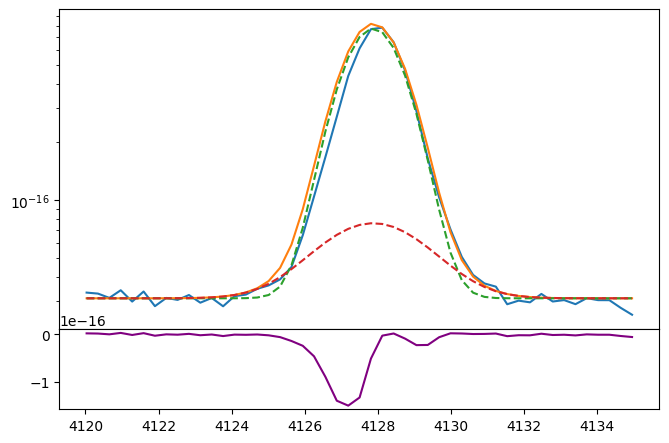

In [110]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(neiii_3868.wavelength, neiii_3868.flux)
bkg = 3.1e-17

neiiia_nar = gaussian(neiii_3868.wavelength, 1.5e-15, wave_cat['[NeIII]3868'], z=z_nar_oiii_4959, sigma=sigma_nar_oiii_4959)
neiiia_brd = gaussian(neiii_3868.wavelength, 1.6e-16, wave_cat['[NeIII]3868'], z=z_brd_oiii_4959, sigma=sigma_brd_oiii_4959)

ax.plot(neiii_3868.wavelength, bkg + neiiia_nar + neiiia_brd)
ax.plot(neiii_3868.wavelength, bkg + neiiia_nar, ls='--')
ax.plot(neiii_3868.wavelength, bkg + neiiia_brd, ls='--')
ax1.plot(neiii_3868.wavelength, neiii_3868.flux - bkg - neiiia_nar - neiiia_brd, color='purple')
ax.set_yscale('log')

In [111]:
params_neiii_3868 = Parameters()
params_neiii_3868.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_neiii_3868.add('z_ratio', value=z_ratio, vary=False)
params_neiii_3868.add('sigma_nar', value=sigma_nar_oiii_4959, vary=False)
params_neiii_3868.add('sigma_brd', value=sigma_brd_oiii_4959, vary=False)
params_neiii_3868.add('Neiiia_nar', value=1.5e-15, min=0.)
params_neiii_3868.add('Neiiia_brd', value=1.6e-16, min=0.)
params_neiii_3868.add('bkg', value=3.1e-17, min=0.)


def residual_neiii_3868(params_neiii_3868, x, data, uncertainty):
    
    z_nar = params_neiii_3868['z_nar']
    z_brd = params_neiii_3868['z_nar'] * params_neiii_3868['z_ratio']
    sigma_nar = params_neiii_3868['sigma_nar']
    sigma_brd = params_neiii_3868['sigma_brd']
    neiiia_nar_flux = params_neiii_3868['Neiiia_nar']
    neiiia_brd_flux = params_neiii_3868['Neiiia_brd']
    bkg = params_neiii_3868['bkg']
    
    x = neiii_3868.wavelength
    model = gaussian(x, neiiia_nar_flux, wave_cat['[NeIII]3868'], z_nar, sigma_nar) + \
            gaussian(x, neiiia_brd_flux, wave_cat['[NeIII]3868'], z_brd, sigma_brd)
    
    return (model + bkg - neiii_3868.flux) / neiii_3868.noise

In [112]:
np.random.seed(2225)
out_neiii_3868 = minimize(residual_neiii_3868, params_neiii_3868, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

100%|██████████████████████████████████████| 2500/2500 [00:18<00:00, 136.32it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 2 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 21.81555685  19.8978983  123.95004363  80.92491665]


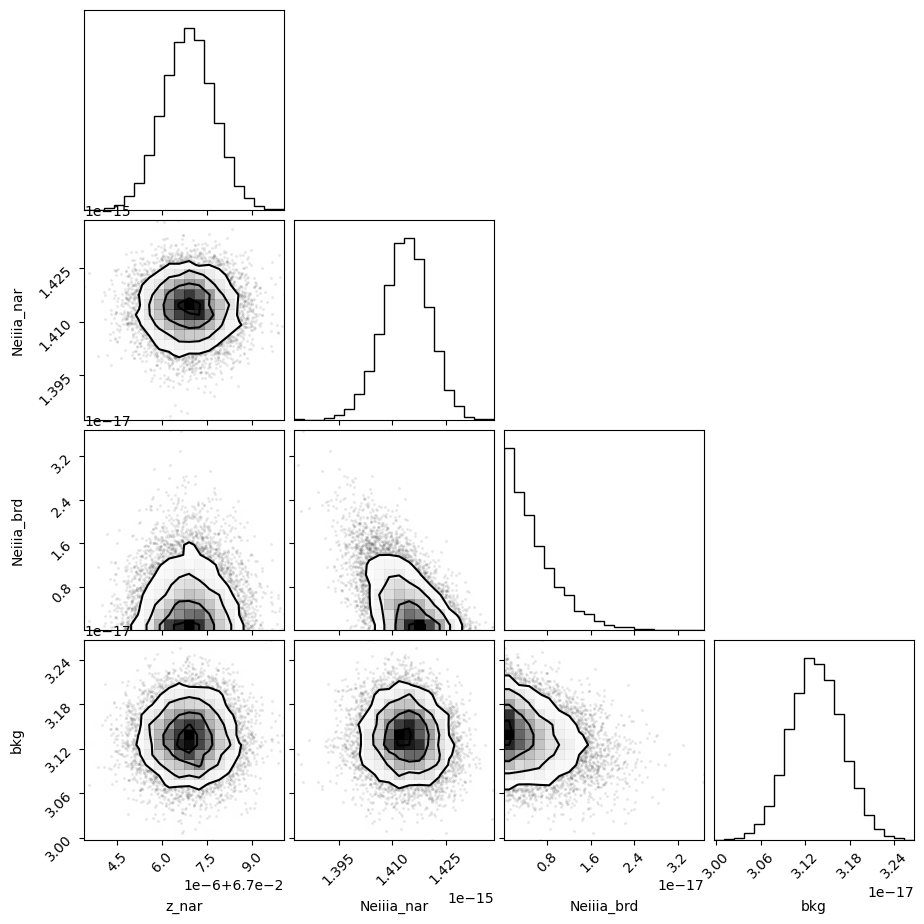

In [113]:
corner.corner(out_neiii_3868.flatchain, labels=out_neiii_3868.var_names);
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

In [114]:
out_neiii_3868

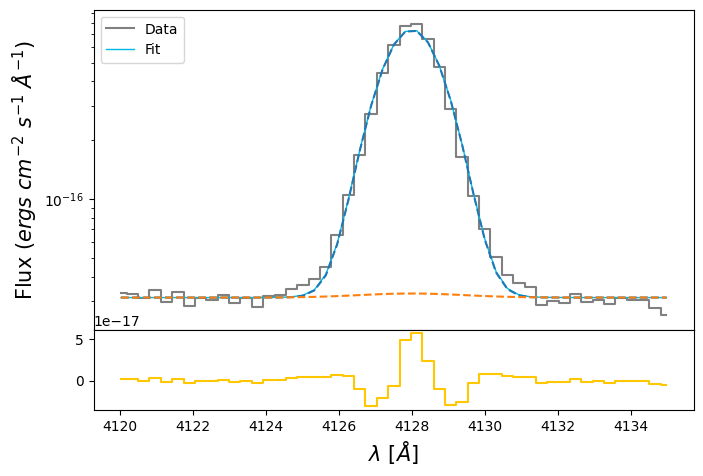

In [115]:
neiiia_nar_flux = out_neiii_3868.flatchain.Neiiia_nar.mean()
neiiia_nar_std = out_neiii_3868.flatchain.Neiiia_nar.std()

neiiia_brd_flux = out_neiii_3868.flatchain.Neiiia_brd.mean()
neiiia_brd_std = out_neiii_3868.flatchain.Neiiia_brd.std()

z_neiii = out_neiii_3868.flatchain.z_nar.mean()
z_neiii_std = out_neiii_3868.flatchain.z_nar.std()

bkg_neiiia = out_neiii_3868.flatchain.bkg.mean()
bkg_neiiia_std = out_neiii_3868.flatchain.bkg.std()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(neiii_3868.wavelength, neiii_3868.flux,
            color='gray', label='Data', where='mid')

neiiia_nar = gaussian(neiii_3868.wavelength, neiiia_nar_flux, wave_cat['[NeIII]3868'], z_neiii, sigma_nar_oiii_4959)
neiiia_brd = gaussian(neiii_3868.wavelength, neiiia_brd_flux, wave_cat['[NeIII]3868'], z_neiii * z_ratio, sigma_brd_oiii_4959)
neiiia = neiiia_nar + neiiia_brd

ax.plot(neiii_3868.wavelength, bkg_neiiia + neiiia, lw=1, color=c[0], label='Fit')
ax.plot(neiii_3868.wavelength, bkg_neiiia + neiiia_nar, ls='--')
ax.plot(neiii_3868.wavelength, bkg_neiiia + neiiia_brd, ls='--')
ax1.step(neiii_3868.wavelength, neiii_3868.flux - bkg_neiiia - neiiia, color=c[3], where='mid')
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
ax.set_yscale('log')
ax.legend(loc='upper left')
#plt.savefig(fname='ha_nii.svg', bbox_inches='tight')

#ls_3868 = (wave_cat['[NeIII]3868'] * (1 + z_neiii)) + (3 * sigma_brd_oiii_4959)
#li_3868 = (wave_cat['[NeIII]3868'] * (1 + z_neiii)) - (3 * sigma_brd_oiii_4959)

#ax.axvline(ls_3868, ls='--', color='gray', lw=0.8)
#ax.axvline(li_3868, ls='--', color='gray', lw=0.8)

In [116]:
# EW
EW_NeIII_3868_nar = ufloat(neiiia_nar_flux, neiiia_nar_std) / ufloat(bkg_neiiia, bkg_neiiia_std)
EW_NeIII_3868_brd = ufloat(neiiia_brd_flux, neiiia_brd_std) / ufloat(bkg_neiiia, bkg_neiiia_std)
EW_NeIII_3868 = (ufloat(neiiia_nar_flux, neiiia_nar_std) + ufloat(neiiia_brd_flux, neiiia_brd_std)) / ufloat(bkg_neiiia, bkg_neiiia_std)

mask_3868 = (neiii_3868.wavelength >= li_3868) & (neiii_3868.wavelength < ls_3868)
N_3868 = len(neiii_3868.wavelength[mask_3868])
sigmac_3868 = np.std(neiii_3868.flux[np.logical_not(mask_3868)])

# Uncertainties added
sigmal_3868_nar = sigmac_3868 * np.sqrt(N_3868 + (EW_NeIII_3868_nar.nominal_value/dLam))
sigmal_3868_brd = sigmac_3868 * np.sqrt(N_3868 + (EW_NeIII_3868_brd.nominal_value/dLam))

print('Previous narrow error:', neiiia_nar_std)
print('Previous broad error:', neiiia_brd_std)

# Final uncertainties
neiiia_nar_std = np.sqrt(neiiia_nar_std**2 + sigmal_3868_nar**2)
neiiia_brd_std = np.sqrt(neiiia_brd_std**2 + sigmal_3868_brd**2)

print('New narrow error:', neiiia_nar_std)
print('New broad error:', neiiia_brd_std)

# Temperatures and stuff

In [117]:
from magE.functions import TO3, TO2, ne, TN2, TS3
from magE.functions import calzetti2000 as k_cal

# Extinction
ext_cat = pd.read_csv(magePath+'results/dust_norm_cal_lines.csv')
index = np.argmax(ext_cat['galname'] == galname)
E_BV = ext_cat['E_BV'][index]

if E_BV < 0:
    E_BV = 0

In [119]:
oiiia_nar_chain = out_oiii_hei.flatchain.Oiiia_nar * 10**(0.4 * E_BV * k_cal(wave_cat['[OIII]5007']))
oiiia_brd_chain = out_oiii_hei.flatchain.Oiiia_brd * 10**(0.4 * E_BV * k_cal(wave_cat['[OIII]5007']))

oiiib_nar_chain = out_oiii_4959.flatchain.Oiiib_nar * 10**(0.4 * E_BV * k_cal(wave_cat['[OIII]4959']))
oiiib_brd_chain = out_oiii_4959.flatchain.Oiiib_brd * 10**(0.4 * E_BV * k_cal(wave_cat['[OIII]4959']))

oiiic_nar_chain = out_oiiic.flatchain.Oiiic_nar * 10**(0.4 * E_BV * k_cal(wave_cat['[OIII]4363']))
oiiic_brd_chain = out_oiiic.flatchain.Oiiic_brd * 10**(0.4 * E_BV * k_cal(wave_cat['[OIII]4363']))

siia_nar_chain = out_sii.flatchain.Siia_nar * 10**(0.4 * E_BV * k_cal(wave_cat['[SII]6730']))
siia_brd_chain = out_sii.flatchain.Siia_brd * 10**(0.4 * E_BV * k_cal(wave_cat['[SII]6730']))

siib_nar_chain = out_sii.flatchain.Siib_nar * 10**(0.4 * E_BV * k_cal(wave_cat['[SII]6716']))
siib_brd_chain = out_sii.flatchain.Siib_brd * 10**(0.4 * E_BV * k_cal(wave_cat['[SII]6716']))

oiia_nar_chain = out_oii_7320.flatchain.Oiia_nar * 10**(0.4 * E_BV * k_cal(wave_cat['[OII]7330']))
oiia_brd_chain = out_oii_7320.flatchain.Oiia_brd * 10**(0.4 * E_BV * k_cal(wave_cat['[OII]7330']))

oiib_nar_chain = out_oii_7320.flatchain.Oiib_nar * 10**(0.4 * E_BV * k_cal(wave_cat['[OII]7319']))
oiib_brd_chain = out_oii_7320.flatchain.Oiib_brd * 10**(0.4 * E_BV * k_cal(wave_cat['[OII]7319']))

oiic_nar_chain = out_oii_3727.flatchain.Oiic_nar * 10**(0.4 * E_BV * k_cal(wave_cat['[OII]3729']))
oiic_brd_chain = out_oii_3727.flatchain.Oiic_brd * 10**(0.4 * E_BV * k_cal(wave_cat['[OII]3729']))

oiid_nar_chain = out_oii_3727.flatchain.Oiid_nar * 10**(0.4 * E_BV * k_cal(wave_cat['[OII]3726']))
oiid_brd_chain = out_oii_3727.flatchain.Oiid_brd * 10**(0.4 * E_BV * k_cal(wave_cat['[OII]3726']))

siiia_nar_chain = out_siiia.flatchain.Siiia_nar * 10**(0.4 * E_BV * k_cal(wave_cat['[SIII]9532']))
siiia_brd_chain = out_siiia.flatchain.Siiia_brd * 10**(0.4 * E_BV * k_cal(wave_cat['[SIII]9532']))

siiib_nar_chain = out_siiib.flatchain.Siiib_nar * 10**(0.4 * E_BV * k_cal(wave_cat['[SIII]9069']))
siiib_brd_chain = out_siiib.flatchain.Siiib_brd * 10**(0.4 * E_BV * k_cal(wave_cat['[SIII]9069']))

siiic_nar_chain = out_oi_siii.flatchain.Siiic_nar * 10**(0.4 * E_BV * k_cal(wave_cat['[SIII]6312']))
siiic_brd_chain = out_oi_siii.flatchain.Siiic_brd * 10**(0.4 * E_BV * k_cal(wave_cat['[SIII]6312']))

In [121]:
t_OIII_nar = TO3(oiiia_nar_chain, oiiib_nar_chain, oiiic_nar_chain)
t_OIII_brd = TO3(oiiia_brd_chain, oiiib_brd_chain, oiiic_brd_chain)

den_nar = ne(siia_nar_chain, siib_nar_chain, t_OIII_nar)
den_brd = ne(siia_brd_chain, siib_brd_chain, t_OIII_brd)

t_OII_nar = TO2(oiia_nar_chain, oiib_nar_chain, oiic_nar_chain, oiid_nar_chain, den_nar)
t_OII_brd = TO2(oiia_brd_chain, oiib_brd_chain, oiic_brd_chain, oiid_brd_chain, den_brd)

t_SIII_nar = TS3(siiia_nar_chain, siiib_nar_chain, siiic_nar_chain)
t_SIII_brd = TS3(siiia_brd_chain, siiib_brd_chain, siiic_brd_chain)

(-50.0, 2500.0)

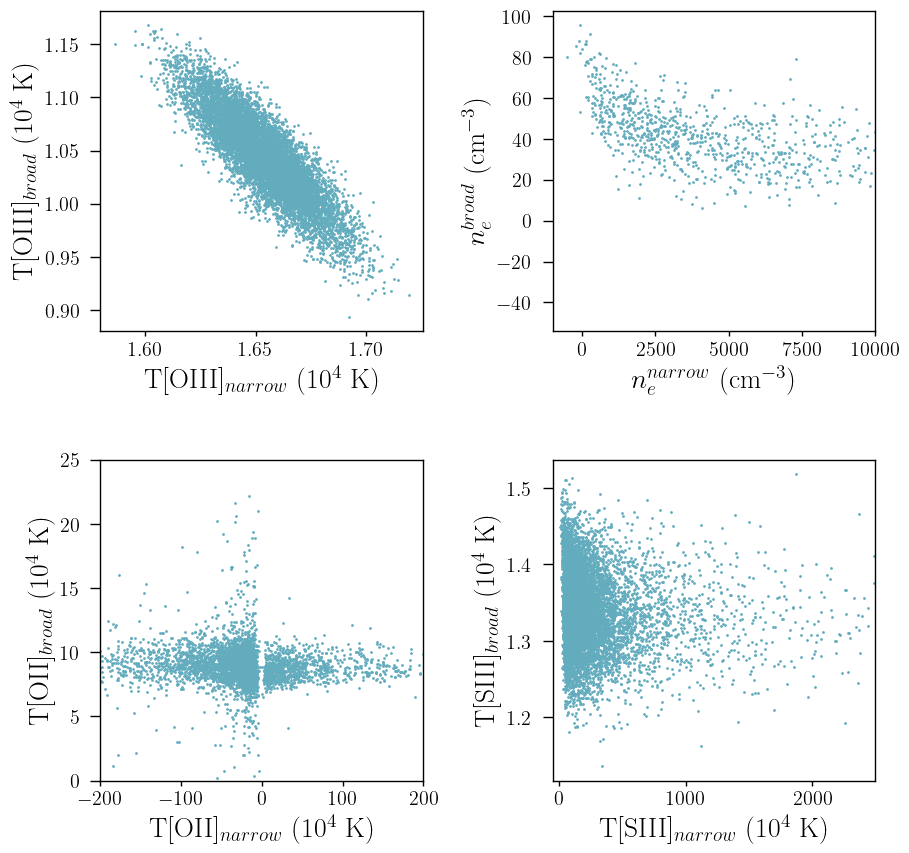

In [136]:
texPlot('on')
fig, axs = plt.subplots(2, 2)
fig.set_size_inches((10, 10))
fig.subplots_adjust(wspace=0.4, hspace=0.4)

axs[0, 0].scatter(t_OIII_nar, t_OIII_brd, s=1, color=cr[2])
axs[0, 0].set_xlabel(r'T[OIII]$_{narrow}$ (10$^{4}$ K)')
axs[0, 0].set_ylabel(r'T[OIII]$_{broad}$ (10$^{4}$ K)')

axs[0, 1].scatter(den_nar, den_brd, s=1, color=cr[2])
axs[0, 1].set_xlabel(r'$n_{e}^{narrow}$ (cm$^{-3}$)')
axs[0, 1].set_ylabel(r'$n_{e}^{broad}$ (cm$^{-3}$)')
axs[0, 1].set_xlim(-1000, 10000)

axs[1, 0].scatter(t_OII_nar, t_OII_brd, s=1, color=cr[2])
axs[1, 0].set_xlabel(r'T[OII]$_{narrow}$ (10$^{4}$ K)')
axs[1, 0].set_ylabel(r'T[OII]$_{broad}$ (10$^{4}$ K)')
axs[1, 0].set_xlim(-200, 200)
axs[1, 0].set_ylim(0, 25)

axs[1, 1].scatter(t_SIII_nar, t_SIII_brd, s=1, color=cr[2])
axs[1, 1].set_xlabel(r'T[SIII]$_{narrow}$ (10$^{4}$ K)')
axs[1, 1].set_ylabel(r'T[SIII]$_{broad}$ (10$^{4}$ K)')
axs[1, 1].set_xlim(-50, 2500)

In [137]:
def scatter_hist(x, y, ax, ax_histx, ax_histy, binx, biny):
    # no labels
    ax_histx.tick_params(axis="x", labelbottom=False)
    ax_histy.tick_params(axis="y", labelleft=False)

    # the scatter plot:
    ax.scatter(x, y, s=1, color=cr[2])
    # now determine nice limits by hand:
    ax_histx.hist(x, bins=binx, density=True, color=cr[2])
    ax_histy.hist(y, bins=biny, density=True, color=cr[2], orientation='horizontal')

Text(0, 0.5, 'T[OIII]$_{brd}$ (10$^{4}$ K)')

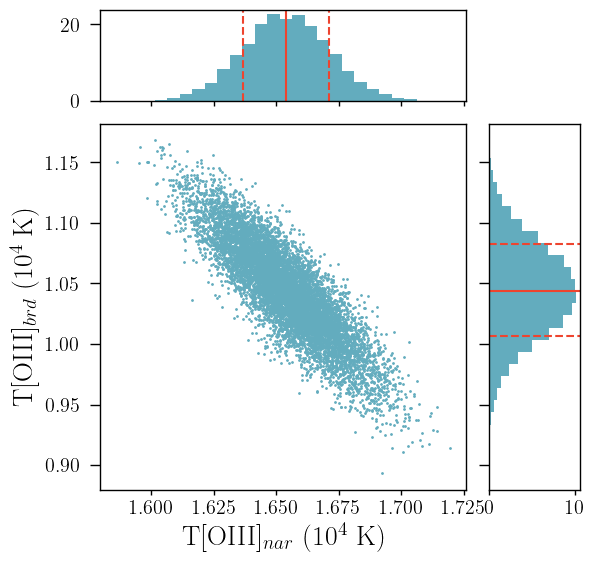

In [138]:
# Start with a square Figure.
fig = plt.figure(figsize=(6, 6))
# Add a gridspec with two rows and two columns and a ratio of 1 to 4 between
# the size of the marginal axes and the main axes in both directions.
# Also adjust the subplot parameters for a square plot.
gs = fig.add_gridspec(2, 2,  width_ratios=(4, 1), height_ratios=(1, 4),
                      left=0.1, right=0.9, bottom=0.1, top=0.9,
                      wspace=0.1, hspace=0.1)
# Create the Axes.
ax = fig.add_subplot(gs[1, 0])
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax)
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax)
# Draw the scatter plot and marginals.
binx = np.arange(min(t_OIII_nar), max(t_OIII_nar), 0.005)
biny = np.arange(min(t_OIII_brd), max(t_OIII_brd), 0.01)
scatter_hist(t_OIII_nar, t_OIII_brd, ax, ax_histx, ax_histy, binx, biny)

ax_histx.axvline(np.nanpercentile(t_OIII_nar, 50), color=cr[1])
ax_histx.axvline(np.nanpercentile(t_OIII_nar, 16), color=cr[1], ls='--')
ax_histx.axvline(np.nanpercentile(t_OIII_nar, 84), color=cr[1], ls='--')

ax_histy.axhline(np.nanpercentile(t_OIII_brd, 50), color=cr[1])
ax_histy.axhline(np.nanpercentile(t_OIII_brd, 16), color=cr[1], ls='--')
ax_histy.axhline(np.nanpercentile(t_OIII_brd, 84), color=cr[1], ls='--')

ax.set_xlabel(r'T[OIII]$_{nar}$ (10$^{4}$ K)')
ax.set_ylabel(r'T[OIII]$_{brd}$ (10$^{4}$ K)')

In [139]:
tOIII_nar = np.nanpercentile(t_OIII_nar, 50)
tOIII_nar_16 = np.nanpercentile(t_OIII_nar, 16)
tOIII_nar_84 = np.nanpercentile(t_OIII_nar, 84)

tOIII_brd = np.nanpercentile(t_OIII_brd, 50)
tOIII_brd_16 = np.nanpercentile(t_OIII_brd, 16)
tOIII_brd_84 = np.nanpercentile(t_OIII_brd, 84)

Text(0, 0.5, '$n_{e}^{brd}$ (10$^{4}$ K)')

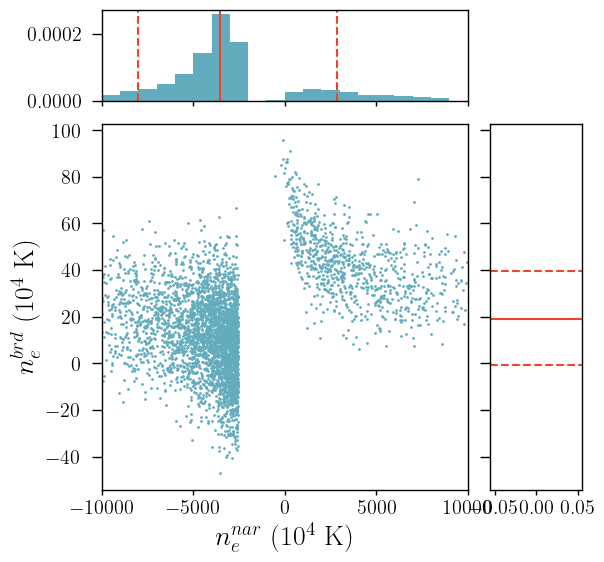

In [143]:
# Start with a square Figure.
fig = plt.figure(figsize=(6, 6))
# Add a gridspec with two rows and two columns and a ratio of 1 to 4 between
# the size of the marginal axes and the main axes in both directions.
# Also adjust the subplot parameters for a square plot.
gs = fig.add_gridspec(2, 2,  width_ratios=(4, 1), height_ratios=(1, 4),
                      left=0.1, right=0.9, bottom=0.1, top=0.9,
                      wspace=0.1, hspace=0.1)
# Create the Axes.
ax = fig.add_subplot(gs[1, 0])
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax)
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax)
# Draw the scatter plot and marginals.
binx = np.arange(-10000, 10000, 1000)
biny = np.arange(min(den_brd), max(den_brd), 1000)
scatter_hist(den_nar, den_brd, ax, ax_histx, ax_histy, binx, biny)

ax_histx.axvline(np.nanpercentile(den_nar, 50), color=cr[1])
ax_histx.axvline(np.nanpercentile(den_nar, 16), color=cr[1], ls='--')
ax_histx.axvline(np.nanpercentile(den_nar, 84), color=cr[1], ls='--')

ax_histy.axhline(np.nanpercentile(den_brd, 50), color=cr[1])
ax_histy.axhline(np.nanpercentile(den_brd, 16), color=cr[1], ls='--')
ax_histy.axhline(np.nanpercentile(den_brd, 84), color=cr[1], ls='--')

ax.set_xlim(-10000, 10000)

ax.set_xlabel(r'$n_{e}^{nar}$ (10$^{4}$ K)')
ax.set_ylabel(r'$n_{e}^{brd}$ (10$^{4}$ K)')

In [144]:
ne_nar = np.nanpercentile(den_nar, 50)
ne_nar_16 = np.nanpercentile(den_nar, 16)
ne_nar_84 = np.nanpercentile(den_nar, 84)

ne_brd = np.nanpercentile(den_brd, 50)
ne_brd_16 = np.nanpercentile(den_brd, 16)
ne_brd_84 = np.nanpercentile(den_brd, 84)

Text(0, 0.5, 'T[OII]$_{brd}$ (10$^{4}$ K)')

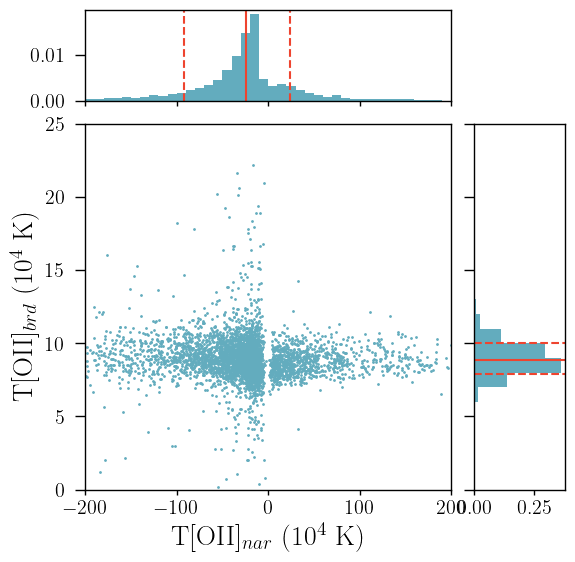

In [148]:
# Start with a square Figure.
fig = plt.figure(figsize=(6, 6))
# Add a gridspec with two rows and two columns and a ratio of 1 to 4 between
# the size of the marginal axes and the main axes in both directions.
# Also adjust the subplot parameters for a square plot.
gs = fig.add_gridspec(2, 2,  width_ratios=(4, 1), height_ratios=(1, 4),
                      left=0.1, right=0.9, bottom=0.1, top=0.9,
                      wspace=0.1, hspace=0.1)
# Create the Axes.
ax = fig.add_subplot(gs[1, 0])
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax)
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax)
# Draw the scatter plot and marginals.
binx = np.arange(-200, 200, 10)
biny = np.arange(0, 25, 1)
scatter_hist(t_OII_nar, t_OII_brd, ax, ax_histx, ax_histy, binx, biny)

ax_histx.axvline(np.nanpercentile(t_OII_nar, 50), color=cr[1])
ax_histx.axvline(np.nanpercentile(t_OII_nar, 16), color=cr[1], ls='--')
ax_histx.axvline(np.nanpercentile(t_OII_nar, 84), color=cr[1], ls='--')

ax_histy.axhline(np.nanpercentile(t_OII_brd, 50), color=cr[1])
ax_histy.axhline(np.nanpercentile(t_OII_brd, 16), color=cr[1], ls='--')
ax_histy.axhline(np.nanpercentile(t_OII_brd, 84), color=cr[1], ls='--')

ax.set_xlim(-200, 200)
ax.set_ylim(0, 25)

ax.set_xlabel(r'T[OII]$_{nar}$ (10$^{4}$ K)')
ax.set_ylabel(r'T[OII]$_{brd}$ (10$^{4}$ K)')

In [149]:
tOII_nar = np.nanpercentile(t_OII_nar, 50)
tOII_nar_16 = np.nanpercentile(t_OII_nar, 16)
tOII_nar_84 = np.nanpercentile(t_OII_nar, 84)

tOII_brd = np.nanpercentile(t_OII_brd, 50)
tOII_brd_16 = np.nanpercentile(t_OII_brd, 16)
tOII_brd_84 = np.nanpercentile(t_OII_brd, 84)

Text(0, 0.5, 'T[SIII]$_{brd}$ (10$^{4}$ K)')

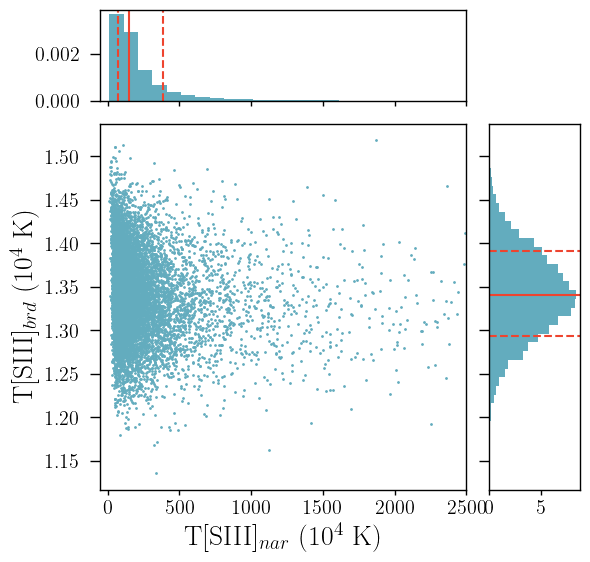

In [150]:
# Start with a square Figure.
fig = plt.figure(figsize=(6, 6))
# Add a gridspec with two rows and two columns and a ratio of 1 to 4 between
# the size of the marginal axes and the main axes in both directions.
# Also adjust the subplot parameters for a square plot.
gs = fig.add_gridspec(2, 2,  width_ratios=(4, 1), height_ratios=(1, 4),
                      left=0.1, right=0.9, bottom=0.1, top=0.9,
                      wspace=0.1, hspace=0.1)
# Create the Axes.
ax = fig.add_subplot(gs[1, 0])
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax)
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax)
# Draw the scatter plot and marginals.
binx = np.arange(min(t_SIII_nar), max(t_SIII_nar), 100)
biny = np.arange(min(t_SIII_brd), max(t_SIII_brd), 0.01)
scatter_hist(t_SIII_nar, t_SIII_brd, ax, ax_histx, ax_histy, binx, biny)

ax_histx.axvline(np.nanpercentile(t_SIII_nar, 50), color=cr[1])
ax_histx.axvline(np.nanpercentile(t_SIII_nar, 16), color=cr[1], ls='--')
ax_histx.axvline(np.nanpercentile(t_SIII_nar, 84), color=cr[1], ls='--')

ax_histy.axhline(np.nanpercentile(t_SIII_brd, 50), color=cr[1])
ax_histy.axhline(np.nanpercentile(t_SIII_brd, 16), color=cr[1], ls='--')
ax_histy.axhline(np.nanpercentile(t_SIII_brd, 84), color=cr[1], ls='--')

ax.set_xlim(-50, 2500)

ax.set_xlabel(r'T[SIII]$_{nar}$ (10$^{4}$ K)')
ax.set_ylabel(r'T[SIII]$_{brd}$ (10$^{4}$ K)')

In [151]:
tSIII_nar = np.nanpercentile(t_SIII_nar, 50)
tSIII_nar_16 = np.nanpercentile(t_SIII_nar, 16)
tSIII_nar_84 = np.nanpercentile(t_SIII_nar, 84)

tSIII_brd = np.nanpercentile(t_SIII_brd, 50)
tSIII_brd_16 = np.nanpercentile(t_SIII_brd, 16)
tSIII_brd_84 = np.nanpercentile(t_SIII_brd, 84)

# Output line, EW, velocities catalog

In [146]:
dV_4959

0.1690182461222325+/-0.32119221389656993

In [147]:
# Label of fitted lines
lines = np.array(['[OII]3726', '[OII]3729',
                  '[NeIII]3868',
                  '[SII]4068', '[SII]4076',
                  'Hd', 'Hg',
                  '[OIII]4363',
                  'Hb', '[OIII]4959', '[OIII]5007',
                  '[NII]5755',
                  '[OI]6300', '[SIII]6312',
                  '[NII]6548', 'Ha', '[NII]6584',
                  '[SII]6716', '[SII]6730',
                  '[OII]7319', '[OII]7330',
                  '[SIII]9069', '[SIII]9532'])

# Flux of the narrow component
narrow_fl = upy.uarray([oiid_nar_flux, oiic_nar_flux,
                        neiiia_nar_flux,
                        siid_nar_flux, siic_nar_flux,
                        hd_nar_flux, hg_nar_flux,
                        oiiic_nar_flux,
                        hb_nar_flux, oiiib_nar_flux, oiiia_nar_flux,
                        niic_nar_flux,
                        oi_nar_flux, siiic_nar_flux,
                        niib_nar_flux, ha_nar_flux, niia_nar_flux,
                        siib_nar_flux, siia_nar_flux,
                        oiib_nar_flux, oiia_nar_flux,
                        siiib_nar_flux, siiia_nar_flux],
                       
                       [oiid_nar_std, oiic_nar_std,
                        neiiia_nar_std,
                        siid_nar_std, siic_nar_std,
                        hd_nar_std, hg_nar_std,
                        oiiic_nar_std,
                        hb_nar_std, oiiib_nar_std, oiiia_nar_std,
                        niic_nar_std,
                        oi_nar_std, siiic_nar_std,
                        niib_nar_std, ha_nar_std, niia_nar_std,
                        siib_nar_std, siia_nar_std,
                        oiib_nar_std, oiia_nar_std,
                        siiib_nar_std, siiia_nar_std])

# Flux of the broad component
broad_fl = upy.uarray([oiid_brd_flux, oiic_brd_flux,
                       neiiia_brd_flux,
                       siid_brd_flux, siic_brd_flux,
                       hd_brd_flux, hg_brd_flux,
                       oiiic_brd_flux,
                       hb_brd_flux, oiiib_brd_flux, oiiia_brd_flux,
                       niic_brd_flux,
                       oi_brd_flux, siiic_brd_flux,
                       niib_brd_flux, ha_brd_flux, niia_brd_flux,
                       siib_brd_flux, siia_brd_flux,
                       oiib_brd_flux, oiia_brd_flux,
                       siiib_brd_flux, siiia_brd_flux],
                      
                      [oiid_brd_std, oiic_brd_std,
                       neiiia_brd_std,
                       siid_brd_std, siic_brd_std,
                       hd_brd_std, hg_brd_std,
                       oiiic_brd_std,
                       hb_brd_std, oiiib_brd_std, oiiia_brd_std,
                       niic_brd_std,
                       oi_brd_std, siiic_brd_std,
                       niib_brd_std, ha_brd_std, niia_brd_std,
                       siib_brd_std, siia_brd_std,
                       oiib_brd_std, oiia_brd_std,
                       siiib_brd_std, siiia_brd_std])

# Equivalent Width (Narrow)
ew_nar = [EW_OII_3726_nar, EW_OII_3729_nar,
          EW_NeIII_3868_nar,
          EW_SII_4068_nar, EW_SII_4076_nar,
          EW_Hd_nar, EW_Hg_nar,
          EW_OIII_4363_nar,
          EW_Hb_nar, EW_OIII_4959_nar, EW_OIII_5007_nar,
          EW_NII_5755_nar,
          EW_OI_6300_nar, EW_SIII_6312_nar,
          EW_NII_6548_nar, EW_Ha, EW_NII_6584_nar,
          EW_SII_6716_nar, EW_SII_6730_nar,
          EW_OII_7319_nar, EW_OII_7330_nar,
          EW_SIII_9069_nar, EW_SIII_9532_nar]

# Equivalent Width (Broad)
ew_brd = [EW_OII_3726_brd, EW_OII_3729_brd,
          EW_NeIII_3868_brd,
          EW_SII_4068_brd, EW_SII_4076_brd,
          EW_Hd_brd, EW_Hg_brd,
          EW_OIII_4363_brd,
          EW_Hb_brd, EW_OIII_4959_brd, EW_OIII_5007_brd,
          EW_NII_5755_brd,
          EW_OI_6300_brd, EW_SIII_6312_brd,
          EW_NII_6548_brd, EW_Ha, EW_NII_6584_brd,
          EW_SII_6716_brd, EW_SII_6730_brd,
          EW_OII_7319_brd, EW_OII_7330_brd,
          EW_SIII_9069_brd, EW_SIII_9532_brd]

# Equivalent Width (Total)
ew = [EW_OII_3726, EW_OII_3729,
      EW_NeIII_3868,
      EW_SII_4068, EW_SII_4076,
      EW_Hd, EW_Hg,
      EW_OIII_4363,
      EW_Hb, EW_OIII_4959, EW_OIII_5007,
      EW_NII_5755,
      EW_OI_6300, EW_SIII_6312,
      EW_NII_6548, EW_Ha, EW_NII_6584,
      EW_SII_6716, EW_SII_6730,
      EW_OII_7319, EW_OII_7330,
      EW_SIII_9069, EW_SIII_9532]

# Velocities
vel = {'galname': galname,
       'dV': dV_4959.nominal_value,
       'dV_err': dV_4959.std_dev,
       'FWHM_nar': FWHM_4959_nar.nominal_value,
       'FWHM_nar_err': FWHM_4959_nar.std_dev,
       'FWHM_brd': FWHM_4959_brd.nominal_value,
       'FWHM_brd_err': FWHM_4959_brd.std_dev
}

# Total fluxes
total_fl = broad_fl + narrow_fl

In [148]:
em_line_catalog = {}
em_narrow_catalog = {}
em_broad_catalog = {}
ew_line_catalog = {}
for i in range(len(lines)):
    
    # Total
    em_line_catalog['galname'] = galname
    em_line_catalog[lines[i]] = upy.nominal_values(total_fl)[i]
    em_line_catalog[lines[i]+'_err'] = upy.std_devs(total_fl)[i]
    
    # Narrow
    em_narrow_catalog['galname'] = galname
    em_narrow_catalog[lines[i]] = upy.nominal_values(narrow_fl)[i]
    em_narrow_catalog[lines[i]+'_err'] = upy.std_devs(narrow_fl)[i]
    
    # Broad
    em_broad_catalog['galname'] = galname
    em_broad_catalog[lines[i]] = upy.nominal_values(broad_fl)[i]
    em_broad_catalog[lines[i]+'_err'] = upy.std_devs(broad_fl)[i]
    
    # EW catalog
    ew_line_catalog['galname'] = galname
    ew_line_catalog[lines[i]] = ew[i].nominal_value
    ew_line_catalog[lines[i]+'_err'] = ew[i].std_dev
    
    # Narrow
    ew_line_catalog[lines[i]+'_nar'] = ew_nar[i].nominal_value
    ew_line_catalog[lines[i]+'_nar_err'] = ew_nar[i].std_dev
    
    # Broad
    ew_line_catalog[lines[i]+'_brd'] = ew_brd[i].nominal_value
    ew_line_catalog[lines[i]+'_brd_err'] = ew_brd[i].std_dev
    
em_line_catalog_pd = pd.DataFrame(data=em_line_catalog, index=[0])
em_narrow_catalog_pd = pd.DataFrame(data=em_narrow_catalog, index=[0])
em_broad_catalog_pd = pd.DataFrame(data=em_broad_catalog, index=[0])
ew_line_catalog_pd = pd.DataFrame(data=ew_line_catalog, index=[0])
vel_catalog_pd = pd.DataFrame(data=vel, index=[0])

In [149]:
# Saving emission line fluxes, ew and velocity catalogs
save_catalog(galname, em_line_catalog_pd, magePath + '/results/em_lines.csv')
save_catalog(galname, em_narrow_catalog_pd, magePath + '/results/em_narrow.csv')
save_catalog(galname, em_broad_catalog_pd, magePath + '/results/em_broad.csv')
save_catalog(galname, ew_line_catalog_pd, magePath + '/results/ew_lines.csv')
save_catalog(galname, vel_catalog_pd, magePath + '/results/vel_catalog.csv')

Existent catalog (.csv) file.
Existent data for J2225, overwriting...
Done.
Existent catalog (.csv) file.
Existent data for J2225, overwriting...
Done.
Existent catalog (.csv) file.
Existent data for J2225, overwriting...
Done.
Existent catalog (.csv) file.
Non existent data for J2225, adding new data...
Done.
Existent catalog (.csv) file.
Existent data for J2225, overwriting...
Done.
